<a href="https://colab.research.google.com/github/Kafleavinash/Machinelearning_soil/blob/main/catboost_model_cbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cleaned_file_removing_11,21field.csv to cleaned_file_removing_11,21field.csv


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df_cleaned = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df_cleaned.to_csv("cleaned_file.csv", index=False)


In [ ]:
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df_cleaned = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df_cleaned.to_csv("cleaned_file.csv", index=False)


In [ ]:
# Drop the dependent variable from the dataset to get the features (X)
X = df.drop(columns=["OM"])  # <-- replace with actual column name if different

# Select the dependent variable (y)
y = df["OM"]


In [ ]:
df_m = df

In [ ]:
df_m.head()

,SAMPLEDATE,lati,long,OM,Slope,Aspect,Profile_curva,Tang_curva,Polaris_SC,gNASGO_SC,...,MRRTF,Terrain_Ruggedness_Index,Slope_Height,Convergence_Index,Convexity,Mid_Slope_Position,Senti_BI_1,Planet_BI_1,Standard_Height,Relative_Elev
0,6/8/2022,44.384,-94.121,4.79,0.226563,288.504852,-0.031094,-0.042257,0.677903,2869.500000,...,3.947627,0.084871,0.288607,-83.609917,47.368896,0.553635,1354.452288,902.283908,270.979370,6.350006
1,6/8/2022,44.383,-94.121,6.39,1.450022,237.093048,-0.080120,-0.019543,0.361096,6347.343750,...,0.116676,0.169100,0.155899,-13.922724,48.102909,0.383810,1384.741131,936.063166,266.730682,5.299988
2,6/8/2022,44.382,-94.121,5.19,1.114162,224.984100,-0.061876,-0.037807,0.691218,4136.484375,...,0.089571,0.181121,0.495283,-19.467302,51.340260,0.421876,1271.852979,919.376555,269.167419,4.569977
3,6/8/2022,44.381,-94.121,4.10,0.143161,90.087471,-0.032168,-0.077811,0.708760,NaN,...,0.008647,0.129995,0.401767,-71.930679,46.769714,0.362247,1386.778281,943.357435,267.927734,3.049988
4,6/8/2022,44.376,-94.121,5.89,2.481674,33.235489,0.026937,0.043010,0.724054,8062.875000,...,3.636065,0.123691,0.289381,52.043789,51.582481,0.513358,1353.417157,919.207403,269.551971,4.639984


STAT

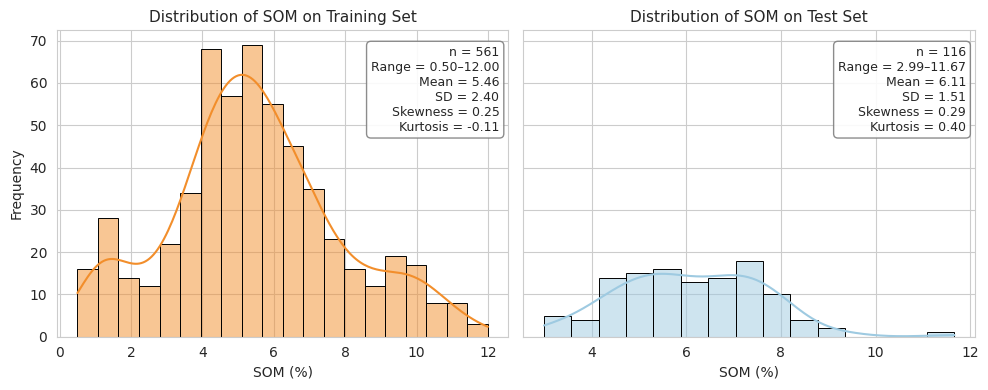

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# ===============================
# STEP 1: Load datasets
# ===============================
train_df = pd.read_csv("cleaned_file_removing_11,21field.csv")
test_df  = pd.read_csv("Antho_Test_,11,21_field.csv")

# Column name for SOM
som_train = train_df["OM"].dropna()
som_test  = test_df["OM"].dropna()

# ===============================
# STEP 2: Compute statistics
# ===============================
def compute_stats(data):
    return {
        "n": len(data),
        "min": np.min(data),
        "max": np.max(data),
        "mean": np.mean(data),
        "std": np.std(data, ddof=1),
        "skew": skew(data),
        "kurt": kurtosis(data, fisher=True)
    }

stats_train = compute_stats(som_train)
stats_test  = compute_stats(som_test)

# ===============================
# STEP 3: Plot (publication-ready)
# ===============================
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# -------- Training Set --------
sns.histplot(
    som_train,
    bins=20,
    kde=True,
    color="#f28e2b",
    edgecolor="black",
    linewidth=0.7,
    ax=axes[0]
)

axes[0].set_title("Distribution of SOM on Training Set", fontsize=11)
axes[0].set_xlabel("SOM (%)", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)

train_text = (
    f"n = {stats_train['n']}\n"
    f"Range = {stats_train['min']:.2f}–{stats_train['max']:.2f}\n"
    f"Mean = {stats_train['mean']:.2f}\n"
    f"SD = {stats_train['std']:.2f}\n"
    f"Skewness = {stats_train['skew']:.2f}\n"
    f"Kurtosis = {stats_train['kurt']:.2f}"
)

axes[0].text(
    0.98, 0.95, train_text,
    transform=axes[0].transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35",
              facecolor="white",
              edgecolor="gray",
              alpha=0.9)
)

# -------- Test Set --------
sns.histplot(
    som_test,
    bins=15,
    kde=True,
    color="#9ecae1",
    edgecolor="black",
    linewidth=0.7,
    ax=axes[1]
)

axes[1].set_title("Distribution of SOM on Test Set", fontsize=11)
axes[1].set_xlabel("SOM (%)", fontsize=10)

test_text = (
    f"n = {stats_test['n']}\n"
    f"Range = {stats_test['min']:.2f}–{stats_test['max']:.2f}\n"
    f"Mean = {stats_test['mean']:.2f}\n"
    f"SD = {stats_test['std']:.2f}\n"
    f"Skewness = {stats_test['skew']:.2f}\n"
    f"Kurtosis = {stats_test['kurt']:.2f}"
)

axes[1].text(
    0.98, 0.95, test_text,
    transform=axes[1].transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35",
              facecolor="white",
              edgecolor="gray",
              alpha=0.9)
)

# ===============================
# STEP 4: Save for Word / Journal
# ===============================
plt.tight_layout()
plt.savefig("Figure_3_SOM_Distribution_Train_Test.png",
            dpi=300, bbox_inches="tight")
plt.show()


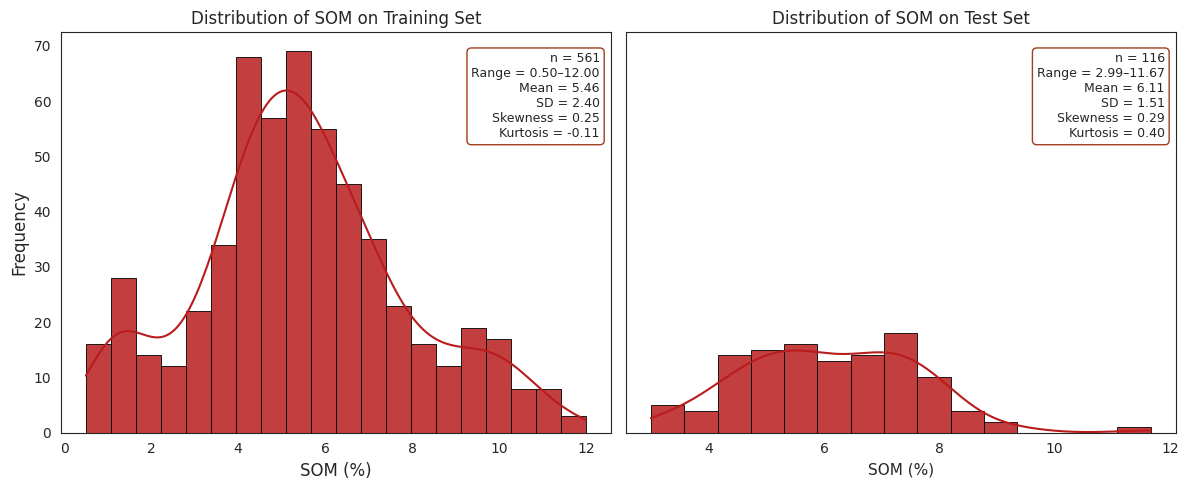

In [ ]:
# ===============================
# STEP 3: Plot (dark orange, plain white background)
# ===============================
sns.set_style("white")   # 🔹 plain white background (no gray grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

orange_main = "#b91c1c"
  # 🔶 dark orange (bars)
orange_dark = "#9a3412"   # 🔶 deeper orange (borders/KDE)

# -------- Training Set --------
sns.histplot(
    som_train,
    bins=20,
    kde=True,
    color=orange_main,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
    ax=axes[0]
)

axes[0].set_title("Distribution of SOM on Training Set", fontsize=12)
axes[0].set_xlabel("SOM (%)", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

axes[0].text(
    0.98, 0.95, train_text,
    transform=axes[0].transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor=orange_dark,
        alpha=0.95
    )
)

# -------- Test Set --------
sns.histplot(
    som_test,
    bins=15,
    kde=True,
    color=orange_main,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
    ax=axes[1]
)

axes[1].set_title("Distribution of SOM on Test Set", fontsize=12)
axes[1].set_xlabel("SOM (%)", fontsize=11)

axes[1].text(
    0.98, 0.95, test_text,
    transform=axes[1].transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor=orange_dark,
        alpha=0.95
    )
)

# ---- clean spines (Word / journal look)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig(
    "Figure_3_SOM_Distribution_DarkOrange_WhiteBG.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

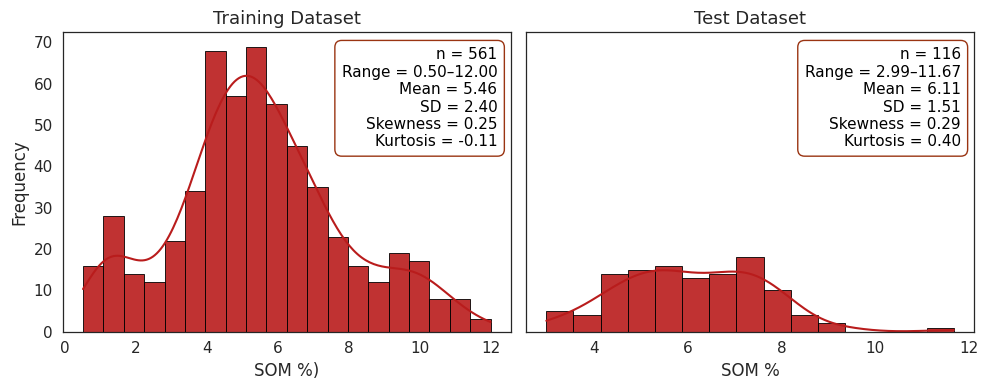

In [ ]:
# ===============================
# STEP 3: Plot (dark orange, plain white background, clear text)
# ===============================
sns.set_style("white")   # plain white background

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

orange_main = "#b91c1c"   # dark orange/red
orange_dark = "#9a3412"   # deeper orange for borders

# -------- Training Set --------
sns.histplot(
    som_train,
    bins=20,
    kde=True,
    color=orange_main,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    ax=axes[0]
)

axes[0].set_title(
    "Training Dataset",
    fontsize=13,

)
axes[0].set_xlabel("SOM %)", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

axes[0].text(
    0.97, 0.95, train_text,
    transform=axes[0].transAxes,
    ha="right", va="top",
    fontsize=11,                 # 🔥 larger text
    color="black",               # 🔥 Word-like black
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor=orange_dark,
        linewidth=1.0,           # 🔥 sharper border
        alpha=1.0                # 🔥 no transparency
    )
)

# -------- Test Set --------
sns.histplot(
    som_test,
    bins=15,
    kde=True,
    color=orange_main,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    ax=axes[1]
)

axes[1].set_title(
    "Test Dataset",
    fontsize=13,

)
axes[1].set_xlabel("SOM %", fontsize=12)

axes[1].text(
    0.97, 0.95, test_text,
    transform=axes[1].transAxes,
    ha="right", va="top",
    fontsize=11,                 # 🔥 larger text
    color="black",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor=orange_dark,
        linewidth=1.0,
        alpha=1.0
    )
)

# ---- Clean axes spines and ticks
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
    ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.savefig(
    "Figure_3_SOM_Distribution_ClearText_WordStyle.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


In [ ]:
# Install the catboost library
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [ ]:
# Install the catboost library
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Filter OM > 12 and drop NaNs ===
df_filtered = df_m[df_m['OM'] <= 12]
X = df_filtered.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'
                              ])
y = df_filtered['OM']
X = X.dropna()
y = y[X.index]
X = X[y.notna()]
y = y.dropna()

# === Step 2: Train-test split ===
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Step 3: Standardization ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# === Step 4: RFE Feature Selection ===
num_features_to_select = int(0.40 * X.shape[1])
cat_base = CatBoostRegressor(verbose=0, random_state=42)
rfe = RFE(estimator=cat_base, n_features_to_select=num_features_to_select)
rfe.fit(X_train_scaled, y_train_full)

selected_features = X_train_full.columns[rfe.support_]
X_train_selected = X_train_scaled[:, rfe.support_]
X_test_selected = X_test_scaled[:, rfe.support_]

# === Step 5: Grid Search for CatBoost Hyperparameters ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500,1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_selected, y_train_full)
best_model = grid_search.best_estimator_

# === Step 6: 10-Fold Cross Validation on Training Set ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
train_actual = []
train_predicted = []
train_metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_train_selected):
    X_t, X_v = X_train_selected[train_idx], X_train_selected[val_idx]
    y_t, y_v = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    best_model.fit(X_t, y_t, verbose=0)
    y_val_pred = best_model.predict(X_v)

    train_actual.extend(y_v)
    train_predicted.extend(y_val_pred)
    train_metrics['mbe'].append(np.mean(y_val_pred - y_v))
    train_metrics['mae'].append(mean_absolute_error(y_v, y_val_pred))
    train_metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_val_pred)))
    train_metrics['r2'].append(r2_score(y_v, y_val_pred))

# === Step 7: Evaluate on Test Set ===
best_model.fit(X_train_selected, y_train_full, verbose=0)
y_test_pred = best_model.predict(X_test_selected)

test_mbe = np.mean(y_test_pred - y_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# === Step 8: Compute Average Train Metrics ===
train_actual_np = np.array(train_actual)
train_predicted_np = np.array(train_predicted)

train_mbe = np.mean(train_predicted_np - train_actual_np)
train_mae = mean_absolute_error(train_actual_np, train_predicted_np)
train_rmse = np.sqrt(mean_squared_error(train_actual_np, train_predicted_np))
train_r2 = r2_score(train_actual_np, train_predicted_np)

# === Step 9: Print Results ===
print("\nBest Model Parameters:", grid_search.best_params_)
print("\nTrain Set Metrics (10-Fold Cross-Validation):")
print(f"MBE: {train_mbe:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
print("\nTest Set Metrics:")
print(f"MBE: {test_mbe:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

# === Step 10: Feature Importance Plot ===
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Importance', data=feature_importance_df, color='royalblue')
plt.title("Feature Importance (CatBoost Regressor)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# === Step 11: Scatter Plot for Training Set ===
min_val = min(train_actual_np.min(), train_predicted_np.min())
max_val = max(train_actual_np.max(), train_predicted_np.max())

plt.figure(figsize=(5, 3))
plt.scatter(train_actual_np, train_predicted_np, color="royalblue", alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.title("10-Fold CV: Actual vs. Predicted OM (Train)", fontsize=10)
plt.grid(True)
textstr = '\n'.join((
    f'MBE: {train_mbe:.3f}',
    f'MAE: {train_mae:.3f}',
    f'RMSE: {train_rmse:.3f}',
    f'R²: {train_r2:.3f}'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()

# === Step 12: Scatter Plot for Test Set ===
test_actual_np = np.array(y_test)
test_predicted_np = np.array(y_test_pred)

min_val = min(test_actual_np.min(), test_predicted_np.min())
max_val = max(test_actual_np.max(), test_predicted_np.max())

plt.figure(figsize=(5, 3))
plt.scatter(test_actual_np, test_predicted_np, color="royalblue", alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.title("Actual vs. Predicted OM (Test Set)", fontsize=10)
plt.grid(True)
textstr = '\n'.join((
    f'MBE: {test_mbe:.3f}',
    f'MAE: {test_mae:.3f}',
    f'RMSE: {test_rmse:.3f}',
    f'R²: {test_r2:.3f}'
))
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
print("Test OM Min/Max:", y_test.min(), y_test.max())


In [ ]:
print("Train OM Mean:", y_train_full.mean())
print("Test OM Mean:", y_test.mean())
print("Test Predictions Mean:", y_test_pred.mean())


In [ ]:
field_df[selected_features].describe()


In [ ]:
# Save the trained model to a file
best_model.save_model("catboost_model.cbm")


In [ ]:
test_results_df = pd.DataFrame({
    'Actual_OM': y_test,
    'Predicted_OM': y_test_pred
})

test_results_df.to_csv("test_actual_vs_predicted.csv", index=False)


In [ ]:
import pandas as pd

# === Training Set ===
# y_train_full: original training labels (from train_test_split)
# train_predicted_np: predictions from 10-fold CV
# y_train_full.index: original index from df_filtered

train_results_df = pd.DataFrame({
    "Index": y_train_full.index,
    "Actual_OM": y_train_full.values,
    "Predicted_OM": train_predicted_np
}).sort_values("Index")

# Optional: merge with full input features for GIS or analysis
train_full = df_filtered.loc[train_results_df["Index"]].copy()
train_full["Actual_OM"] = train_results_df["Actual_OM"].values
train_full["Predicted_OM"] = train_results_df["Predicted_OM"].values

# Save training predictions
train_full.to_csv("train_actual_vs_predicted_aligned.csv", index=False)

# === Test Set ===
test_results_df = pd.DataFrame({
    "Index": y_test.index,
    "Actual_OM": y_test.values,
    "Predicted_OM": y_test_pred
}).sort_values("Index")

# Merge with input features
test_full = df_filtered.loc[test_results_df["Index"]].copy()
test_full["Actual_OM"] = test_results_df["Actual_OM"].values
test_full["Predicted_OM"] = test_results_df["Predicted_OM"].values

# Save test predictions
test_full.to_csv("test_actual_vs_predicted_aligned.csv", index=False)


In [ ]:
# Align predictions with original training indices
train_pred_df = pd.DataFrame({
    "Index": y_train_full.index,
    "Actual_OM": y_train_full.values,
    "Predicted_OM": train_predicted_np
}).set_index("Index").sort_index()

# Join with input data for these rows
train_input_df = df_filtered.loc[y_train_full.index]
train_result_df = train_input_df.copy()
train_result_df["Actual_OM"] = train_pred_df["Actual_OM"]
train_result_df["Predicted_OM"] = train_pred_df["Predicted_OM"]

# Save
train_result_df.to_csv("train_cv_predictions_aligned.csv", index=False)


In [ ]:
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Load your dataset ===
df_m = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")

# === Step 1: Filter OM > 12 and drop NaNs ===
df_filtered = df_m[df_m['OM'] <= 12]
X = df_filtered.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df_filtered['OM']
X = X.dropna()
y = y[X.index]
X = X[y.notna()]
y = y.dropna()

# === Step 2: Standardize ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Step 3: RFE Feature Selection ===
num_features_to_select = int(0.40 * X.shape[1])
cat_base = CatBoostRegressor(verbose=0, random_state=42)
rfe = RFE(estimator=cat_base, n_features_to_select=num_features_to_select)
rfe.fit(X_scaled, y)
selected_features = X.columns[rfe.support_]
X_selected = X_scaled[:, rfe.support_]

# === Step 4: Hyperparameter Tuning ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, 1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected, y)
best_model = grid_search.best_estimator_

# === Step 5: 10-Fold CV Prediction for Whole Dataset ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
all_actual = np.zeros_like(y)
all_predicted = np.zeros_like(y)

metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_selected):
    X_t, X_v = X_selected[train_idx], X_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t, verbose=0)
    y_val_pred = best_model.predict(X_v)

    all_actual[val_idx] = y_v
    all_predicted[val_idx] = y_val_pred

    metrics['mbe'].append(np.mean(y_val_pred - y_v))
    metrics['mae'].append(mean_absolute_error(y_v, y_val_pred))
    metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_val_pred)))
    metrics['r2'].append(r2_score(y_v, y_val_pred))


# === Save predictions with alignment ===
# Create a Series for the predictions using the index from the original 'y' after dropping NaNs
predicted_series = pd.Series(all_predicted, index=y.index)

# Create the result DataFrame from the original df_filtered
df_result = df_filtered.copy()

# Assign the predicted values, aligning by index.
# Rows in df_filtered that were NOT in 'y' (because of NaN removal) will get NaN.
df_result['Predicted_OM'] = predicted_series

# Save to CSV
df_result.to_csv("OM_10Fold_CV_Predictions.csv", index=False)

# === Step 7: Print averaged metrics ===
print("Averaged Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: {np.mean(v):.4f}")



In [ ]:
# === Step 6: Print averaged metrics ===
print("Averaged Metrics (10-Fold CV):")
print(f"MBE : {np.mean(metrics['mbe']):.4f}")
print(f"MAE : {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²  : {np.mean(metrics['r2']):.4f}")

In [ ]:
# === TRAINING SCRIPT ===
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_21.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=CatBoostRegressor(verbose=0, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]  # raw features after selection

# === Step 4: Scale only selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Train model with GridSearchCV ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, 1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_selected_scaled):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    metrics['mae'].append(mean_absolute_error(y_v, y_pred))
    metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_pred)))
    metrics['r2'].append(r2_score(y_v, y_pred))

print("=== 10-Fold Train Metrics ===")
print(f"MAE: {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²: {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_catboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")


One_Field_left_train_withmetrices

In [ ]:
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=CatBoostRegressor(verbose=0, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Train model with GridSearch ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, ]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n=== Per Fold Metrics ===")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Final Average Metrics ===
print("\n=== Average 10-Fold Train Metrics ===")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_catboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")


In [ ]:
# Step 8: Feature Importance Plot
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Plotting the feature importances
plt.figure(figsize=(10, 5))
plt.title("Top 40% Feature Importances", fontsize=14)
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(
    ticks=range(len(selected_features)),
    labels=np.array(selected_features)[sorted_idx],
    rotation=90,
    fontsize=9
)
plt.ylabel("Importance Score", fontsize=12)
plt.xlabel("Feature Names", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load test data ===
df_test = pd.read_csv("/content/Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Load model artifacts ===
model = joblib.load("/content/best_catboost_model.pkl")
scaler = joblib.load("/content/scaler.pkl")
selected_features = joblib.load("/content/selected_features.pkl")

# === Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Scale test data ===
X_test_scaled = scaler.transform(X_test_final)

# === Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Plot Actual vs Predicted with perfect-fit line ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="green", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


After_Pretrained_to_test_here

TRAIN AND TEST DIFFERENT CSV FILE, CAT BOOST

In [ ]:
!pip install catboost
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_train and df_test are already loaded and cleaned

plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['OM'], label='Train Field(s)', fill=True, alpha=0.6, linewidth=2)
sns.kdeplot(df_test['OM'], label='Test Field', fill=True, alpha=0.6, linewidth=2)

plt.title('OM Distribution: Train vs. Test Field')
plt.xlabel('OM (Organic Matter)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Random_Forest

Fitting 3 folds for each of 96 candidates, totalling 288 fits

✅ Best Hyperparameters from GridSearchCV:
{'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

=== Per Fold Metrics ===
Fold 1 → MBE: -0.2325, MAE: 1.0372, RMSE: 1.5194, R²: 0.6583
Fold 2 → MBE: -0.1763, MAE: 1.2483, RMSE: 1.6632, R²: 0.4703
Fold 3 → MBE: 0.4004, MAE: 0.7720, RMSE: 0.9274, R²: 0.7511
Fold 4 → MBE: 0.0188, MAE: 1.0265, RMSE: 1.4580, R²: 0.5742
Fold 5 → MBE: -0.0789, MAE: 1.1445, RMSE: 1.5676, R²: 0.6164
Fold 6 → MBE: 0.1252, MAE: 0.9210, RMSE: 1.3022, R²: 0.6652
Fold 7 → MBE: 0.0125, MAE: 1.0330, RMSE: 1.3199, R²: 0.6279
Fold 8 → MBE: -0.0170, MAE: 0.9263, RMSE: 1.2792, R²: 0.7367
Fold 9 → MBE: -0.0936, MAE: 0.9125, RMSE: 1.3419, R²: 0.6714
Fold 10 → MBE: -0.1597, MAE: 1.0474, RMSE: 1.6108, R²: 0.6349

=== Average 10-Fold Train Metrics ===
MBE:  -0.0201
MAE:  1.0069
RMSE: 1.3990
R²:   0.6406


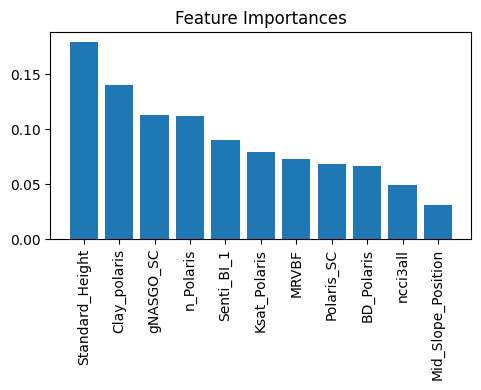

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)
selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# ✅ Print Best Hyperparameters
print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n=== Per Fold Metrics ===")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Final Average Metrics ===
print("\n=== Average 10-Fold Train Metrics ===")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_rf_model.pkl")
joblib.dump(scaler, "scaler.rf.pkl")
joblib.dump(list(selected_features), "selected_features.rf.pkl")

# === Step 8: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(5, 4))
plt.title("Feature Importances")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.show()


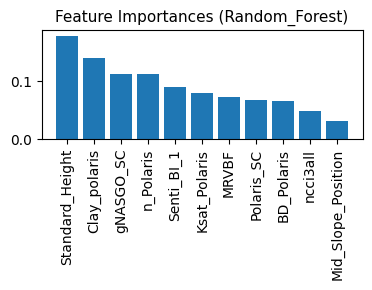

In [ ]:
# === Step 8: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(4, 3))
plt.title("Feature Importances (Random_Forest)",fontsize=11)
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx],rotation=90)
plt.tight_layout()
plt.show()

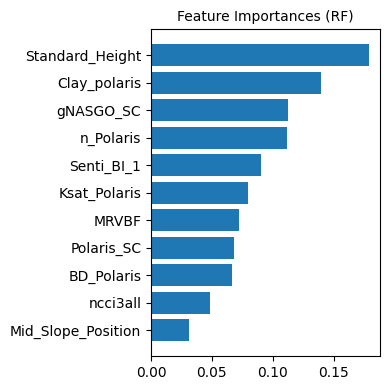

In [ ]:
# === Step 8: Feature Importance Plot (Horizontal) ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(4, 4))
plt.title("Feature Importances (RF)", fontsize=10)
plt.barh(range(len(selected_features)), importances[sorted_idx])
plt.yticks(range(len(selected_features)), np.array(selected_features)[sorted_idx])
plt.gca().invert_yaxis()  # Optional: Largest importance at the top
plt.tight_layout()
plt.show()



IQR of observed OM: 2.7000
Fitting 3 folds for each of 96 candidates, totalling 288 fits

✅ Best Hyperparameters from GridSearchCV:
{'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

=== Per Fold Metrics ===
Fold 1 → MBE: -0.2325, MAE: 1.0372, RMSE: 1.5194, R²: 0.6583, RPIQ: 1.7770
Fold 2 → MBE: -0.1763, MAE: 1.2483, RMSE: 1.6632, R²: 0.4703, RPIQ: 1.6234
Fold 3 → MBE: 0.4004, MAE: 0.7720, RMSE: 0.9274, R²: 0.7511, RPIQ: 2.9113
Fold 4 → MBE: 0.0188, MAE: 1.0265, RMSE: 1.4580, R²: 0.5742, RPIQ: 1.8518
Fold 5 → MBE: -0.0789, MAE: 1.1445, RMSE: 1.5676, R²: 0.6164, RPIQ: 1.7223
Fold 6 → MBE: 0.1252, MAE: 0.9210, RMSE: 1.3022, R²: 0.6652, RPIQ: 2.0734
Fold 7 → MBE: 0.0125, MAE: 1.0330, RMSE: 1.3199, R²: 0.6279, RPIQ: 2.0457
Fold 8 → MBE: -0.0170, MAE: 0.9263, RMSE: 1.2792, R²: 0.7367, RPIQ: 2.1107
Fold 9 → MBE: -0.0936, MAE: 0.9125, RMSE: 1.3419, R²: 0.6714, RPIQ: 2.0120
Fold 10 → MBE: -0.1597, MAE: 1.0474, RMS

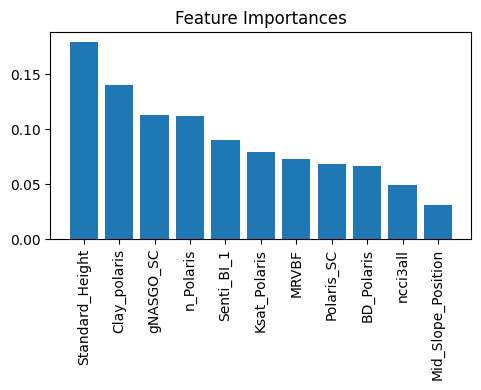

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    n_features_to_select=num_features
)
rfe.fit(X_scaled_full, y)
selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# ==========================================================
# === RPIQ: Interquartile Range of observed OM (GLOBAL) ===
# ==========================================================
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1

print(f"\nIQR of observed OM: {IQR:.4f}")

# === Step 5: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# ✅ Print Best Hyperparameters
print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: Evaluate with 10-fold CV (INCLUDING RPIQ) ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'rpiq': []
}

print("\n=== Per Fold Metrics ===")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)
    rpiq = IQR / rmse

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {i} → "
        f"MBE: {mbe:.4f}, "
        f"MAE: {mae:.4f}, "
        f"RMSE: {rmse:.4f}, "
        f"R²: {r2:.4f}, "
        f"RPIQ: {rpiq:.4f}"
    )

# === Final Average Metrics (WITH RPIQ) ===
print("\n=== Average 10-Fold Train Metrics ===")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_rf_model.pkl")
joblib.dump(scaler, "scaler.rf.pkl")
joblib.dump(list(selected_features), "selected_features.rf.pkl")

# === Step 8: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(5, 4))
plt.title("Feature Importances")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(
    range(len(selected_features)),
    np.array(selected_features)[sorted_idx],
    rotation=90
)
plt.tight_layout()
plt.show()


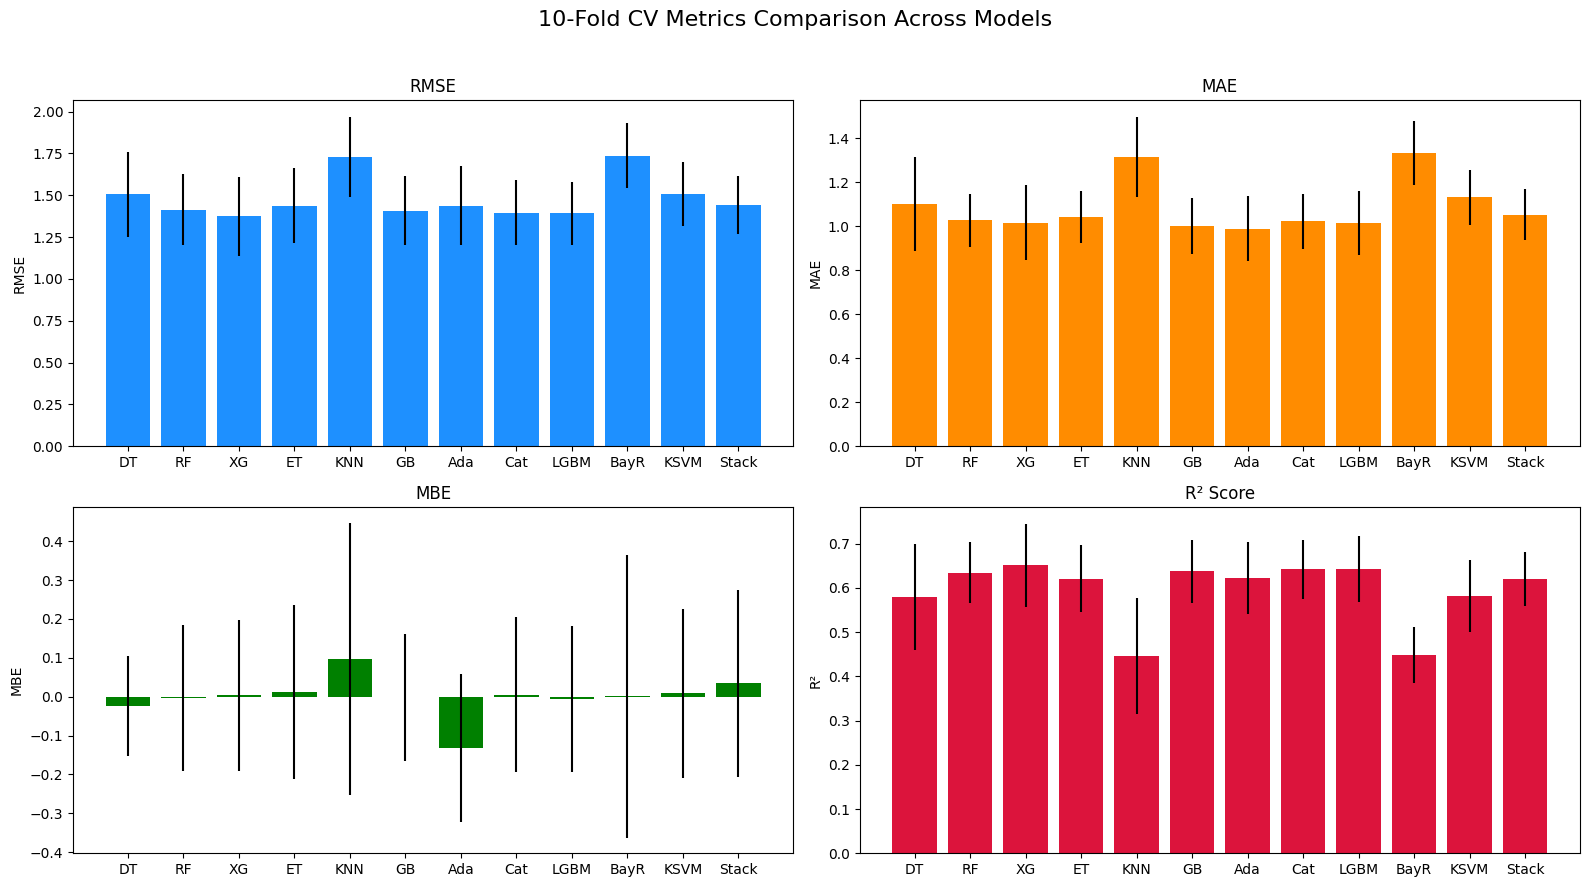

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === STEP 1: Add your model-wise fold metrics ===
model_results = {

                 "DT": [
    {"MBE": -0.2298, "MAE": 1.1054, "RMSE": 1.5321, "R2": 0.6526},
    {"MBE": -0.0613, "MAE": 1.2849, "RMSE": 1.6906, "R2": 0.4526},
    {"MBE": 0.2428,  "MAE": 0.6169, "RMSE": 0.8272, "R2": 0.8020},
    {"MBE": 0.0402,  "MAE": 1.3129, "RMSE": 1.7011, "R2": 0.4203},
    {"MBE": -0.1035, "MAE": 1.2234, "RMSE": 1.6636, "R2": 0.5680},
    {"MBE": 0.0255,  "MAE": 0.9107, "RMSE": 1.3008, "R2": 0.6659},
    {"MBE": -0.0151, "MAE": 1.3256, "RMSE": 1.6764, "R2": 0.3997},
    {"MBE": 0.1039,  "MAE": 1.1023, "RMSE": 1.6370, "R2": 0.5688},
    {"MBE": -0.1628, "MAE": 0.9354, "RMSE": 1.4751, "R2": 0.6030},
    {"MBE": -0.0814, "MAE": 1.2015, "RMSE": 1.5536, "R2": 0.6603}
],
                 "RF": [
    {"MBE": -0.2355, "MAE": 1.1370, "RMSE": 1.6580, "R2": 0.5932},
    {"MBE": -0.1840, "MAE": 1.2013, "RMSE": 1.5862, "R2": 0.5182},
    {"MBE":  0.4082, "MAE": 0.7801, "RMSE": 0.9376, "R2": 0.7456},
    {"MBE":  0.0170, "MAE": 1.0641, "RMSE": 1.4918, "R2": 0.5542},
    {"MBE": -0.1088, "MAE": 1.1359, "RMSE": 1.5752, "R2": 0.6127},
    {"MBE":  0.2254, "MAE": 0.9053, "RMSE": 1.2592, "R2": 0.6869},
    {"MBE":  0.0868, "MAE": 1.0260, "RMSE": 1.3089, "R2": 0.6341},
    {"MBE": -0.0370, "MAE": 0.9530, "RMSE": 1.2924, "R2": 0.7312},
    {"MBE": -0.0513, "MAE": 0.9749, "RMSE": 1.3881, "R2": 0.6484},
    {"MBE": -0.1479, "MAE": 1.0877, "RMSE": 1.6412, "R2": 0.6210}
],

"XG": [
    {"MBE": -0.224, "MAE": 1.177, "RMSE": 1.523, "R2": 0.657},
    {"MBE": -0.041, "MAE": 1.317, "RMSE": 1.692, "R2": 0.452},
    {"MBE":  0.460, "MAE": 0.749, "RMSE": 0.938, "R2": 0.745},
    {"MBE":  0.057, "MAE": 1.058, "RMSE": 1.451, "R2": 0.578},
    {"MBE": -0.117, "MAE": 1.166, "RMSE": 1.638, "R2": 0.581},
    {"MBE":  0.203, "MAE": 0.840, "RMSE": 1.122, "R2": 0.751},
    {"MBE": -0.018, "MAE": 1.034, "RMSE": 1.347, "R2": 0.612},
    {"MBE":  0.003, "MAE": 0.885, "RMSE": 1.244, "R2": 0.751},
    {"MBE": -0.071, "MAE": 0.853, "RMSE": 1.196, "R2": 0.739},
    {"MBE": -0.220, "MAE": 1.080, "RMSE": 1.589, "R2": 0.645}
],




"ET": [
    {"MBE": -0.1541, "MAE": 1.1224, "RMSE": 1.5484, "R2": 0.6452},
    {"MBE": -0.1632, "MAE": 1.1972, "RMSE": 1.6450, "R2": 0.4818},
    {"MBE": 0.5096,  "MAE": 0.8621, "RMSE": 1.1103, "R2": 0.6433},
    {"MBE": 0.0243,  "MAE": 1.0014, "RMSE": 1.4078, "R2": 0.6030},
    {"MBE": -0.0729, "MAE": 1.2164, "RMSE": 1.7027, "R2": 0.5475},
    {"MBE": 0.3136,  "MAE": 0.9543, "RMSE": 1.2641, "R2": 0.6845},
    {"MBE": 0.0313,  "MAE": 1.0452, "RMSE": 1.2793, "R2": 0.6505},
    {"MBE": -0.1489, "MAE": 0.9348, "RMSE": 1.3695, "R2": 0.6982},
    {"MBE": 0.0294,  "MAE": 0.9269, "RMSE": 1.2209, "R2": 0.7280},
    {"MBE": -0.2503, "MAE": 1.1614, "RMSE": 1.8367, "R2": 0.5253}
],
   "KNN": [
    {"MBE": -0.2850, "MAE": 1.2071, "RMSE": 1.7166, "R2": 0.5639},
    {"MBE": -0.1406, "MAE": 1.6271, "RMSE": 2.0820, "R2": 0.1699},
    {"MBE": 0.6919,  "MAE": 0.9754, "RMSE": 1.2356, "R2": 0.5583},
    {"MBE": -0.1337, "MAE": 1.4044, "RMSE": 1.8635, "R2": 0.3044},
    {"MBE": -0.0197, "MAE": 1.3101, "RMSE": 1.7218, "R2": 0.5373},
    {"MBE": 0.8344,  "MAE": 1.4887, "RMSE": 1.8705, "R2": 0.3091},
    {"MBE": 0.0918,  "MAE": 1.0901, "RMSE": 1.4177, "R2": 0.5707},
    {"MBE": 0.0032,  "MAE": 1.3093, "RMSE": 1.7741, "R2": 0.4936},
    {"MBE": 0.0381,  "MAE": 1.2804, "RMSE": 1.6470, "R2": 0.5051},
    {"MBE": -0.1074, "MAE": 1.4568, "RMSE": 1.9702, "R2": 0.4537}
],
"GB": [
    {"MBE": -0.1646, "MAE": 1.0340, "RMSE": 1.4479, "R2": 0.6897},
    {"MBE": -0.0973, "MAE": 1.2014, "RMSE": 1.5887, "R2": 0.5166},
    {"MBE": 0.3490,  "MAE": 0.7537, "RMSE": 0.9470, "R2": 0.7405},
    {"MBE": 0.0231,  "MAE": 1.0046, "RMSE": 1.3949, "R2": 0.6103},
    {"MBE": -0.1628, "MAE": 1.1402, "RMSE": 1.6759, "R2": 0.5616},
    {"MBE": 0.1026,  "MAE": 0.8854, "RMSE": 1.2306, "R2": 0.7010},
    {"MBE": 0.1433,  "MAE": 1.0559, "RMSE": 1.4296, "R2": 0.5635},
    {"MBE": 0.0453,  "MAE": 0.9066, "RMSE": 1.3892, "R2": 0.6895},
    {"MBE": -0.0438, "MAE": 0.9437, "RMSE": 1.2993, "R2": 0.6920},
    {"MBE": -0.2104, "MAE": 1.0899, "RMSE": 1.6612, "R2": 0.6117}
],
"Ada": [
    {"MBE": -0.4006, "MAE": 1.0539, "RMSE": 1.5791, "R2": 0.6310},
    {"MBE": -0.2586, "MAE": 1.2141, "RMSE": 1.6461, "R2": 0.4811},
    {"MBE":  0.2794, "MAE": 0.6288, "RMSE": 0.8252, "R2": 0.8030},
    {"MBE": -0.0901, "MAE": 1.0947, "RMSE": 1.5158, "R2": 0.5398},
    {"MBE": -0.1584, "MAE": 1.0887, "RMSE": 1.6554, "R2": 0.5723},
    {"MBE":  0.1119, "MAE": 0.8979, "RMSE": 1.3065, "R2": 0.6629},
    {"MBE": -0.0953, "MAE": 0.9787, "RMSE": 1.3470, "R2": 0.6125},
    {"MBE": -0.1616, "MAE": 0.9954, "RMSE": 1.5285, "R2": 0.6241},
    {"MBE": -0.2280, "MAE": 0.9065, "RMSE": 1.3731, "R2": 0.6560},
    {"MBE": -0.3181, "MAE": 1.0356, "RMSE": 1.5910, "R2": 0.6438}
],


                 "Cat": [
    {"MBE": -0.1667, "MAE": 1.0991, "RMSE": 1.5102, "R2": 0.6625},
    {"MBE": -0.1151, "MAE": 1.1769, "RMSE": 1.5493, "R2": 0.5403},
    {"MBE": 0.4865,  "MAE": 0.8100, "RMSE": 1.0453, "R2": 0.6839},
    {"MBE": 0.0818,  "MAE": 1.1124, "RMSE": 1.5050, "R2": 0.5463},
    {"MBE": -0.1697, "MAE": 1.1823, "RMSE": 1.6206, "R2": 0.5901},
    {"MBE": 0.1926,  "MAE": 0.8790, "RMSE": 1.1614, "R2": 0.7337},
    {"MBE": 0.0251,  "MAE": 1.0472, "RMSE": 1.3337, "R2": 0.6201},
    {"MBE": -0.0035, "MAE": 0.9053, "RMSE": 1.2970, "R2": 0.7293},
    {"MBE": -0.0696, "MAE": 0.9145, "RMSE": 1.2873, "R2": 0.6976},
    {"MBE": -0.2086, "MAE": 1.0969, "RMSE": 1.6581, "R2": 0.6131}
],
                 "LGBM": [
    {"MBE": -0.2052, "MAE": 0.9750, "RMSE": 1.4270, "R2": 0.6986},
    {"MBE": -0.0487, "MAE": 1.1434, "RMSE": 1.4918, "R2": 0.5738},
    {"MBE": 0.4104,  "MAE": 0.7171, "RMSE": 0.9503, "R2": 0.7387},
    {"MBE": 0.1235,  "MAE": 1.2344, "RMSE": 1.6144, "R2": 0.4779},
    {"MBE": -0.0376, "MAE": 1.1536, "RMSE": 1.5814, "R2": 0.6097},
    {"MBE": 0.1426,  "MAE": 0.9436, "RMSE": 1.2936, "R2": 0.6696},
    {"MBE": -0.0234, "MAE": 1.0998, "RMSE": 1.3551, "R2": 0.6078},
    {"MBE": -0.0517, "MAE": 0.8870, "RMSE": 1.3113, "R2": 0.7233},
    {"MBE": -0.0581, "MAE": 0.9263, "RMSE": 1.3210, "R2": 0.6816},
    {"MBE": -0.3063, "MAE": 1.0655, "RMSE": 1.5815, "R2": 0.6480}
],





"BayR": [
    {"MBE": -0.2568, "MAE": 1.3370, "RMSE": 1.8954, "R2": 0.4683},
    {"MBE": -0.4100, "MAE": 1.4333, "RMSE": 1.8775, "R2": 0.3249},
    {"MBE": 0.6848,  "MAE": 0.9939, "RMSE": 1.2384, "R2": 0.5562},
    {"MBE": -0.2239, "MAE": 1.2422, "RMSE": 1.7024, "R2": 0.4195},
    {"MBE": -0.2245, "MAE": 1.5489, "RMSE": 1.9422, "R2": 0.4112},
    {"MBE": 0.6627,  "MAE": 1.3702, "RMSE": 1.7287, "R2": 0.4099},
    {"MBE": 0.1332,  "MAE": 1.3346, "RMSE": 1.6232, "R2": 0.4372},
    {"MBE": -0.0962, "MAE": 1.3006, "RMSE": 1.6965, "R2": 0.5369},
    {"MBE": -0.0337, "MAE": 1.2929, "RMSE": 1.7517, "R2": 0.4401},
    {"MBE": -0.2242, "MAE": 1.4800, "RMSE": 1.9169, "R2": 0.4829}
],

"KSVM": [
    {"MBE": -0.1480, "MAE": 1.1613, "RMSE": 1.6213, "R2": 0.6110},
    {"MBE": -0.1522, "MAE": 1.3312, "RMSE": 1.7929, "R2": 0.3844},
    {"MBE":  0.4182, "MAE": 0.9080, "RMSE": 1.0639, "R2": 0.6725},
    {"MBE":  0.0899, "MAE": 1.0988, "RMSE": 1.4991, "R2": 0.5498},
    {"MBE": -0.0354, "MAE": 1.2939, "RMSE": 1.6515, "R2": 0.5743},
    {"MBE":  0.3967, "MAE": 1.1488, "RMSE": 1.4989, "R2": 0.5564},
    {"MBE":  0.0049, "MAE": 1.2022, "RMSE": 1.4873, "R2": 0.5275},
    {"MBE": -0.0947, "MAE": 1.0255, "RMSE": 1.4333, "R2": 0.6695},
    {"MBE": -0.2130, "MAE": 0.9973, "RMSE": 1.3740, "R2": 0.6555},
    {"MBE": -0.1818, "MAE": 1.1479, "RMSE": 1.6699, "R2": 0.6076}
],
                 "Stack": [
    {"MBE": -0.2317, "MAE": 1.0329, "RMSE": 1.5664, "R2": 0.6369},
    {"MBE": -0.1095, "MAE": 1.2154, "RMSE": 1.5852, "R2": 0.5188},
    {"MBE": 0.6151,  "MAE": 0.8264, "RMSE": 1.0120, "R2": 0.7037},
    {"MBE": 0.0486,  "MAE": 1.1196, "RMSE": 1.5048, "R2": 0.5464},
    {"MBE": -0.0945, "MAE": 1.1638, "RMSE": 1.5594, "R2": 0.6204},
    {"MBE": 0.2784,  "MAE": 0.9802, "RMSE": 1.3267, "R2": 0.6524},
    {"MBE": 0.1102,  "MAE": 1.1575, "RMSE": 1.4684, "R2": 0.5395},
    {"MBE": -0.0044, "MAE": 0.9375, "RMSE": 1.3701, "R2": 0.6979},
    {"MBE": -0.0524, "MAE": 0.9663, "RMSE": 1.3893, "R2": 0.6478},
    {"MBE": -0.2101, "MAE": 1.1339, "RMSE": 1.6241, "R2": 0.6288}
]

    # Add other models here (Cat, ET, etc.)
}

# === STEP 2: Calculate averages and std devs ===
results = {"Model": [], "RMSE": [], "RMSE_std": [], "MAE": [], "MAE_std": [],
           "MBE": [], "MBE_std": [], "R2": [], "R2_std": []}

for model_name, folds in model_results.items():
    rmse = [f["RMSE"] for f in folds]
    mae = [f["MAE"] for f in folds]
    mbe = [f["MBE"] for f in folds]
    r2 = [f["R2"] for f in folds]

    results["Model"].append(model_name)
    results["RMSE"].append(np.mean(rmse))
    results["RMSE_std"].append(np.std(rmse))
    results["MAE"].append(np.mean(mae))
    results["MAE_std"].append(np.std(mae))
    results["MBE"].append(np.mean(mbe))
    results["MBE_std"].append(np.std(mbe))
    results["R2"].append(np.mean(r2))
    results["R2_std"].append(np.std(r2))

df = pd.DataFrame(results).set_index("Model")

# === STEP 3: Plot like original style ===
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("10-Fold CV Metrics Comparison Across Models", fontsize=16)

axes[0, 0].bar(df.index, df['RMSE'], yerr=df['RMSE_std'], color='dodgerblue')
axes[0, 0].set_title("RMSE")
axes[0, 0].set_ylabel("RMSE")

axes[0, 1].bar(df.index, df['MAE'], yerr=df['MAE_std'], color='darkorange')
axes[0, 1].set_title("MAE")
axes[0, 1].set_ylabel("MAE")

axes[1, 0].bar(df.index, df['MBE'], yerr=df['MBE_std'], color='green')
axes[1, 0].set_title("MBE")
axes[1, 0].set_ylabel("MBE")

axes[1, 1].bar(df.index, df['R2'], yerr=df['R2_std'], color='crimson')
axes[1, 1].set_title("R² Score")
axes[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("foldwise_model_metrics_plot.png", dpi=300)
plt.show()


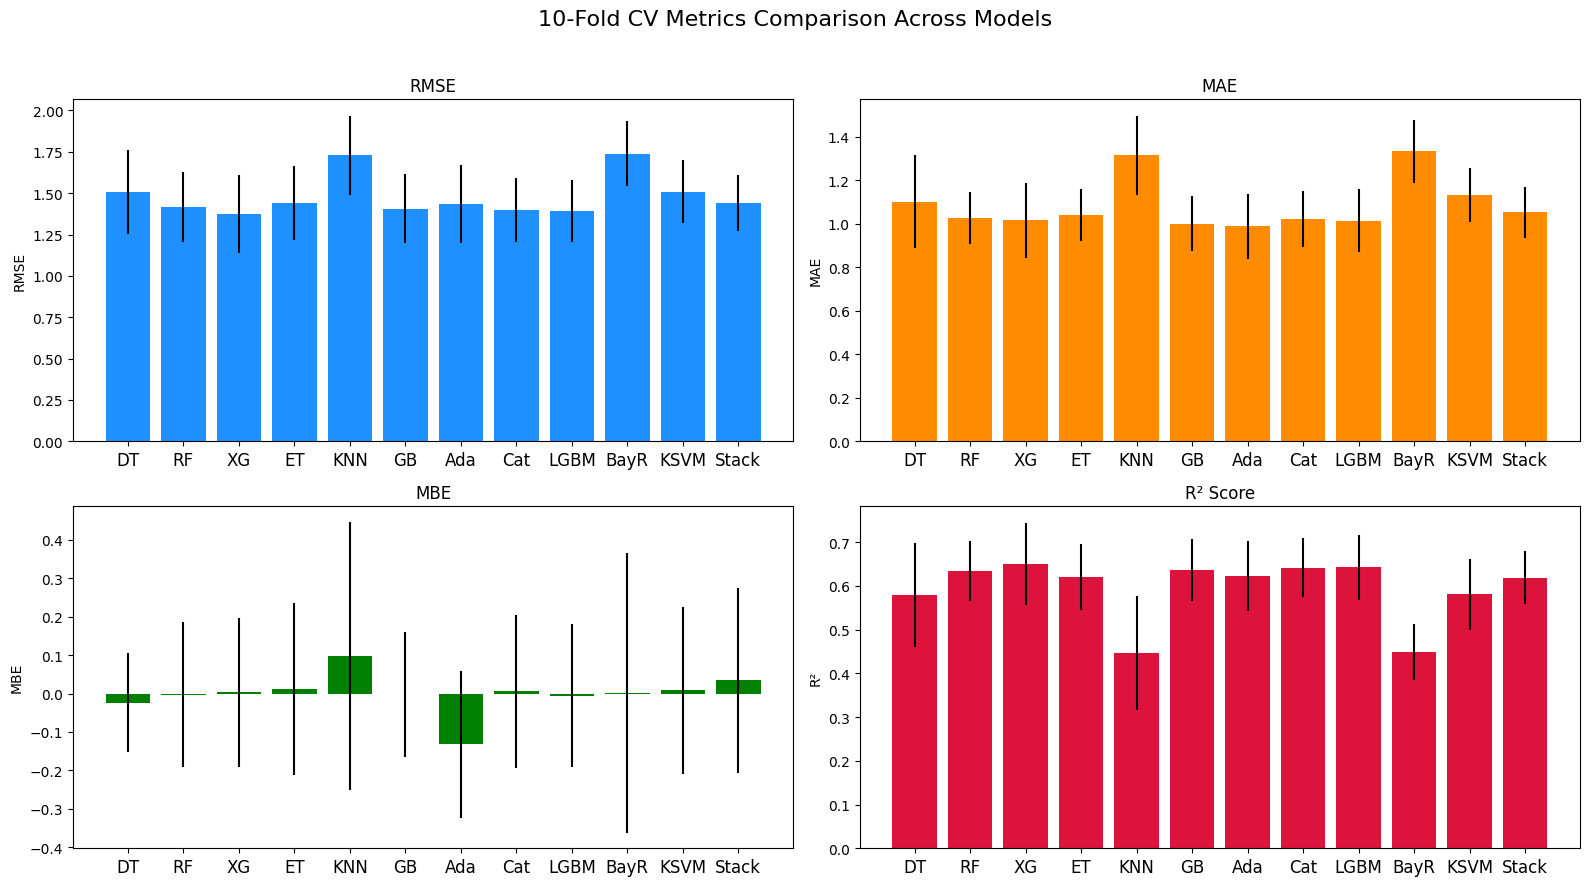

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === STEP 1: Add your model-wise fold metrics ===
# (Assuming your `model_results` dictionary is already defined here)

# === STEP 2: Calculate averages and std devs ===
results = {"Model": [], "RMSE": [], "RMSE_std": [], "MAE": [], "MAE_std": [],
           "MBE": [], "MBE_std": [], "R2": [], "R2_std": []}

for model_name, folds in model_results.items():
    rmse = [f["RMSE"] for f in folds]
    mae = [f["MAE"] for f in folds]
    mbe = [f["MBE"] for f in folds]
    r2 = [f["R2"] for f in folds]

    results["Model"].append(model_name)
    results["RMSE"].append(np.mean(rmse))
    results["RMSE_std"].append(np.std(rmse))
    results["MAE"].append(np.mean(mae))
    results["MAE_std"].append(np.std(mae))
    results["MBE"].append(np.mean(mbe))
    results["MBE_std"].append(np.std(mbe))
    results["R2"].append(np.mean(r2))
    results["R2_std"].append(np.std(r2))

df = pd.DataFrame(results).set_index("Model")

# === STEP 3: Plot ===
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("10-Fold CV Metrics Comparison Across Models", fontsize=16)

axes[0, 0].bar(df.index, df['RMSE'], yerr=df['RMSE_std'], color='dodgerblue')
axes[0, 0].set_title("RMSE")
axes[0, 0].set_ylabel("RMSE")
axes[0, 0].tick_params(axis='x', labelsize=12)  # Increase x-axis font size

axes[0, 1].bar(df.index, df['MAE'], yerr=df['MAE_std'], color='darkorange')
axes[0, 1].set_title("MAE")
axes[0, 1].set_ylabel("MAE")
axes[0, 1].tick_params(axis='x', labelsize=12)

axes[1, 0].bar(df.index, df['MBE'], yerr=df['MBE_std'], color='green')
axes[1, 0].set_title("MBE")
axes[1, 0].set_ylabel("MBE")
axes[1, 0].tick_params(axis='x', labelsize=12)

axes[1, 1].bar(df.index, df['R2'], yerr=df['R2_std'], color='crimson')
axes[1, 1].set_title("R² Score")
axes[1, 1].set_ylabel("R²")
axes[1, 1].tick_params(axis='x', labelsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("foldwise_model_metrics_plot.png", dpi=300)
plt.show()


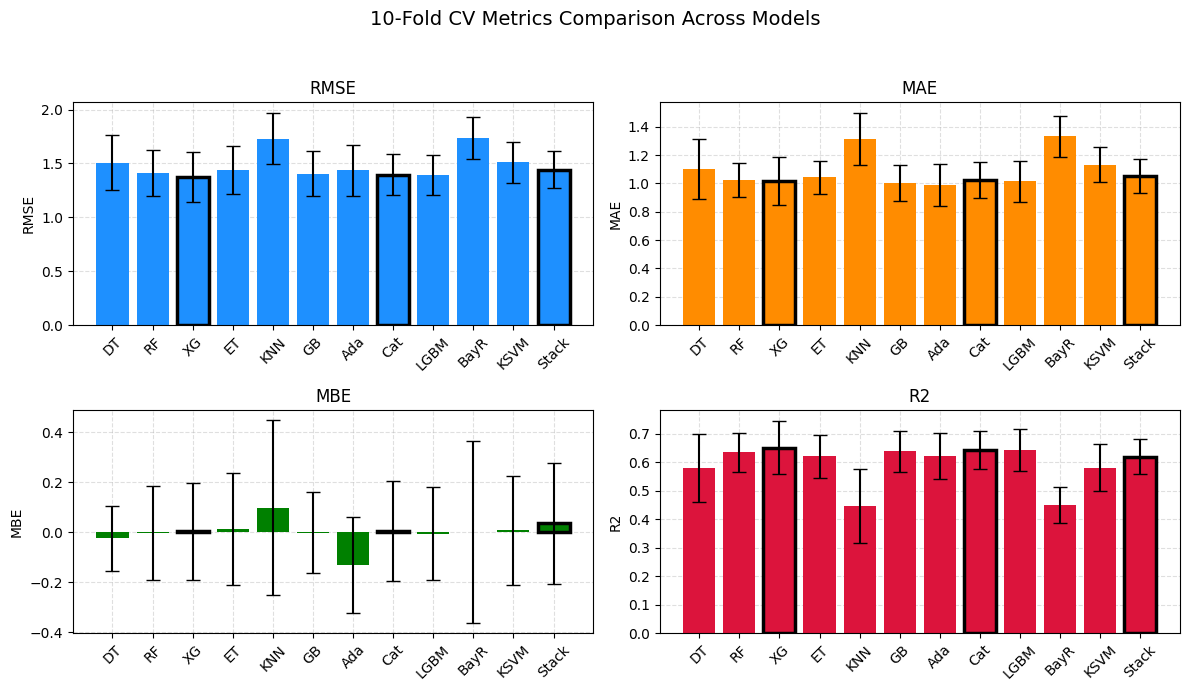

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === STEP 1: Sample input — model_results must be defined ===
# (Assume model_results is already defined above this block)

# === STEP 2: Aggregate metrics ===
results = {"Model": [], "RMSE": [], "RMSE_std": [], "MAE": [], "MAE_std": [],
           "MBE": [], "MBE_std": [], "R2": [], "R2_std": []}

for model_name, folds in model_results.items():
    rmse = [f["RMSE"] for f in folds]
    mae = [f["MAE"] for f in folds]
    mbe = [f["MBE"] for f in folds]
    r2 = [f["R2"] for f in folds]

    results["Model"].append(model_name)
    results["RMSE"].append(np.mean(rmse))
    results["RMSE_std"].append(np.std(rmse))
    results["MAE"].append(np.mean(mae))
    results["MAE_std"].append(np.std(mae))
    results["MBE"].append(np.mean(mbe))
    results["MBE_std"].append(np.std(mbe))
    results["R2"].append(np.mean(r2))
    results["R2_std"].append(np.std(r2))

df = pd.DataFrame(results).set_index("Model")

# === STEP 3: Define best models to highlight ===
best_models = ["Cat","XG", "Stack"]

# === STEP 4: Plot ===
fig, axes = plt.subplots(2, 2, figsize=(12, 7))  # <-- Reduced from (16, 9)
fig.suptitle("10-Fold CV Metrics Comparison Across Models", fontsize=14)  # Smaller title

metrics = ['RMSE', 'MAE', 'MBE', 'R2']
colors = ['dodgerblue', 'darkorange', 'green', 'crimson']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for i, metric in enumerate(metrics):
    row, col = positions[i]
    ax = axes[row, col]
    values = df[metric].values
    errors = df[f"{metric}_std"].values
    model_names = df.index.tolist()

    bars = ax.bar(model_names, values, color=colors[i], zorder=2)
    ax.errorbar(model_names, values, yerr=errors, fmt='none',
                ecolor='black', capsize=5, linewidth=1.5, zorder=3)

    for bar, label in zip(bars, model_names):
        if label in best_models:
            bar.set_edgecolor('black')
            bar.set_linewidth(2.5)

    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', labelsize=10, rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("foldwise_model_metrics_smaller.png", dpi=300)
plt.show()


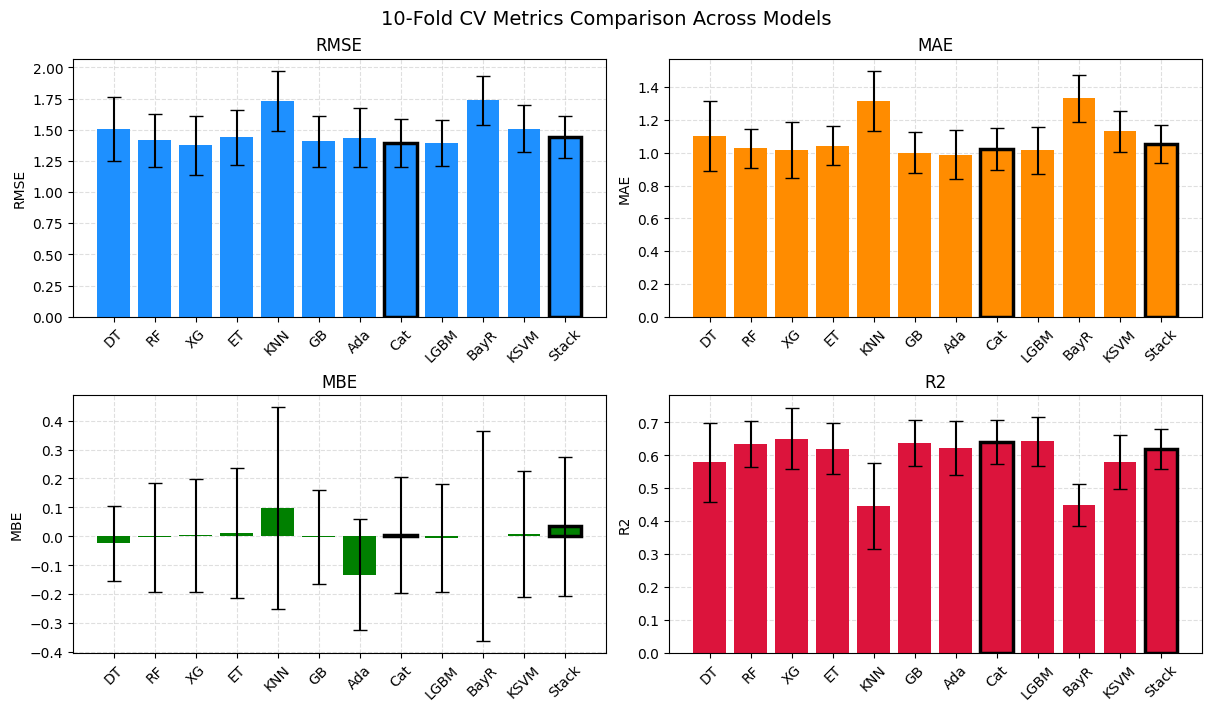

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === STEP 1: Sample input — model_results must be defined ===

# === STEP 2: Aggregate metrics ===
results = {"Model": [], "RMSE": [], "RMSE_std": [], "MAE": [], "MAE_std": [],
           "MBE": [], "MBE_std": [], "R2": [], "R2_std": []}

for model_name, folds in model_results.items():
    rmse = [f["RMSE"] for f in folds]
    mae = [f["MAE"] for f in folds]
    mbe = [f["MBE"] for f in folds]
    r2 = [f["R2"] for f in folds]

    results["Model"].append(model_name)
    results["RMSE"].append(np.mean(rmse))
    results["RMSE_std"].append(np.std(rmse))
    results["MAE"].append(np.mean(mae))
    results["MAE_std"].append(np.std(mae))
    results["MBE"].append(np.mean(mbe))
    results["MBE_std"].append(np.std(mbe))
    results["R2"].append(np.mean(r2))
    results["R2_std"].append(np.std(r2))

df = pd.DataFrame(results).set_index("Model")

# === STEP 3: Define best models to highlight ===
best_models = ["Cat", "Stack"]

# === STEP 4: Plot ===
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)  # 🔥 No extra gap
fig.suptitle("10-Fold CV Metrics Comparison Across Models", fontsize=14)

metrics = ['RMSE', 'MAE', 'MBE', 'R2']
colors = ['dodgerblue', 'darkorange', 'green', 'crimson']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for i, metric in enumerate(metrics):
    row, col = positions[i]
    ax = axes[row, col]
    values = df[metric].values
    errors = df[f"{metric}_std"].values
    model_names = df.index.tolist()

    bars = ax.bar(model_names, values, color=colors[i], zorder=2)
    ax.errorbar(model_names, values, yerr=errors, fmt='none',
                ecolor='black', capsize=5, linewidth=1.5, zorder=3)

    for bar, label in zip(bars, model_names):
        if label in best_models:
            bar.set_edgecolor('black')
            bar.set_linewidth(2.5)

    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', labelsize=10, rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)

# === Save the plot ===
plt.savefig("foldwise_model_metrics_compact.png", dpi=300)
plt.show()


test

🔍 Features used for prediction:
 - Polaris_SC
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - BD_Polaris
 - ncci3all
 - Ksat_Polaris
 - n_Polaris
 - Mid_Slope_Position
 - Senti_BI_1
 - Standard_Height

📊 Test Set Metrics (Random Forest):
MAE:  0.8162
RMSE: 1.0935
R²:   0.4717
MBE:  0.0486


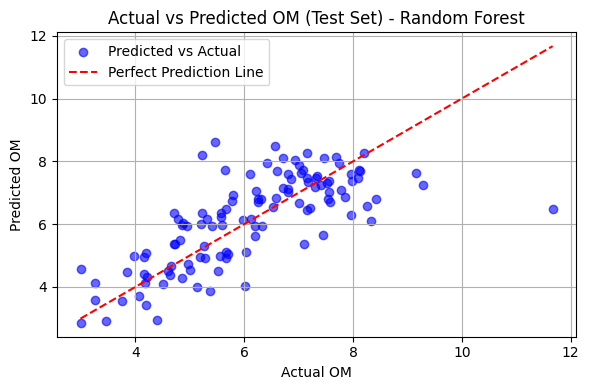

In [ ]:
# === TEST SCRIPT (Random Forest with MBE) ===
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Load model artifacts ===
model = joblib.load("/content/best_rf_model.pkl")  # Random Forest model
scaler = joblib.load("/content/scaler.rf.pkl")
selected_features = joblib.load("/content/selected_features.rf.pkl")

# === Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Scale test data ===
X_test_scaled = scaler.transform(X_test_final)

# === Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

print("\n📊 Test Set Metrics (Random Forest):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")

# === Plot Actual vs Predicted with perfect-fit line ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction Line")
plt.title("Actual vs Predicted OM (Test Set) - Random Forest")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - Polaris_SC
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - BD_Polaris
 - ncci3all
 - Ksat_Polaris
 - n_Polaris
 - Mid_Slope_Position
 - Senti_BI_1
 - Standard_Height

📊 Test Set Metrics (Random Forest):
MAE:  0.8162
RMSE: 1.0935
R²:   0.4717
MBE:  0.0486
RPIQ: 2.0347


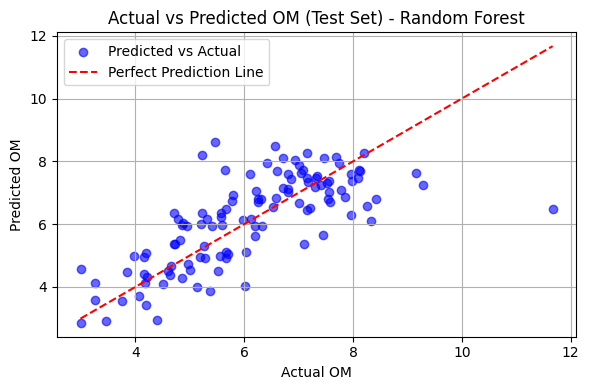

In [ ]:
# === TEST SCRIPT (Random Forest with RPIQ) ===
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Load model artifacts ===
model = joblib.load("/content/best_rf_model.pkl")  # Random Forest model
scaler = joblib.load("/content/scaler.rf.pkl")
selected_features = joblib.load("/content/selected_features.rf.pkl")

# === Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Prepare test features ===
X_test_raw = df_test.drop(
    columns=[
        'OM', 'SAMPLEDATE', 'lati', 'Relative_Elev',
        'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'
    ],
    errors='ignore'
)

y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Scale test data ===
X_test_scaled = scaler.transform(X_test_final)

# === Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse

# === Print results ===
print("\n📊 Test Set Metrics (Random Forest):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")
print(f"RPIQ: {rpiq:.4f}")

# === Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Prediction Line"
)
plt.title("Actual vs Predicted OM (Test Set) - Random Forest")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


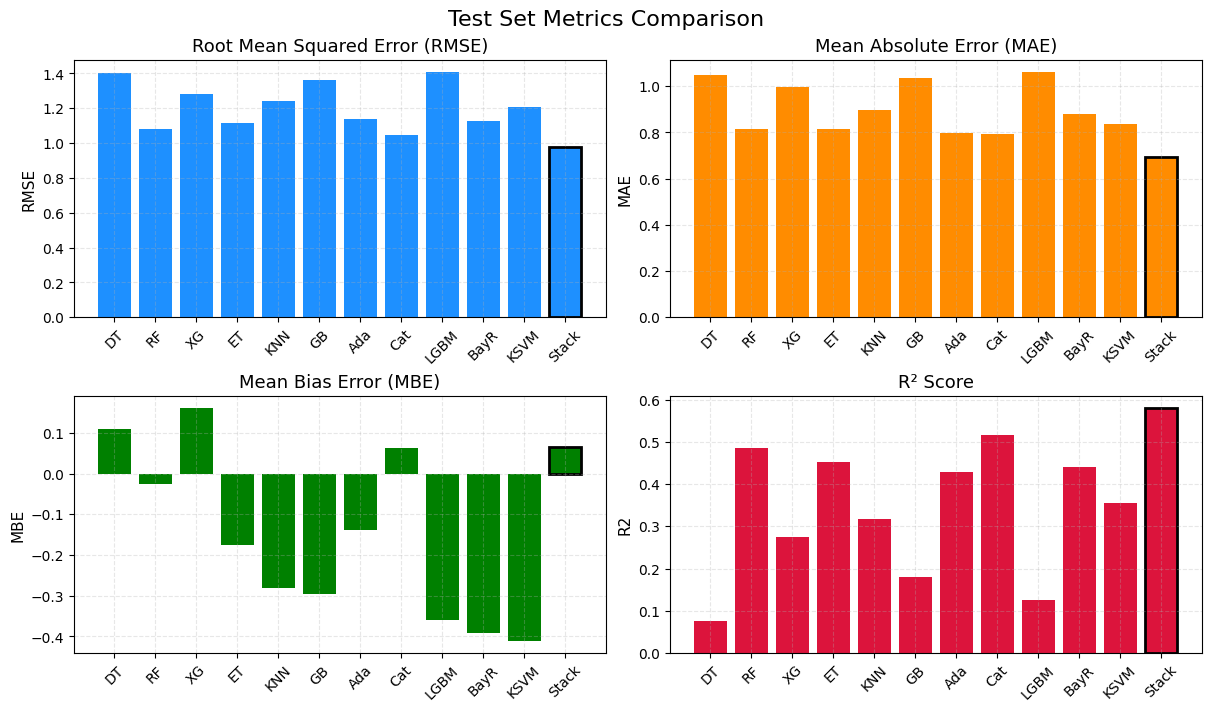

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# === STEP 1: Paste your test set metrics in readable text format ===
test_results_text = {
    "DT": """MAE:  1.0496\nRMSE: 1.4012\nR²:   0.0757\nMBE:  0.1098""",
    "RF": """MAE:  0.8162\nRMSE: 1.0801\nR²:   0.4845\nMBE: -0.0255""",
    "XG": """MAE:  0.999\nRMSE: 1.281\nR²:   0.275\nMBE:  0.162""",
    "ET": """MAE:  0.8136\nRMSE: 1.1123\nR²:   0.4534\nMBE: -0.1762""",
    "KNN": """MAE:  0.8985\nRMSE: 1.2420\nR²:   0.3185\nMBE: -0.2807""",
    "GB": """MAE:  1.0342\nRMSE: 1.3623\nR²:   0.1801\nMBE: -0.2955""",
    "Ada": """MAE:  0.7961\nRMSE: 1.1381\nR²:   0.428\nMBE: -0.138""",
    "Cat": """MAE:  0.7917\nRMSE: 1.0466\nR²:   0.5161\nMBE:  0.0633""",
    "LGBM": """MAE:  1.0609\nRMSE: 1.4064\nR²:   0.1261\nMBE: -0.3606""",
    "BayR": """MAE:  0.8810\nRMSE: 1.1255\nR²:   0.4403\nMBE: -0.3907""",
    "KSVM": """MAE:  0.8384\nRMSE: 1.2085\nR²:   0.3548\nMBE:  -0.4120""",
    "Stack": """MAE:  0.694\nRMSE: 0.979\nR²:   0.58\nMBE:  0.066""",
}




# === STEP 2: Parse metrics ===
def parse_metrics_block(text):
    metrics = {}
    for line in text.strip().splitlines():
        match = re.match(r'([A-Za-z²]+):\s+([-+]?\d*\.\d+|\d+)', line.strip())
        if match:
            key = match.group(1).replace('R²', 'R2')
            metrics[key] = float(match.group(2))
    return metrics

parsed_results = {model: parse_metrics_block(text) for model, text in test_results_text.items()}

# === STEP 3: Convert to DataFrame with custom order ===
df = pd.DataFrame(parsed_results).T
df.index.name = "Model"
custom_order = ["DT", "RF", "XG", "ET", "KNN", "GB", "Ada", "Cat", "LGBM", "BayR", "KSVM", "Stack"]
df = df.loc[custom_order]

# === STEP 4: Highlight the best model based on R² ===
highlight_model = df['R2'].idxmax()

# === STEP 5: Plotting with clean layout ===
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
fig.suptitle("Test Set Metrics Comparison", fontsize=16)

def plot_metric(ax, metric, color, title):
    bars = ax.bar(df.index, df[metric], color=color)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(metric, fontsize=11)
    ax.tick_params(axis='x', labelsize=10, labelrotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    for bar, label in zip(bars, df.index):
        if label == highlight_model:
            bar.set_edgecolor("black")
            bar.set_linewidth(2)

plot_metric(axes[0, 0], 'RMSE', 'dodgerblue', "Root Mean Squared Error (RMSE)")
plot_metric(axes[0, 1], 'MAE', 'darkorange', "Mean Absolute Error (MAE)")
plot_metric(axes[1, 0], 'MBE', 'green', "Mean Bias Error (MBE)")
plot_metric(axes[1, 1], 'R2', 'crimson', "R² Score")

plt.savefig("test_metrics_summary_clean_nogap.png", dpi=300)
plt.show()


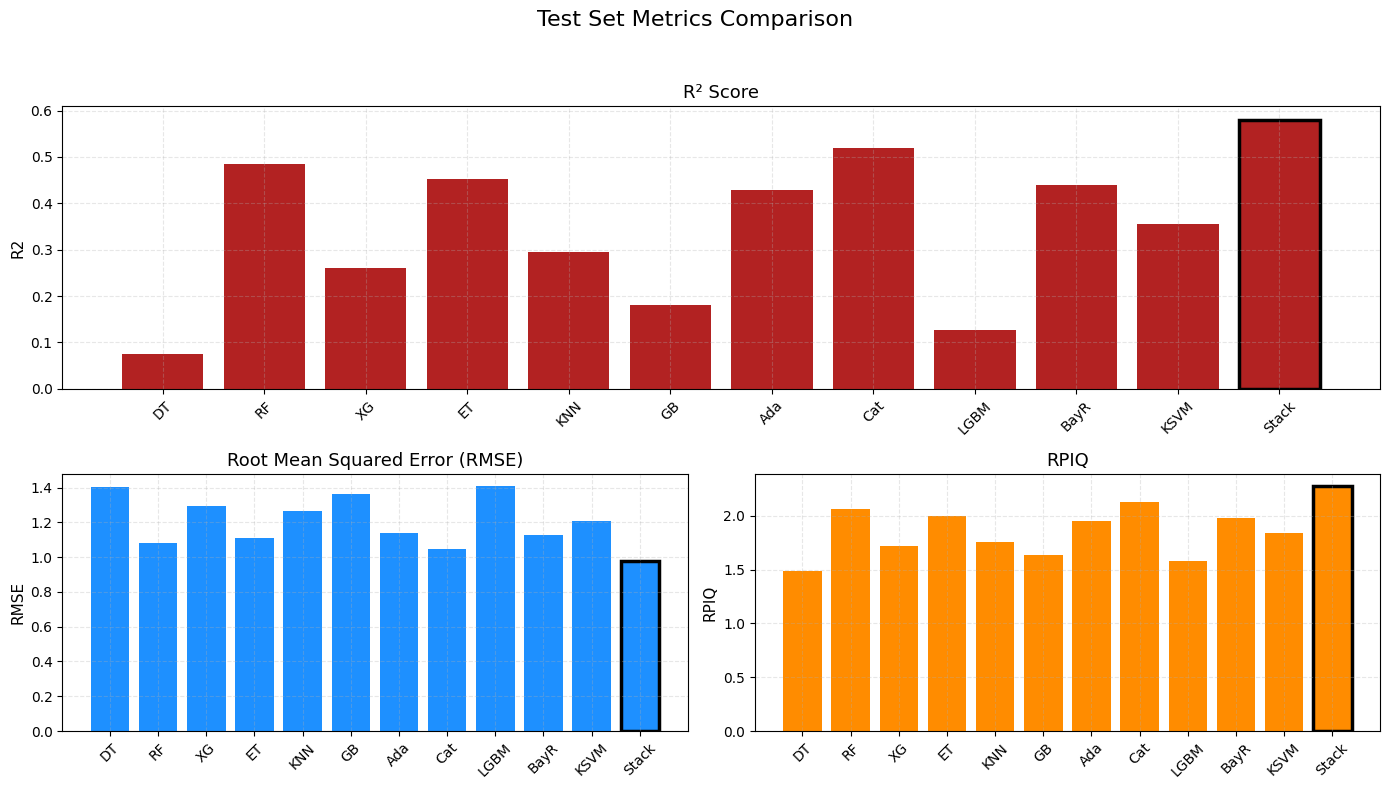

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# =========================================================
# STEP 1: Test set metrics (RMSE, R², RPIQ)
# =========================================================
test_results_text = {
    "RF": """RMSE: 1.0801
R²:   0.4845
RPIQ: 2.0600""",

    "ET": """RMSE: 1.1123
R²:   0.4534
RPIQ: 2.0004""",

    "KNN": """RMSE: 1.2640
R²:   0.2941
RPIQ: 1.7603""",

    "GB": """RMSE: 1.3623
R²:   0.1801
RPIQ: 1.6333""",

    "DT": """RMSE: 1.4012
R²:   0.0757
RPIQ: 1.4844""",

    "XG": """RMSE: 1.293
R²:   0.261
RPIQ: 1.721""",

    "Ada": """RMSE: 1.1381
R²:   0.4278
RPIQ: 1.9551""",

    "Cat": """RMSE: 1.047
R²:   0.52
RPIQ: 2.126""",

    "LGBM": """RMSE: 1.4064
R²:   0.1261
RPIQ: 1.5821""",

    "BayR": """RMSE: 1.1255
R²:   0.4403
RPIQ: 1.9769""",

    "KSVM": """RMSE: 1.2085
R²:   0.3548
RPIQ: 1.8412""",

    "Stack": """RMSE: 0.979
R²:   0.58
RPIQ: 2.274""",
}

# =========================================================
# STEP 2: Parse metrics
# =========================================================
def parse_metrics_block(text):
    metrics = {}
    for line in text.strip().splitlines():
        match = re.match(r'([A-Za-z²]+):\s+([-+]?\d*\.\d+|\d+)', line.strip())
        if match:
            key = match.group(1).replace('R²', 'R2')
            metrics[key] = float(match.group(2))
    return metrics

parsed_results = {m: parse_metrics_block(t) for m, t in test_results_text.items()}

# =========================================================
# STEP 3: DataFrame + order
# =========================================================
df = pd.DataFrame(parsed_results).T
df.index.name = "Model"

order = ["DT", "RF", "XG", "ET", "KNN", "GB", "Ada",
         "Cat", "LGBM", "BayR", "KSVM", "Stack"]
df = df.loc[order]

# =========================================================
# STEP 4: Highlight best model (RPIQ)
# =========================================================
highlight_model = df["RPIQ"].idxmax()

# =========================================================
# STEP 5: Publication-ready layout (R² top, others bottom)
# =========================================================
fig = plt.figure(figsize=(14, 8))
fig.suptitle("Test Set Metrics Comparison", fontsize=16)

gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1])

ax_r2   = fig.add_subplot(gs[0, :])   # top row (full width)
ax_rmse = fig.add_subplot(gs[1, 0])   # bottom-left
ax_rpiq = fig.add_subplot(gs[1, 1])   # bottom-right

def plot_metric(ax, metric, color, title):
    bars = ax.bar(df.index, df[metric], color=color)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(metric, fontsize=11)
    ax.tick_params(axis='x', labelsize=10, rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    for bar, label in zip(bars, df.index):
        if label == highlight_model:
            bar.set_edgecolor("black")
            bar.set_linewidth(2.5)

# === Plot ===
plot_metric(ax_r2,   "R2",   "firebrick", "R² Score")
plot_metric(ax_rmse, "RMSE", "dodgerblue", "Root Mean Squared Error (RMSE)")
plot_metric(ax_rpiq, "RPIQ", "darkorange", "RPIQ")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("test_metrics_publication_layout.png", dpi=300)
plt.show()


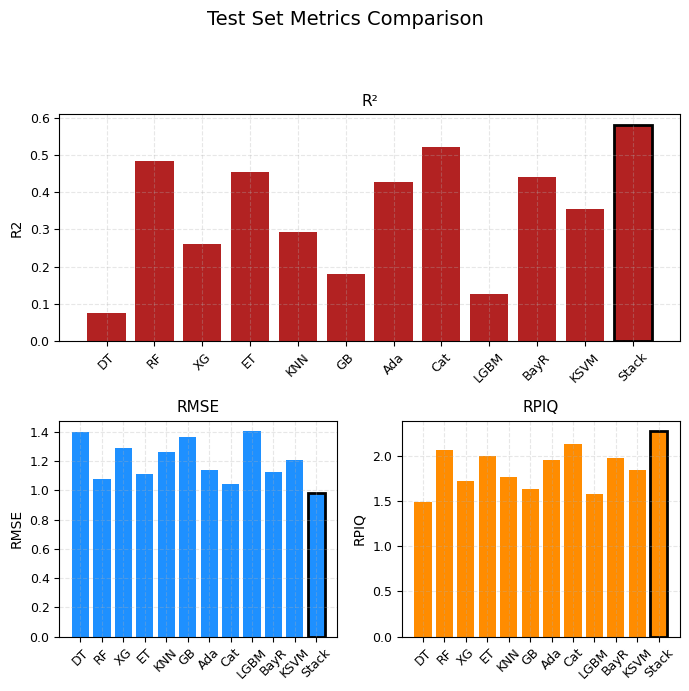

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# =========================================================
# STEP 1: Test set metrics (RMSE, R², RPIQ)
# =========================================================
test_results_text = {
    "RF": """RMSE: 1.0801
R²:   0.4845
RPIQ: 2.0600""",
    "ET": """RMSE: 1.1123
R²:   0.4534
RPIQ: 2.0004""",
    "KNN": """RMSE: 1.2640
R²:   0.2941
RPIQ: 1.7603""",
    "GB": """RMSE: 1.3623
R²:   0.1801
RPIQ: 1.6333""",
    "DT": """RMSE: 1.4012
R²:   0.0757
RPIQ: 1.4844""",
    "XG": """RMSE: 1.293
R²:   0.261
RPIQ: 1.721""",
    "Ada": """RMSE: 1.1381
R²:   0.4278
RPIQ: 1.9551""",
    "Cat": """RMSE: 1.047
R²:   0.52
RPIQ: 2.126""",
    "LGBM": """RMSE: 1.4064
R²:   0.1261
RPIQ: 1.5821""",
    "BayR": """RMSE: 1.1255
R²:   0.4403
RPIQ: 1.9769""",
    "KSVM": """RMSE: 1.2085
R²:   0.3548
RPIQ: 1.8412""",
    "Stack": """RMSE: 0.979
R²:   0.58
RPIQ: 2.274""",
}

# =========================================================
# STEP 2: Parse metrics
# =========================================================
def parse_metrics_block(text):
    metrics = {}
    for line in text.strip().splitlines():
        match = re.match(r'([A-Za-z²]+):\s+([-+]?\d*\.\d+|\d+)', line.strip())
        if match:
            key = match.group(1).replace('R²', 'R2')
            metrics[key] = float(match.group(2))
    return metrics

df = pd.DataFrame({m: parse_metrics_block(t) for m, t in test_results_text.items()}).T
df.index.name = "Model"

order = ["DT", "RF", "XG", "ET", "KNN", "GB", "Ada",
         "Cat", "LGBM", "BayR", "KSVM", "Stack"]
df = df.loc[order]

highlight_model = df["RPIQ"].idxmax()

# =========================================================
# STEP 3: Word-friendly figure layout (smaller)
# =========================================================
fig = plt.figure(figsize=(7, 7))  # 🔽 reduced size
fig.suptitle("Test Set Metrics Comparison", fontsize=14)

gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1])

ax_r2   = fig.add_subplot(gs[0, :])
ax_rmse = fig.add_subplot(gs[1, 0])
ax_rpiq = fig.add_subplot(gs[1, 1])

def plot_metric(ax, metric, color, title):
    bars = ax.bar(df.index, df[metric], color=color)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

    for bar, label in zip(bars, df.index):
        if label == highlight_model:
            bar.set_edgecolor("black")
            bar.set_linewidth(2)

plot_metric(ax_r2,   "R2",   "firebrick", "R²")
plot_metric(ax_rmse, "RMSE", "dodgerblue", "RMSE")
plot_metric(ax_rpiq, "RPIQ", "darkorange", "RPIQ")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("test_metrics_publication_layout_word.png", dpi=300)
plt.show()


Train

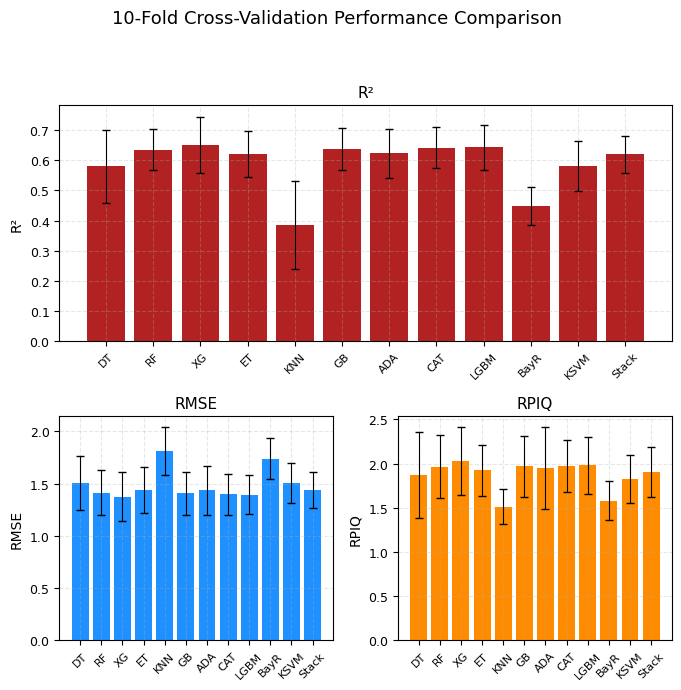

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# STEP 1: Models
# =========================================================
models = ['DT', 'RF', 'XG', 'ET', 'KNN', 'GB',
          'ADA', 'CAT', 'LGBM', 'BayR', 'KSVM', 'Stack']

# =========================================================
# STEP 2: Per-fold metrics (unchanged data)
# =========================================================
RMSE = {
    'DT': [1.5321,1.6906,0.8272,1.7011,1.6636,1.3008,1.6764,1.6370,1.4751,1.5536],
    'RF': [1.6580,1.5862,0.9376,1.4918,1.5752,1.2592,1.3089,1.2924,1.3881,1.6412],
    'XG': [1.523,1.692,0.938,1.451,1.638,1.122,1.347,1.244,1.196,1.589],
    'ET': [1.5484,1.6450,1.1103,1.4078,1.7027,1.2641,1.2793,1.3695,1.2209,1.8367],
    'KNN': [1.7445,2.1625,1.4056,1.9607,1.7026,1.9987,1.5854,1.7769,1.7006,2.1262],
    'GB': [1.4479,1.5887,0.9470,1.3949,1.6759,1.2306,1.4296,1.3892,1.2993,1.6612],
    'ADA': [1.5791,1.6461,0.8252,1.5158,1.6554,1.3065,1.3470,1.5285,1.3731,1.5910],
    'CAT': [1.5102,1.5493,1.0453,1.5050,1.6206,1.1614,1.3337,1.2970,1.2873,1.6581],
    'LGBM': [1.4270,1.4918,0.9503,1.6144,1.5814,1.2936,1.3551,1.3113,1.3210,1.5815],
    'BayR': [1.8954,1.8775,1.2384,1.7024,1.9422,1.7287,1.6232,1.6965,1.7517,1.9169],
    'KSVM': [1.6213,1.7929,1.0639,1.4991,1.6515,1.4989,1.4873,1.4333,1.3740,1.6699],
    'Stack': [1.5664,1.5852,1.0120,1.5048,1.5594,1.3267,1.4684,1.3701,1.3893,1.6241]
}

R2 = {
    'DT': [0.6526,0.4526,0.8020,0.4203,0.5680,0.6659,0.3997,0.5688,0.6030,0.6603],
    'RF': [0.5932,0.5182,0.7456,0.5542,0.6127,0.6869,0.6341,0.7312,0.6484,0.6210],
    'XG': [0.657,0.452,0.745,0.578,0.581,0.751,0.612,0.751,0.739,0.645],
    'ET': [0.6452,0.4818,0.6433,0.6030,0.5475,0.6845,0.6505,0.6982,0.7280,0.5253],
    'KNN': [0.5496,0.1045,0.4283,0.2299,0.5476,0.2112,0.4632,0.4919,0.4723,0.3638],
    'GB': [0.6897,0.5166,0.7405,0.6103,0.5616,0.7010,0.5635,0.6895,0.6920,0.6117],
    'ADA': [0.6310,0.4811,0.8030,0.5398,0.5723,0.6629,0.6125,0.6241,0.6560,0.6438],
    'CAT': [0.6625,0.5403,0.6839,0.5463,0.5901,0.7337,0.6201,0.7293,0.6976,0.6131],
    'LGBM': [0.6986,0.5738,0.7387,0.4779,0.6097,0.6696,0.6078,0.7233,0.6816,0.6480],
    'BayR': [0.4683,0.3249,0.5562,0.4195,0.4112,0.4099,0.4372,0.5369,0.4401,0.4829],
    'KSVM': [0.6110,0.3844,0.6725,0.5498,0.5743,0.5564,0.5275,0.6695,0.6555,0.6076],
    'Stack': [0.6369,0.5188,0.7037,0.5464,0.6204,0.6524,0.5395,0.6979,0.6478,0.6288]
}

RPIQ = {
    'DT': [1.7623,1.5970,3.2640,1.5872,1.6230,2.0756,1.6106,1.6493,1.8304,1.7379],
    'RF': [1.6285,1.7022,2.8796,1.8098,1.7140,2.1443,2.0628,2.0891,1.9451,1.6452],
    'XG': [1.77,1.60,2.88,1.86,1.65,2.41,2.00,2.17,2.26,1.70],
    'ET': [1.7437,1.6414,2.4318,1.9179,1.5858,2.1359,2.1106,1.9715,2.2116,1.4700],
    'KNN': [1.5477,1.2486,1.9209,1.3770,1.5858,1.3509,1.7031,1.5195,1.5877,1.2699],
    'GB': [1.8647,1.6995,2.8510,1.9357,1.6111,2.1941,1.8886,1.9436,2.0780,1.6254],
    'ADA': [1.71,1.64,3.27,1.78,1.63,2.07,2.00,1.77,1.97,1.70],
    'CAT': [1.79,1.74,2.58,1.79,1.67,2.32,2.02,2.08,2.10,1.63],
    'LGBM': [1.89,1.81,2.84,1.67,1.71,2.09,1.99,2.06,2.04,1.71],
    'BayR': [1.42,1.44,2.18,1.59,1.39,1.56,1.66,1.59,1.54,1.41],
    'KSVM': [1.67,1.51,2.54,1.80,1.63,1.80,1.82,1.88,1.97,1.62],
    'Stack': [1.72,1.70,2.67,1.79,1.73,2.04,1.84,1.97,1.94,1.66]
}

# =========================================================
# STEP 3: Mean ± Std
# =========================================================
def mean_std(d):
    return np.array([np.mean(d[m]) for m in models]), np.array([np.std(d[m]) for m in models])

rmse_mean, rmse_std = mean_std(RMSE)
r2_mean, r2_std     = mean_std(R2)
rpiq_mean, rpiq_std = mean_std(RPIQ)

# =========================================================
# STEP 4: Publication-ready plot (NO highlighting)
# =========================================================
fig = plt.figure(figsize=(7,7))
fig.suptitle("10-Fold Cross-Validation Performance Comparison", fontsize=13)

gs = fig.add_gridspec(2,2, height_ratios=[1.05,1])

ax_r2   = fig.add_subplot(gs[0,:])
ax_rmse = fig.add_subplot(gs[1,0])
ax_rpiq = fig.add_subplot(gs[1,1])

def plot(ax, mean, std, title, ylabel, color):
    ax.bar(
        models, mean,
        yerr=std,
        capsize=3,
        error_kw=dict(elinewidth=0.8),
        color=color
    )
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plot(ax_r2,   r2_mean,   r2_std,   "R²",   "R²",   "firebrick")
plot(ax_rmse, rmse_mean, rmse_std, "RMSE", "RMSE", "dodgerblue")
plot(ax_rpiq, rpiq_mean, rpiq_std, "RPIQ", "RPIQ", "darkorange")

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig("cv_metrics_publication_neutral.png", dpi=300)
plt.show()


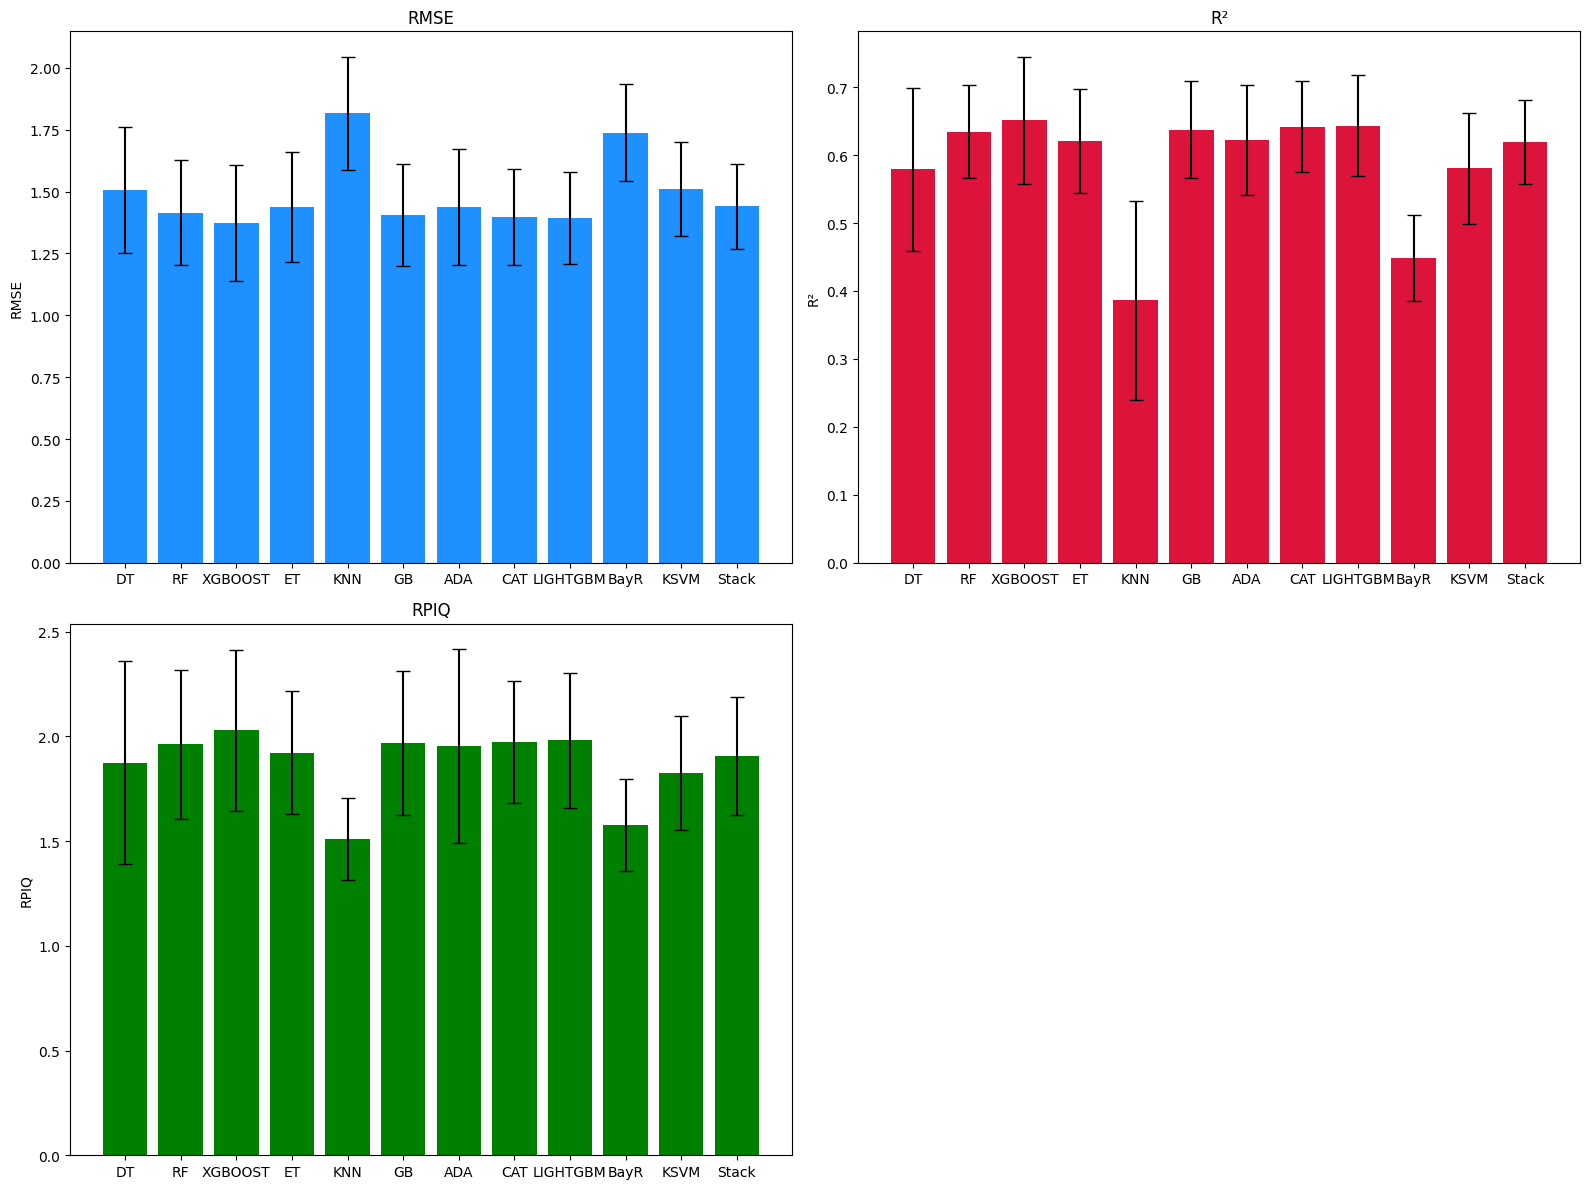

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Models in the desired order
models = ['DT', 'RF', 'XGBOOST', 'ET', 'KNN', 'GB', 'ADA', 'CAT', 'LIGHTGBM', 'BayR', 'KSVM', 'Stack']

# Per-fold RMSE
RMSE = {
    'DT': [1.5321,1.6906,0.8272,1.7011,1.6636,1.3008,1.6764,1.6370,1.4751,1.5536],
    'RF': [1.6580,1.5862,0.9376,1.4918,1.5752,1.2592,1.3089,1.2924,1.3881,1.6412],
    'XGBOOST': [1.523,1.692,0.938,1.451,1.638,1.122,1.347,1.244,1.196,1.589],
    'ET': [1.5484,1.6450,1.1103,1.4078,1.7027,1.2641,1.2793,1.3695,1.2209,1.8367],
    'KNN': [1.7445,2.1625,1.4056,1.9607,1.7026,1.9987,1.5854,1.7769,1.7006,2.1262],
    'GB': [1.4479,1.5887,0.9470,1.3949,1.6759,1.2306,1.4296,1.3892,1.2993,1.6612],
    'ADA': [1.5791,1.6461,0.8252,1.5158,1.6554,1.3065,1.3470,1.5285,1.3731,1.5910],
    'CAT': [1.5102,1.5493,1.0453,1.5050,1.6206,1.1614,1.3337,1.2970,1.2873,1.6581],
    'LIGHTGBM': [1.4270,1.4918,0.9503,1.6144,1.5814,1.2936,1.3551,1.3113,1.3210,1.5815],
    'BayR': [1.8954,1.8775,1.2384,1.7024,1.9422,1.7287,1.6232,1.6965,1.7517,1.9169],
    'KSVM': [1.6213,1.7929,1.0639,1.4991,1.6515,1.4989,1.4873,1.4333,1.3740,1.6699],
    'Stack': [1.5664,1.5852,1.0120,1.5048,1.5594,1.3267,1.4684,1.3701,1.3893,1.6241]
}

# Per-fold R²
R2 = {
    'DT': [0.6526,0.4526,0.8020,0.4203,0.5680,0.6659,0.3997,0.5688,0.6030,0.6603],
    'RF': [0.5932,0.5182,0.7456,0.5542,0.6127,0.6869,0.6341,0.7312,0.6484,0.6210],
    'XGBOOST': [0.657,0.452,0.745,0.578,0.581,0.751,0.612,0.751,0.739,0.645],
    'ET': [0.6452,0.4818,0.6433,0.6030,0.5475,0.6845,0.6505,0.6982,0.7280,0.5253],
    'KNN': [0.5496,0.1045,0.4283,0.2299,0.5476,0.2112,0.4632,0.4919,0.4723,0.3638],
    'GB': [0.6897,0.5166,0.7405,0.6103,0.5616,0.7010,0.5635,0.6895,0.6920,0.6117],
    'ADA': [0.6310,0.4811,0.8030,0.5398,0.5723,0.6629,0.6125,0.6241,0.6560,0.6438],
    'CAT': [0.6625,0.5403,0.6839,0.5463,0.5901,0.7337,0.6201,0.7293,0.6976,0.6131],
    'LIGHTGBM': [0.6986,0.5738,0.7387,0.4779,0.6097,0.6696,0.6078,0.7233,0.6816,0.6480],
    'BayR': [0.4683,0.3249,0.5562,0.4195,0.4112,0.4099,0.4372,0.5369,0.4401,0.4829],
    'KSVM': [0.6110,0.3844,0.6725,0.5498,0.5743,0.5564,0.5275,0.6695,0.6555,0.6076],
    'Stack': [0.6369,0.5188,0.7037,0.5464,0.6204,0.6524,0.5395,0.6979,0.6478,0.6288]
}

# Per-fold RPIQ
RPIQ = {
    'DT': [1.7623,1.5970,3.2640,1.5872,1.6230,2.0756,1.6106,1.6493,1.8304,1.7379],
    'RF': [1.6285,1.7022,2.8796,1.8098,1.7140,2.1443,2.0628,2.0891,1.9451,1.6452],
    'XGBOOST': [1.77,1.60,2.88,1.86,1.65,2.41,2.00,2.17,2.26,1.70],
    'ET': [1.7437,1.6414,2.4318,1.9179,1.5858,2.1359,2.1106,1.9715,2.2116,1.4700],
    'KNN': [1.5477,1.2486,1.9209,1.3770,1.5858,1.3509,1.7031,1.5195,1.5877,1.2699],
    'GB': [1.8647,1.6995,2.8510,1.9357,1.6111,2.1941,1.8886,1.9436,2.0780,1.6254],
    'ADA': [1.71,1.64,3.27,1.78,1.63,2.07,2.00,1.77,1.97,1.70],
    'CAT': [1.79,1.74,2.58,1.79,1.67,2.32,2.02,2.08,2.10,1.63],
    'LIGHTGBM': [1.89,1.81,2.84,1.67,1.71,2.09,1.99,2.06,2.04,1.71],
    'BayR': [1.42,1.44,2.18,1.59,1.39,1.56,1.66,1.59,1.54,1.41],
    'KSVM': [1.67,1.51,2.54,1.80,1.63,1.80,1.82,1.88,1.97,1.62],
    'Stack': [1.72,1.70,2.67,1.79,1.73,2.04,1.84,1.97,1.94,1.66]
}

# Helper function: mean ± std
def mean_std_dict(d):
    mean = [np.mean(d[m]) for m in models]
    std = [np.std(d[m]) for m in models]
    return mean, std

rmse_mean, rmse_std = mean_std_dict(RMSE)
r2_mean, r2_std = mean_std_dict(R2)
rpiq_mean, rpiq_std = mean_std_dict(RPIQ)

# Plot
fig, axs = plt.subplots(2,2, figsize=(16,12))

# RMSE
axs[0,0].bar(models, rmse_mean, yerr=rmse_std, capsize=5, color='dodgerblue')
axs[0,0].set_title('RMSE')
axs[0,0].set_ylabel('RMSE')

# R²
axs[0,1].bar(models, r2_mean, yerr=r2_std, capsize=5, color='crimson')
axs[0,1].set_title('R²')
axs[0,1].set_ylabel('R²')

# RPIQ
axs[1,0].bar(models, rpiq_mean, yerr=rpiq_std, capsize=5, color='green')
axs[1,0].set_title('RPIQ')
axs[1,0].set_ylabel('RPIQ')

# Hide the 4th subplot (optional)
axs[1,1].axis('off')

plt.tight_layout()
plt.show()


  et

Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ Best Hyperparameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1626, MAE: 1.1363, RMSE: 1.5902, R²: 0.6257
Fold 2 → MBE: -0.1847, MAE: 1.2477, RMSE: 1.7068, R²: 0.4421
Fold 3 → MBE: 0.4529, MAE: 0.7712, RMSE: 0.9928, R²: 0.7148
Fold 4 → MBE: 0.0458, MAE: 0.9828, RMSE: 1.3926, R²: 0.6115
Fold 5 → MBE: -0.1357, MAE: 1.2098, RMSE: 1.7050, R²: 0.5463
Fold 6 → MBE: 0.3410, MAE: 0.9812, RMSE: 1.3408, R²: 0.6450
Fold 7 → MBE: 0.1213, MAE: 1.0419, RMSE: 1.2721, R²: 0.6544
Fold 8 → MBE: -0.0883, MAE: 0.9162, RMSE: 1.3629, R²: 0.7011
Fold 9 → MBE: 0.0232, MAE: 0.9065, RMSE: 1.2170, R²: 0.7298
Fold 10 → MBE: -0.2194, MAE: 1.1441, RMSE: 1.7664, R²: 0.5609

📌 Average 10-Fold Train Metrics:
MBE:  0.0194
MAE:  1.0338
RMSE: 1.4347
R²:   0.6232


/tmp/ipython-input-183907127.py:106: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


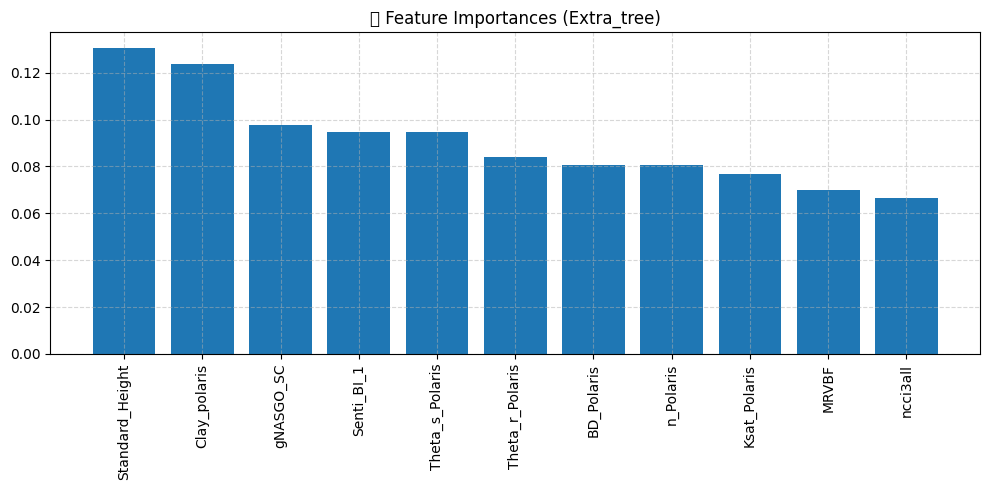

In [ ]:
# === All-in-One Training Script with ExtraTreesRegressor ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1','SAND_Polaris', 'Lamda_Polaris'
], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=ExtraTreesRegressor(n_estimators=100, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Print best hyperparameters ===
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Train Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Model Artifacts ===
joblib.dump(best_model, "best_et_model.pkl")
joblib.dump(scaler, "scaler.et.pkl")
joblib.dump(list(selected_features), "selected_features.et.pkl")

# === Step 9: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("📈 Feature Importances (Extra_tree)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.show()

/tmp/ipython-input-2793328684.py:9: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


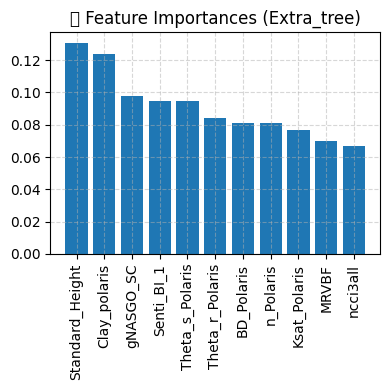

In [ ]:
# === Step 9: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(4, 4))
plt.title("📈 Feature Importances (Extra_tree)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.show()

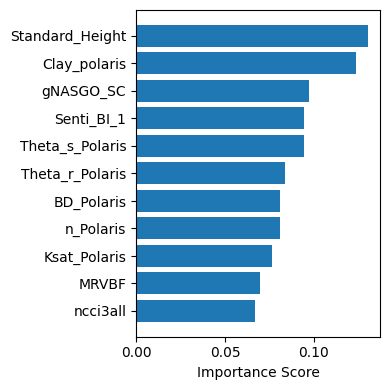

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importances and sorting
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Plotting
plt.figure(figsize=(4, 4), facecolor='white')  # clean white background

plt.barh(range(len(selected_features)), importances[sorted_idx], color='#1f77b4')
plt.yticks(range(len(selected_features)), np.array(selected_features)[sorted_idx])
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # highest importance on top
#plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ Best Hyperparameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1626, MAE: 1.1363, RMSE: 1.5902, R²: 0.6257, RPIQ: 1.9463
Fold 2 → MBE: -0.1847, MAE: 1.2477, RMSE: 1.7068, R²: 0.4421, RPIQ: 1.5160
Fold 3 → MBE: 0.4529, MAE: 0.7712, RMSE: 0.9928, R²: 0.7148, RPIQ: 2.3317
Fold 4 → MBE: 0.0458, MAE: 0.9828, RMSE: 1.3926, R²: 0.6115, RPIQ: 1.9101
Fold 5 → MBE: -0.1357, MAE: 1.2098, RMSE: 1.7050, R²: 0.5463, RPIQ: 1.5880
Fold 6 → MBE: 0.3410, MAE: 0.9812, RMSE: 1.3408, R²: 0.6450, RPIQ: 1.6409
Fold 7 → MBE: 0.1213, MAE: 1.0419, RMSE: 1.2721, R²: 0.6544, RPIQ: 2.3268
Fold 8 → MBE: -0.0883, MAE: 0.9162, RMSE: 1.3629, R²: 0.7011, RPIQ: 2.1278
Fold 9 → MBE: 0.0232, MAE: 0.9065, RMSE: 1.2170, R²: 0.7298, RPIQ: 1.9064
Fold 10 → MBE: -0.2194, MAE: 1.1441, RMSE: 1.7664, R²: 0.5609, RPIQ: 1.6587

📌 Average 10-Fold CV Metrics:
MBE: 

/tmp/ipython-input-808924789.py:139: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


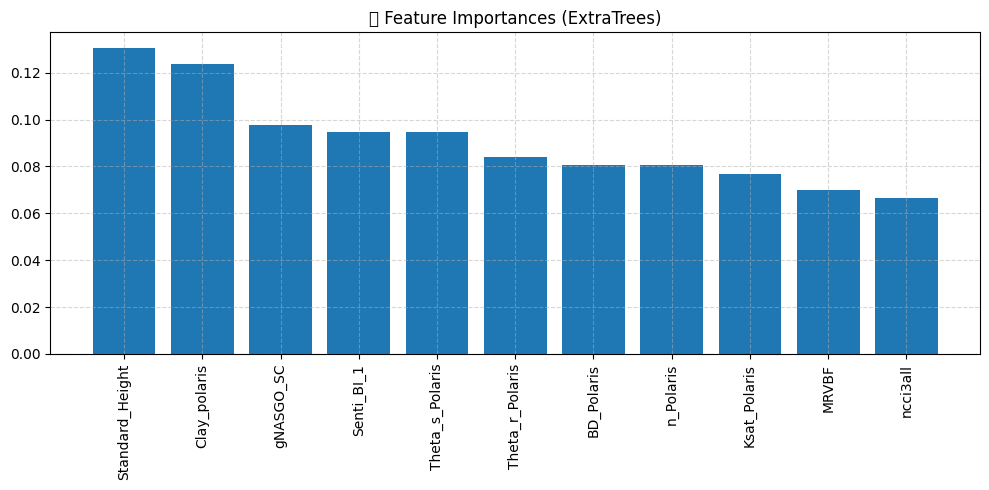

In [ ]:
# === All-in-One Training Script with ExtraTreesRegressor + RPIQ ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=[
        'OM', 'SAMPLEDATE', 'lati', 'Relative_Elev',
        'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'
    ],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])

rfe = RFE(
    estimator=ExtraTreesRegressor(n_estimators=100, random_state=42),
    n_features_to_select=num_features
)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Print best hyperparameters ===
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 6: 10-fold Cross-Validation with RPIQ ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [], 'mae': [], 'rmse': [], 'r2': [], 'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    # === RPIQ calculation (based on observed OM in validation fold) ===
    q75, q25 = np.percentile(y_v, [75, 25])
    iqr = q75 - q25
    rpiq = iqr / rmse if rmse != 0 else np.nan

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {i} → "
        f"MBE: {mbe:.4f}, "
        f"MAE: {mae:.4f}, "
        f"RMSE: {rmse:.4f}, "
        f"R²: {r2:.4f}, "
        f"RPIQ: {rpiq:.4f}"
    )

# === Step 7: Average CV Metrics ===
print("\n📌 Average 10-Fold CV Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 8: Save Model Artifacts ===
joblib.dump(best_model, "best_et_model.pkl")
joblib.dump(scaler, "scaler.et.pkl")
joblib.dump(list(selected_features), "selected_features.et.pkl")

# === Step 9: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("📈 Feature Importances (ExtraTrees)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(
    range(len(selected_features)),
    np.array(selected_features)[sorted_idx],
    rotation=90
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


TEST_ET

🔍 Features used for prediction:
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - BD_Polaris
 - ncci3all
 - Ksat_Polaris
 - n_Polaris
 - Theta_r_Polaris
 - Theta_s_Polaris
 - Senti_BI_1
 - Standard_Height

📊 Test Set Metrics:
MAE:  0.7715
RMSE: 1.0434
R²:   0.5190
MBE:  -0.1420


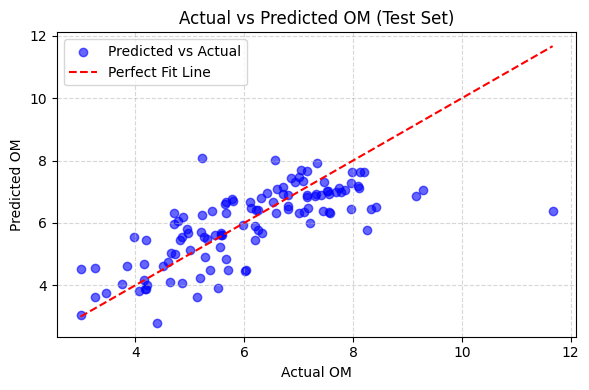

In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_et_model.pkl")
scaler = joblib.load("scaler.et.pkl")
selected_features = joblib.load("selected_features.et.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1','SAND_Polaris', 'Lamda_Polaris' ], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"MBE:  {np.mean(y_pred - y_test):.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - BD_Polaris
 - ncci3all
 - Ksat_Polaris
 - n_Polaris
 - Theta_r_Polaris
 - Theta_s_Polaris
 - Senti_BI_1
 - Standard_Height

📊 Test Set Metrics (ExtraTrees):
MAE:  0.7715
RMSE: 1.0434
R²:   0.5190
MBE:  -0.1420
RPIQ: 2.1325


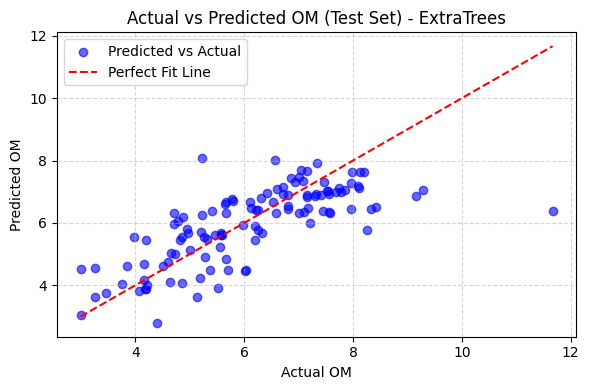

In [ ]:
# === TEST SCRIPT (ExtraTrees with RPIQ) ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_et_model.pkl")
scaler = joblib.load("scaler.et.pkl")
selected_features = joblib.load("selected_features.et.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=[
        'OM', 'SAMPLEDATE', 'lati', 'long',
        'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'
    ],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

# === RPIQ calculation (observed OM distribution) ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (ExtraTrees):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")
print(f"RPIQ: {rpiq:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (Test Set) - ExtraTrees")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Sample metric values (replace with your actual results) ===
models = ['DT', 'ET', 'RF', 'GB', 'XGB', 'BR', 'MLP', 'CNN', 'SR']

rmse = [1250, 1150, 1100, 1130, 1080, 1200, 1300, 1290, 1050]
mae  = [900, 800, 810, 805, 790, 950, 920, 940, 770]
mbe  = [5, 25, 22, 27, 30, 20, 35, 38, 28]
r2   = [0.78, 0.84, 0.82, 0.81, 0.85, 0.79, 0.75, 0.74, 0.88]

# === Simulated error bars (std devs); replace with actual ones ===
rmse_err = [100, 80, 75, 90, 70, 95, 130, 125, 60]
mae_err  = [50, 40, 45, 42, 38, 55, 50, 53, 35]
mbe_err  = [4, 5, 6, 4, 5, 5, 7, 6, 5]
r2_err   = [0.05] * len(models)

# === Plotting ===
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('📊 Performance Metrics Comparison Across Regression Models', fontsize=16)

# — RMSE —
axs[0, 0].bar(models, rmse, color='dodgerblue', yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (kg ha⁻¹)")

# — MAE —
axs[0, 1].bar(models, mae, color='darkorange', yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (kg ha⁻¹)")

# — MBE —
axs[1, 0].bar(models, mbe, color='green', yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (kg ha⁻¹)")

# — R² —
axs[1, 1].bar(models, r2, color='firebrick', yerr=r2_err, capsize=5)
axs[1, 1].set_title("R²")
axs[1, 1].set_ylabel("R² Score")

# === Highlight best model per metric ===
for ax, values, is_higher_better in zip(
    axs.flat, [rmse, mae, mbe, r2], [False, False, False, True]
):
    best_idx = np.argmax(values) if is_higher_better else np.argmin(values)
    ax.bar(models[best_idx], values[best_idx],
           edgecolor='black', linewidth=2.5, fill=False)

# === Final layout adjustments ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Cat', 'ET', 'KNN', 'GB', 'DT', 'XG', 'Ada', 'LGBM', 'BayR', 'Stack', 'KSVM']

# Mean values
rmse = [1.45, 1.51, 1.60, 1.58, 1.65, 1.36, 1.39, 1.3958, 1.6363, 1.5268, 1.636]
mae  = [1.00, 1.11, 1.17, 1.22, 1.21, 0.99, 0.97, 1.0374, 1.2314, 1.1263, 1.178]
mbe  = [-0.01, 0.00, 0.07, 0.01, -0.03, -0.014, -0.121, -0.0187, 0.0047, -0.0550, -0.052]
r2   = [0.62, 0.54, 0.49, 0.51, 0.46, 0.63, 0.618, 0.6134, 0.4673, 0.5374, 0.465]

# Min and Max values for error bars
rmse_min = [0.92, 1.24, 1.29, 1.27, 1.00, 0.99, 1.15, 1.0792, 1.3412, 1.1941, 1.362]
rmse_max = [1.63, 1.78, 1.79, 1.97, 1.89, 1.70, 1.70, 1.6724, 1.8763, 1.8899, 1.94]

mae_min = [0.68, 0.90, 0.96, 1.01, 1.00, 0.75, 0.82, 0.8649, 1.0019, 0.9143, 0.938]
mae_max = [1.18, 1.31, 1.32, 1.49, 1.43, 1.19, 1.19, 1.1996, 1.3659, 1.3458, 1.35]

mbe_min = [-0.37, -0.37, -0.33, -0.31, -0.32, -0.36, -0.52, -0.3972, -0.3711, -0.3604, -0.321]
mbe_max = [0.37, 0.50, 0.57, 0.49, 0.49, 0.42, 0.35, 0.3679, 0.3360, 0.3580, 0.428]

r2_min = [0.49, 0.38, 0.29, 0.32, 0.26, 0.48, 0.47, 0.4983, 0.2455, 0.3626, 0.17]
r2_max = [0.84, 0.70, 0.67, 0.68, 0.63, 0.80, 0.73, 0.7735, 0.6502, 0.7227, 0.63]

# Calculate error bars
rmse_err = [np.abs(np.array(rmse) - np.array(rmse_min)), np.abs(np.array(rmse_max) - np.array(rmse))]
mae_err = [np.abs(np.array(mae) - np.array(mae_min)), np.abs(np.array(mae_max) - np.array(mae))]
mbe_err = [np.abs(np.array(mbe) - np.array(mbe_min)), np.abs(np.array(mbe_max) - np.array(mbe))]
r2_err = [np.abs(np.array(r2) - np.array(r2_min)), np.abs(np.array(r2_max) - np.array(r2))]

# Define best model based on highest R² score
best_model_idx = np.argmax(r2)  # Get index of the best model based on R² score

# Set homogeneous colors for each metric across all models
colors_rmse = ['cornflowerblue'] * len(models)
colors_mae = ['darkorange'] * len(models)
colors_mbe = ['mediumseagreen'] * len(models)
colors_r2 = ['crimson'] * len(models)

# Highlight the best model
colors_rmse[best_model_idx] = 'limegreen'
colors_mae[best_model_idx] = 'limegreen'
colors_mbe[best_model_idx] = 'limegreen'
colors_r2[best_model_idx] = 'limegreen'

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('10-Fold CV Metrics Comparison Across Models', fontsize=16)

# RMSE
axs[0, 0].bar(models, rmse, color=colors_rmse, yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (%)")

# MAE
axs[0, 1].bar(models, mae, color=colors_mae, yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (%)")

# MBE
axs[1, 0].bar(models, mbe, color=colors_mbe, yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (%)")

# R²
axs[1, 1].bar(models, r2, color=colors_r2, yerr=r2_err, capsize=5)
axs[1, 1].set_title("R² Score")
axs[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 📌 Print Best Model Metrics Summary
print("\n📌 Best Model Metrics Summary (10-Fold CV):")
print(f"Best Model: {models[best_model_idx]}")
print(f"MBE:  Mean = {mbe[best_model_idx]:.4f}, Min = {mbe_min[best_model_idx]:.4f}, Max = {mbe_max[best_model_idx]:.4f}")
print(f"MAE:  Mean = {mae[best_model_idx]:.4f}, Min = {mae_min[best_model_idx]:.4f}, Max = {mae_max[best_model_idx]:.4f}")
print(f"RMSE: Mean = {rmse[best_model_idx]:.4f}, Min = {rmse_min[best_model_idx]:.4f}, Max = {rmse_max[best_model_idx]:.4f}")
print(f"R²:   Mean = {r2[best_model_idx]:.4f}, Min = {r2_min[best_model_idx]:.4f}, Max = {r2_max[best_model_idx]:.4f}")


KNN

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base KNN ===
knn_base = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn_base.fit(X_scaled, y)
perm_importance = permutation_importance(knn_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.40 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {


    'n_neighbors': [3 ,5, 4],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=10, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_knn = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_knn.fit(X_t, y_t)
    y_pred = best_knn.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_knn, "best_knn_model.pkl")
joblib.dump(scaler, "scaler.knn.pkl")
joblib.dump(selected_features, "selected_features.knn.pkl")


📌 Selected Features (12 of 30):
 - Senti_BI_1
 - MRVBF
 - Aspect
 - Convexity
 - gNASGO_SC
 - Profile_curva
 - Convergence_Index
 - PH_Polaris
 - Slope
 - MRRTF
 - Tang_curva
 - Alpha_Polaris

✅ Best Hyperparameters:
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1060, MAE: 1.2423, RMSE: 1.7445, R²: 0.5496
Fold 2 → MBE: -0.0414, MAE: 1.6554, RMSE: 2.1625, R²: 0.1045
Fold 3 → MBE: 0.7052, MAE: 1.0450, RMSE: 1.4056, R²: 0.4283
Fold 4 → MBE: -0.1576, MAE: 1.4097, RMSE: 1.9607, R²: 0.2299
Fold 5 → MBE: -0.1572, MAE: 1.2362, RMSE: 1.7026, R²: 0.5476
Fold 6 → MBE: 0.8404, MAE: 1.6183, RMSE: 1.9987, R²: 0.2112
Fold 7 → MBE: 0.3054, MAE: 1.2461, RMSE: 1.5854, R²: 0.4632
Fold 8 → MBE: -0.1357, MAE: 1.2444, RMSE: 1.7769, R²: 0.4919
Fold 9 → MBE: -0.0343, MAE: 1.2745, RMSE: 1.7006, R²: 0.4723
Fold 10 → MBE: -0.0729, MAE: 1.5906, RMSE: 2.1262, R²: 0.3638

📌 Average 10-Fold Metrics:
MBE:  0.1146
MAE:  1.3563
RMSE: 1.8164
R²:   0.3862


['selected_features.knn.pkl']

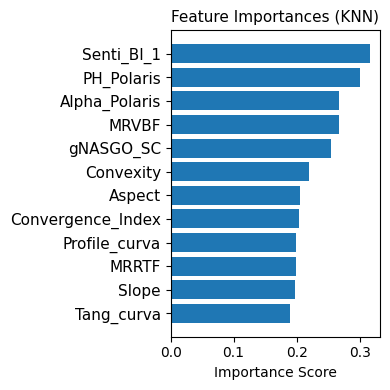

In [ ]:
# === Step 10: Feature Importance Plot (KNN - Permutation) ===
import matplotlib.pyplot as plt
import numpy as np

# Recalculate permutation importance using the best KNN model
perm_importance_knn = permutation_importance(
    best_knn, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42
)

importances = perm_importance_knn.importances_mean
sorted_idx = np.argsort(importances)[::-1]
sorted_features = np.array(selected_features)[sorted_idx]

# Plot
plt.figure(figsize=(4, 4), facecolor='white')
plt.title("Feature Importances (KNN)", fontsize=11)
plt.barh(range(len(sorted_features)), importances[sorted_idx], color='#1f77b4')
plt.yticks(range(len(sorted_features)), sorted_features, fontsize=11)
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
#plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long',
             'SAND_Polaris', 'Lamda_Polaris', 'Planet_BI_1'],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base KNN ===
knn_base = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn_base.fit(X_scaled, y)

perm_importance = permutation_importance(
    knn_base, X_scaled, y,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
)

top_k = int(0.40 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()

print(f"\n📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# ==========================================================
# === RPIQ: Interquartile Range of observed OM (GLOBAL) ===
# ==========================================================
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1

print(f"\nIQR of observed OM: {IQR:.4f}")

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_neighbors': [3, 4, 5],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)

best_knn = grid_search.best_estimator_

print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics (WITH RPIQ) ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_knn.fit(X_t, y_t)
    y_pred = best_knn.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)
    rpiq = IQR / rmse

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {i} → "
        f"MBE: {mbe:.4f}, "
        f"MAE: {mae:.4f}, "
        f"RMSE: {rmse:.4f}, "
        f"R²: {r2:.4f}, "
        f"RPIQ: {rpiq:.4f}"
    )

# === Step 8: Final Average Metrics (WITH RPIQ) ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_knn, "best_knn_model.pkl")
joblib.dump(scaler, "scaler.knn.pkl")
joblib.dump(selected_features, "selected_features.knn.pkl")



📌 Selected Features (11 of 29):
 - Senti_BI_1
 - MRVBF
 - Mid_Slope_Position
 - Convexity
 - Aspect
 - gNASGO_SC
 - Profile_curva
 - PH_Polaris
 - Convergence_Index
 - Slope
 - Alpha_Polaris

IQR of observed OM: 2.7000

✅ Best Hyperparameters:
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.2368, MAE: 1.2877, RMSE: 1.7746, R²: 0.5339, RPIQ: 1.5215
Fold 2 → MBE: -0.1568, MAE: 1.5198, RMSE: 2.0341, R²: 0.2077, RPIQ: 1.3274
Fold 3 → MBE: 0.5481, MAE: 0.8760, RMSE: 1.1532, R²: 0.6152, RPIQ: 2.3412
Fold 4 → MBE: -0.1149, MAE: 1.4032, RMSE: 1.8070, R²: 0.3459, RPIQ: 1.4942
Fold 5 → MBE: -0.2110, MAE: 1.2984, RMSE: 1.7528, R²: 0.5205, RPIQ: 1.5404
Fold 6 → MBE: 0.7874, MAE: 1.4985, RMSE: 1.9076, R²: 0.2814, RPIQ: 1.4154
Fold 7 → MBE: 0.1291, MAE: 1.1444, RMSE: 1.4758, R²: 0.5348, RPIQ: 1.8295
Fold 8 → MBE: 0.0572, MAE: 1.2111, RMSE: 1.6784, R²: 0.5467, RPIQ: 1.6087
Fold 9 → MBE: -0.0116, MAE: 1.2874, RMSE: 1.7059, R²: 0.4690, RPIQ: 1.582

['selected_features.knn.pkl']

TEST KNN

🔍 Features used for prediction:
 - Senti_BI_1
 - MRVBF
 - Mid_Slope_Position
 - Convexity
 - Aspect
 - gNASGO_SC
 - Profile_curva
 - PH_Polaris
 - Convergence_Index
 - Slope
 - Alpha_Polaris

📊 Test Set Metrics:
MAE:  1.0395
RMSE: 1.3923
R²:   0.1435
MBE:  -0.3794


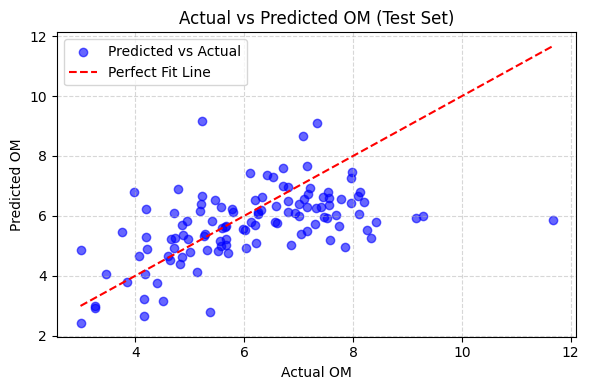

In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_knn_model.pkl")
scaler = joblib.load("scaler.knn.pkl")
selected_features = joblib.load("selected_features.knn.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"MBE:  {np.mean(y_pred - y_test):.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - Senti_BI_1
 - MRVBF
 - Mid_Slope_Position
 - Convexity
 - Aspect
 - gNASGO_SC
 - Profile_curva
 - PH_Polaris
 - Convergence_Index
 - Slope
 - Alpha_Polaris

📊 Test Set Metrics (kNN):
MAE:  1.0395
RMSE: 1.3923
R²:   0.1435
MBE:  -0.3794
RPIQ: 1.5981


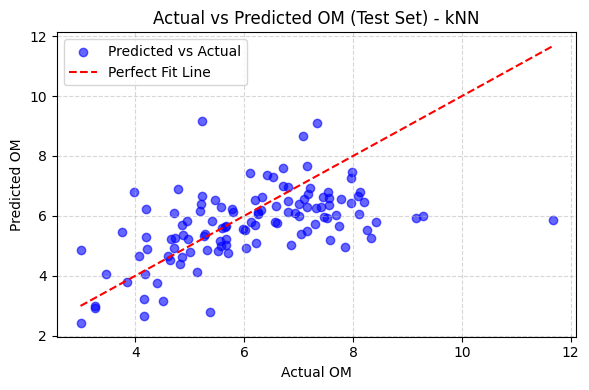

In [ ]:
# === TEST SCRIPT (kNN with RPIQ) ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_knn_model.pkl")
scaler = joblib.load("scaler.knn.pkl")
selected_features = joblib.load("selected_features.knn.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (kNN):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")
print(f"RPIQ: {rpiq:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (Test Set) - kNN")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


GB

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev' ,'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base GB ===
gb_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_base.fit(X_scaled, y)
perm_importance = permutation_importance(gb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_gb = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_gb.fit(X_t, y_t)
    y_pred = best_gb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_gb, "best_gb_model.pkl")
joblib.dump(scaler, "scaler_gb.pkl")
joblib.dump(selected_features, "selected_features_gb.pkl")


📌 Selected Features (12 of 31):
 - Standard_Height
 - gNASGO_SC
 - Clay_polaris
 - MRVBF
 - Senti_BI_1
 - ncci3all
 - n_Polaris
 - TWI
 - Ksat_Polaris
 - SAND_Polaris
 - Lamda_Polaris
 - pctearthmc

✅ Best Hyperparameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 1.0}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1646, MAE: 1.0340, RMSE: 1.4479, R²: 0.6897
Fold 2 → MBE: -0.0973, MAE: 1.2014, RMSE: 1.5887, R²: 0.5166
Fold 3 → MBE: 0.3490, MAE: 0.7537, RMSE: 0.9470, R²: 0.7405
Fold 4 → MBE: 0.0231, MAE: 1.0046, RMSE: 1.3949, R²: 0.6103
Fold 5 → MBE: -0.1628, MAE: 1.1402, RMSE: 1.6759, R²: 0.5616
Fold 6 → MBE: 0.1026, MAE: 0.8854, RMSE: 1.2306, R²: 0.7010
Fold 7 → MBE: 0.1433, MAE: 1.0559, RMSE: 1.4296, R²: 0.5635
Fold 8 → MBE: 0.0453, MAE: 0.9066, RMSE: 1.3892, R²: 0.6895
Fold 9 → MBE: -0.0438, MAE: 0.9437, RMSE: 1.2993, R²: 0.6920
Fold 10 → MBE: -0.2104, MAE: 1.0899, RMSE: 1.6612, R²: 0.6117

📌 Average 10-Fold Metric

['selected_features_gb.pkl']

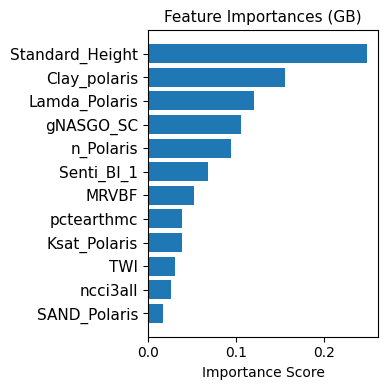

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importances and sort them
importances = best_gb.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
sorted_features = np.array(selected_features)[sorted_idx]

# Plot
plt.figure(figsize=(4, 4), facecolor='white')
plt.title("Feature Importances (GB)", fontsize=11)
plt.barh(range(len(sorted_features)), importances[sorted_idx], color='#1f77b4')
plt.yticks(range(len(sorted_features)), sorted_features, fontsize=11)
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
#plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base GB ===
gb_base = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
gb_base.fit(X_scaled, y)

perm_importance = permutation_importance(
    gb_base,
    X_scaled,
    y,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()

print(f"\n📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# ==========================================================
# === RPIQ: Interquartile Range of observed OM (GLOBAL) ===
# ==========================================================
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1

print(f"\nIQR of observed OM: {IQR:.4f}")

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)

best_gb = grid_search.best_estimator_

print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics (WITH RPIQ) ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_gb.fit(X_t, y_t)
    y_pred = best_gb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)
    rpiq = IQR / rmse

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {i} → "
        f"MBE: {mbe:.4f}, "
        f"MAE: {mae:.4f}, "
        f"RMSE: {rmse:.4f}, "
        f"R²: {r2:.4f}, "
        f"RPIQ: {rpiq:.4f}"
    )

# === Step 8: Final Average Metrics (WITH RPIQ) ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_gb, "best_gb_model.pkl")
joblib.dump(scaler, "scaler_gb.pkl")
joblib.dump(selected_features, "selected_features_gb.pkl")



📌 Selected Features (11 of 29):
 - Standard_Height
 - gNASGO_SC
 - n_Polaris
 - Clay_polaris
 - Senti_BI_1
 - MRVBF
 - ncci3all
 - Mid_Slope_Position
 - TWI
 - SILT_Polaris
 - pctearthmc

IQR of observed OM: 2.7000

✅ Best Hyperparameters:
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1232, MAE: 1.0530, RMSE: 1.4719, R²: 0.6794, RPIQ: 1.8344
Fold 2 → MBE: -0.0984, MAE: 1.1975, RMSE: 1.5791, R²: 0.5225, RPIQ: 1.7099
Fold 3 → MBE: 0.3971, MAE: 0.7145, RMSE: 0.8970, R²: 0.7672, RPIQ: 3.0099
Fold 4 → MBE: 0.1638, MAE: 1.0768, RMSE: 1.4268, R²: 0.5922, RPIQ: 1.8924
Fold 5 → MBE: -0.1282, MAE: 1.1398, RMSE: 1.5725, R²: 0.6141, RPIQ: 1.7170
Fold 6 → MBE: 0.1105, MAE: 0.9049, RMSE: 1.3117, R²: 0.6603, RPIQ: 2.0584
Fold 7 → MBE: 0.0446, MAE: 1.0961, RMSE: 1.5140, R²: 0.5104, RPIQ: 1.7834
Fold 8 → MBE: -0.0754, MAE: 0.8243, RMSE: 1.2578, R²: 0.7454, RPIQ: 2.1466
Fold 9 → MBE: -0

['selected_features_gb.pkl']

TEST

🔍 Features used for prediction:
 - Standard_Height
 - gNASGO_SC
 - Clay_polaris
 - MRVBF
 - Senti_BI_1
 - ncci3all
 - n_Polaris
 - TWI
 - Ksat_Polaris
 - SAND_Polaris
 - Lamda_Polaris
 - pctearthmc

📊 Test Set Metrics (Gradient Boosting):
MAE:  1.0342
RMSE: 1.3623
R²:   0.1801
MBE:  -0.2955


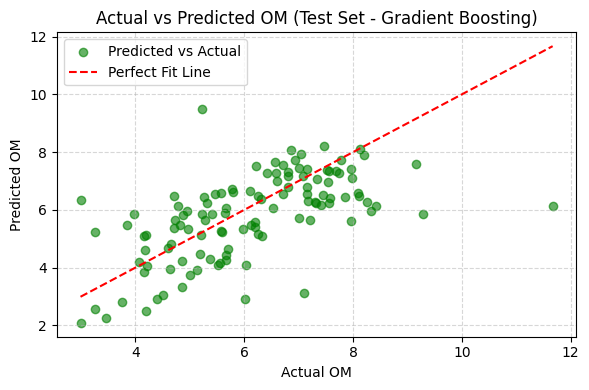

In [ ]:
# === TEST SCRIPT (Gradient Boosting with MBE) ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_gb_model.pkl")         # 👈 GB model file
scaler = joblib.load("/content/scaler_gb.pkl")
selected_features = joblib.load("/content/selected_features_gb.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev','long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)  # Mean Bias Error

print("\n📊 Test Set Metrics (Gradient Boosting):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="green", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Test Set - Gradient Boosting)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


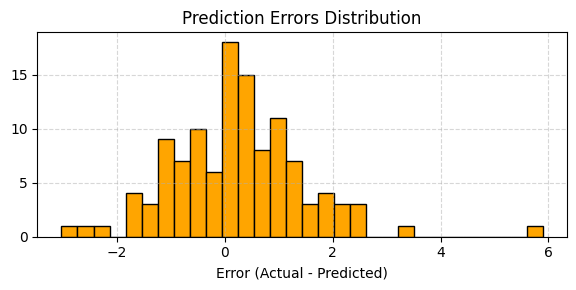

In [ ]:
errors = y_test - y_pred
plt.figure(figsize=(6, 3))
plt.hist(errors, bins=30, color='orange', edgecolor='black')
plt.title("Prediction Errors Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
df_test['Predicted_OM'] = y_pred
df_test[['OM', 'Predicted_OM']].to_csv("gb_test_predictions.csv", index=False)


🔍 Features used for prediction:
 - Standard_Height
 - gNASGO_SC
 - n_Polaris
 - Clay_polaris
 - Senti_BI_1
 - MRVBF
 - ncci3all
 - Mid_Slope_Position
 - TWI
 - SILT_Polaris
 - pctearthmc

📊 Test Set Metrics (Gradient Boosting):
MAE:  0.9130
RMSE: 1.2004
R²:   0.3633
MBE:  -0.1164
RPIQ: 1.8535


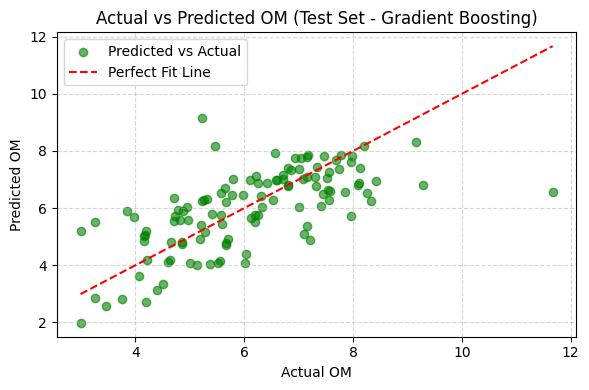

In [ ]:
# === TEST SCRIPT (Gradient Boosting with RPIQ) ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_gb_model.pkl")         # Gradient Boosting model
scaler = joblib.load("/content/scaler_gb.pkl")
selected_features = joblib.load("/content/selected_features_gb.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (Gradient Boosting):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")
print(f"RPIQ: {rpiq:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="green", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (Test Set - Gradient Boosting)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


DT

📌 Selected Features (12 of 31):
 - Standard_Height
 - Clay_polaris
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Slope_Height
 - Mid_Slope_Position
 - PH_Polaris
 - Theta_r_Polaris
 - Convexity
 - ncci3all
 - SAND_Polaris
Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ Best Hyperparameters from GridSearchCV:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.2298, MAE: 1.1054, RMSE: 1.5321, R²: 0.6526
Fold 2 → MBE: -0.0613, MAE: 1.2849, RMSE: 1.6906, R²: 0.4526
Fold 3 → MBE: 0.2428, MAE: 0.6169, RMSE: 0.8272, R²: 0.8020
Fold 4 → MBE: 0.0402, MAE: 1.3129, RMSE: 1.7011, R²: 0.4203
Fold 5 → MBE: -0.1035, MAE: 1.2234, RMSE: 1.6636, R²: 0.5680
Fold 6 → MBE: 0.0255, MAE: 0.9107, RMSE: 1.3008, R²: 0.6659
Fold 7 → MBE: -0.0151, MAE: 1.3256, RMSE: 1.6764, R²: 0.3997
Fold 8 → MBE: 0.1039, MAE: 1.1023, RMSE: 1.6370, R²: 0.5688
Fold 9 → MBE: -0.1628, MAE: 0.9354, RMSE: 1.4751, R²: 0.6030
Fold 10 → MBE: -0.0814, MAE: 1.2015, RMSE: 1.5536,

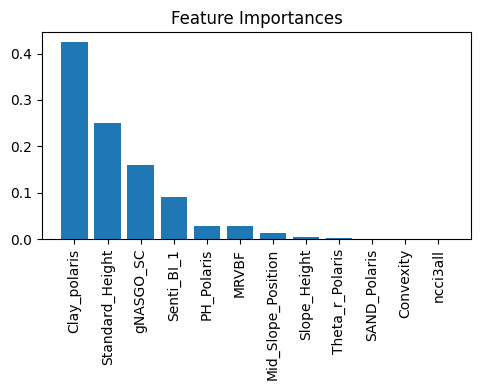

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base DT ===
dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_scaled, y)
perm_importance = permutation_importance(dt_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.40 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_dt = grid_search.best_estimator_

# ✅ Print Best Hyperparameters
print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_dt.fit(X_t, y_t)
    y_pred = best_dt.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Final Average Metrics ===
print("\n📌 Average 10-Fold Train Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save model artifacts ===
joblib.dump(best_dt, "best_dt_model.pkl")
joblib.dump(scaler, "scaler_dt.pkl")
joblib.dump(list(selected_features), "selected_features_dt.pkl")

# === Step 9: Feature Importance Plot ===
importances = best_dt.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(5, 4))
plt.title("Feature Importances")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.show()

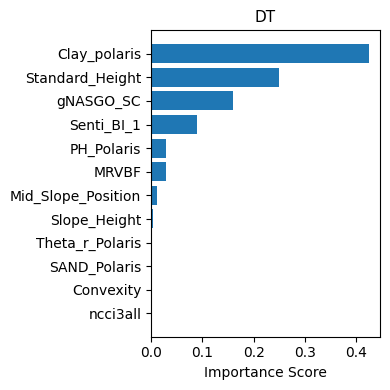

In [ ]:
# === Step 9: Feature Importance Plot (Horizontal) ===
importances = best_dt.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(4, 4), facecolor='white')
plt.title("DT", fontsize=11)
plt.barh(range(len(selected_features)), importances[sorted_idx], color='#1f77b4')
plt.yticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], fontsize=10)
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # Show most important feature at the top
# plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()



📌 Selected Features (11 of 29):
 - Clay_polaris
 - Standard_Height
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Mid_Slope_Position
 - PH_Polaris
 - Theta_r_Polaris
 - Ksat_Polaris
 - Convexity
 - ncci3all

IQR of observed OM: 2.7000
Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ Best Hyperparameters from GridSearchCV:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.2447, MAE: 1.0965, RMSE: 1.5340, R²: 0.6518, RPIQ: 1.7602
Fold 2 → MBE: -0.0613, MAE: 1.2849, RMSE: 1.6906, R²: 0.4526, RPIQ: 1.5970
Fold 3 → MBE: 0.2417, MAE: 0.6229, RMSE: 0.8337, R²: 0.7989, RPIQ: 3.2384
Fold 4 → MBE: 0.0405, MAE: 1.3192, RMSE: 1.7040, R²: 0.4184, RPIQ: 1.5845
Fold 5 → MBE: -0.0766, MAE: 1.2294, RMSE: 1.6697, R²: 0.5649, RPIQ: 1.6171
Fold 6 → MBE: 0.0202, MAE: 0.9037, RMSE: 1.2933, R²: 0.6697, RPIQ: 2.0876
Fold 7 → MBE: -0.0151, MAE: 1.3256, RMSE: 1.6764, R²: 0.3997, RPIQ: 1.6106
Fold 8 → MBE: 0.1039, MAE: 1.1023, RMSE: 1.6370, R²: 0.5688,

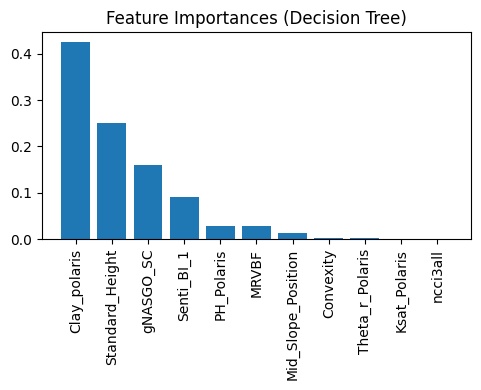

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base DT ===
dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_scaled, y)

perm_importance = permutation_importance(
    dt_base,
    X_scaled,
    y,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
)

top_k = int(0.40 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()

print(f"\n📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# ==========================================================
# === RPIQ: Interquartile Range of observed OM (GLOBAL) ===
# ==========================================================
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1

print(f"\nIQR of observed OM: {IQR:.4f}")

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)

best_dt = grid_search.best_estimator_

# ✅ Print Best Hyperparameters
print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics (WITH RPIQ) ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_dt.fit(X_t, y_t)
    y_pred = best_dt.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)
    rpiq = IQR / rmse

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {i} → "
        f"MBE: {mbe:.4f}, "
        f"MAE: {mae:.4f}, "
        f"RMSE: {rmse:.4f}, "
        f"R²: {r2:.4f}, "
        f"RPIQ: {rpiq:.4f}"
    )

# === Final Average Metrics (WITH RPIQ) ===
print("\n📌 Average 10-Fold Train Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 8: Save model artifacts ===
joblib.dump(best_dt, "best_dt_model.pkl")
joblib.dump(scaler, "scaler_dt.pkl")
joblib.dump(list(selected_features), "selected_features_dt.pkl")

# === Step 9: Feature Importance Plot ===
importances = best_dt.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(5, 4))
plt.title("Feature Importances (Decision Tree)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(
    range(len(selected_features)),
    np.array(selected_features)[sorted_idx],
    rotation=90
)
plt.tight_layout()
plt.show()


TEST DT

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load Test Data ===
test_df = pd.read_csv("/content/Antho_Test_,11,21_field.csv")

# === Step 2: Load Saved Artifacts ===
model = joblib.load("best_dt_model.pkl")
scaler = joblib.load("scaler_dt.pkl")
selected_features = joblib.load("selected_features_dt.pkl")

# === Step 3: Clean and Prepare Test Data ===
test_df = test_df[test_df['OM'] <= 12].dropna(subset=['OM'])
X_test_raw = test_df[selected_features].copy()
y_test = test_df['OM']

# Drop rows with NaNs in selected features
X_test_raw = X_test_raw.dropna()
y_test = y_test.loc[X_test_raw.index]

# === Step 4: Scale the Selected Features ===
X_test_scaled = scaler.transform(X_test_raw)

# === Step 5: Predict and Evaluate ===
y_pred = model.predict(X_test_scaled)

mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# === Step 6: Print Final Test Metrics ===
print("\n✅ Test Set Metrics (Decision Tree):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")



✅ Test Set Metrics (Decision Tree):
MAE:  1.0496
RMSE: 1.4012
R²:   0.0757
MBE:  0.1098


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load Test Data ===
test_df = pd.read_csv("/content/Antho_Test_,11,21_field.csv")

# === Step 2: Load Saved Artifacts ===
model = joblib.load("best_dt_model.pkl")
scaler = joblib.load("scaler_dt.pkl")
selected_features = joblib.load("selected_features_dt.pkl")

# === Step 3: Clean and Prepare Test Data ===
test_df = test_df[test_df['OM'] <= 12].dropna(subset=['OM'])
X_test_raw = test_df[selected_features].copy()
y_test = test_df['OM']

# Drop rows with NaNs in selected features
X_test_raw = X_test_raw.dropna()
y_test = y_test.loc[X_test_raw.index]

# === Step 4: Scale the Selected Features ===
X_test_scaled = scaler.transform(X_test_raw)

# === Step 5: Predict and Evaluate ===
y_pred = model.predict(X_test_scaled)

mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Step 6: Print Final Test Metrics ===
print("\n✅ Test Set Metrics (Decision Tree):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")
print(f"RPIQ: {rpiq:.4f}")



✅ Test Set Metrics (Decision Tree):
MAE:  1.0496
RMSE: 1.4012
R²:   0.0757
MBE:  0.1098
RPIQ: 1.4844


XGBOOST

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long','Standarized_Height', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Handle non-numeric values in X ===
# Convert all columns to numeric, coercing errors to NaN
X = X.apply(pd.to_numeric, errors='coerce')
# Drop rows with any NaN values introduced by coercion
X = X.dropna()
# Align y with the cleaned X
y = y.loc[X.index]


# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base XGBoost ===
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_base.fit(X_scaled, y)
perm_importance = permutation_importance(xgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.40 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_xgb = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_xgb.fit(X_t, y_t)
    y_pred = best_xgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler, "scaler_xgb.pkl")
joblib.dump(selected_features, "selected_features_xgb.pkl")

📌 Selected Features (12 of 32):
 - Standard_Height
 - Senti_BI_1
 - gNASGO_SC
 - Lamda_Polaris
 - Ksat_Polaris
 - MRVBF
 - Relative_Elev
 - ncci3all
 - Clay_polaris
 - n_Polaris
 - TWI
 - PH_Polaris

✅ Best Hyperparameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 1.0}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.3202, MAE: 1.0274, RMSE: 1.4584, R²: 0.6852
Fold 2 → MBE: -0.1267, MAE: 1.2491, RMSE: 1.7439, R²: 0.4176
Fold 3 → MBE: 0.4803, MAE: 0.7951, RMSE: 1.0878, R²: 0.6576
Fold 4 → MBE: -0.0049, MAE: 1.0026, RMSE: 1.4143, R²: 0.5993
Fold 5 → MBE: -0.2382, MAE: 1.0220, RMSE: 1.5377, R²: 0.6309
Fold 6 → MBE: 0.2429, MAE: 0.8907, RMSE: 1.1883, R²: 0.7212
Fold 7 → MBE: 0.0730, MAE: 1.1456, RMSE: 1.4898, R²: 0.5260
Fold 8 → MBE: -0.1251, MAE: 0.8486, RMSE: 1.2510, R²: 0.7482
Fold 9 → MBE: -0.1160, MAE: 1.1093, RMSE: 1.6327, R²: 0.5136
Fold 10 → MBE: -0.2928, MAE: 0.9835, RMSE: 1.5003, R²: 0.6833

📌 Average 10-Fold 

['selected_features_xgb.pkl']

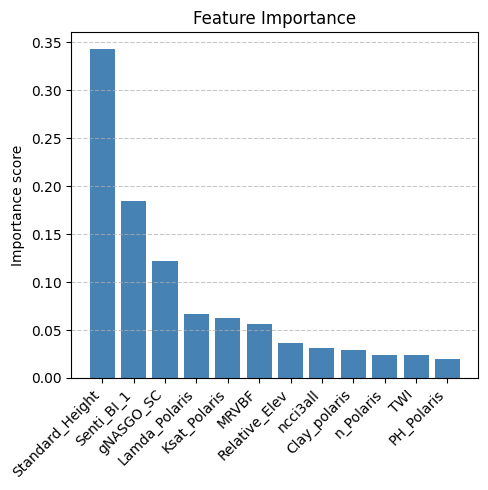

In [ ]:
# === Step 10: Plot Feature Importance ===
importance_df = importance_df[importance_df['Feature'].isin(selected_features)]
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Normalized', ascending=False)

plt.figure(figsize=(5, 5))
plt.bar(importance_df['Feature'], importance_df['Normalized'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Importance score")
plt.title("Feature Importance")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


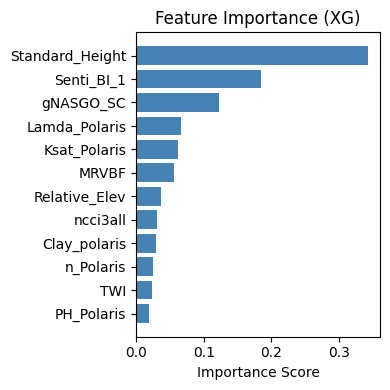

In [ ]:
# === Step 10: Plot Feature Importance (Horizontal) ===
importance_df = importance_df[importance_df['Feature'].isin(selected_features)]
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Normalized', ascending=False)

plt.figure(figsize=(4, 4), facecolor='white')
plt.barh(importance_df['Feature'], importance_df['Normalized'], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Feature Importance (XG)")
plt.gca().invert_yaxis()  # Most important feature on top
# plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



📈 Evaluating performance vs number of features:
1 features → Avg R²: 0.4084
2 features → Avg R²: 0.4585
3 features → Avg R²: 0.5637
4 features → Avg R²: 0.5883
5 features → Avg R²: 0.6120
6 features → Avg R²: 0.6019
7 features → Avg R²: 0.6099
8 features → Avg R²: 0.6040
9 features → Avg R²: 0.6051
10 features → Avg R²: 0.6203
11 features → Avg R²: 0.6227
12 features → Avg R²: 0.6183


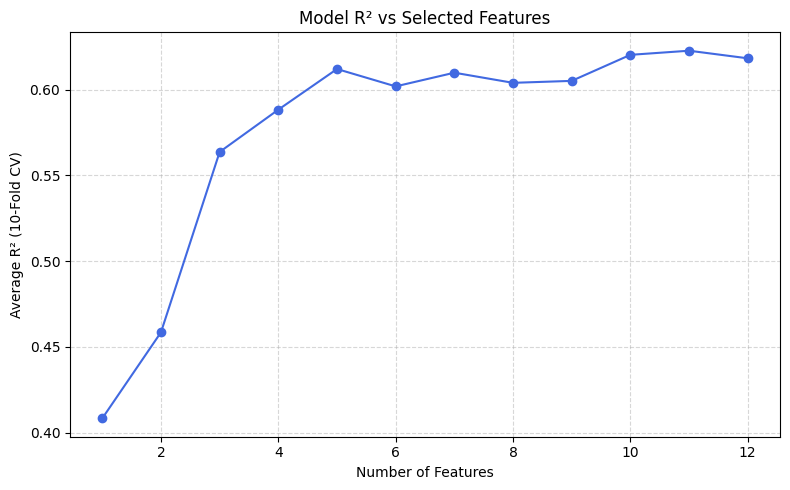

In [ ]:
# === Step 11: Model Performance vs. Number of Selected Features ===
r2_scores = []
feature_counts = []

print("\n📈 Evaluating performance vs number of features:")
for k in range(1, len(importance_df) + 1):
    top_k_features = importance_df['Feature'].iloc[:k].tolist()
    X_k = X[top_k_features].fillna(0)

    # Scale
    X_k_scaled = scaler.fit_transform(X_k)

    # 10-fold CV for each k
    r2_list = []
    for train_idx, val_idx in kf.split(X_k_scaled):
        X_t, X_v = X_k_scaled[train_idx], X_k_scaled[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

        best_xgb.fit(X_t, y_t)
        y_pred = best_xgb.predict(X_v)
        r2 = r2_score(y_v, y_pred)
        r2_list.append(r2)

    avg_r2 = np.mean(r2_list)
    r2_scores.append(avg_r2)
    feature_counts.append(k)
    print(f"{k} features → Avg R²: {avg_r2:.4f}")

# === Plot: R² vs Feature Count ===
plt.figure(figsize=(8, 5))
plt.plot(feature_counts, r2_scores, marker='o', linestyle='-', color='royalblue')
plt.title("Model R² vs Selected Features")
plt.xlabel("Number of Features")
plt.ylabel("Average R² (10-Fold CV)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import shap

# === Step 10: SHAP Beeswarm Plot for Selected Features ===

# Load model and selected features
model = joblib.load("best_xgb_model.pkl")
selected_features = joblib.load("selected_features_xgb.pkl")

# Prepare original unscaled selected features DataFrame
X_selected_df = X[selected_features]

# Fit the model again on full data (unscaled) to match SHAP expectations
model.fit(X_selected_df, y)

# Create SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_selected_df)

# Plot SHAP summary (beeswarm)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP Beeswarm Plot: Feature Impact on OM Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm_selected_features.png", dpi=300, bbox_inches='tight')
plt.show()


https://planetarycomputer.microsoft.com/dataset/gnatsgo-rasters

10% features → R²: 0.5517
20% features → R²: 0.6258
30% features → R²: 0.6218
40% features → R²: 0.6512
50% features → R²: 0.6483
60% features → R²: 0.6350
70% features → R²: 0.6323
80% features → R²: 0.6298
90% features → R²: 0.6217
100% features → R²: 0.6295


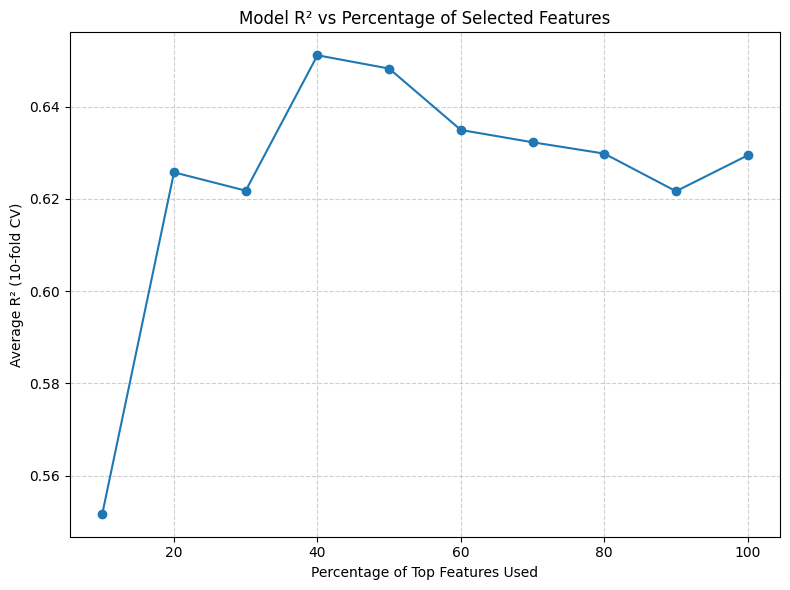

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

# === Step 1: Load & Filter Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long','Relative_Elev', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns.tolist()

# === Step 3: Fit Base Model & Get Permutation Importances ===
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=0)
xgb.fit(X_scaled, y)
perm = permutation_importance(xgb, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)
sorted_indices = np.argsort(perm.importances_mean)[::-1]

# === Step 4: Evaluate R² vs % of Selected Features ===
percentages = list(range(10, 101, 10))
r2_scores = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for pct in percentages:
    k = int(len(feature_names) * pct / 100)
    top_k_indices = sorted_indices[:k]
    top_k_features = [feature_names[i] for i in top_k_indices]
    X_k = X[top_k_features]
    X_k_scaled = scaler.fit_transform(X_k)

    fold_r2 = []
    for train_idx, val_idx in kf.split(X_k_scaled):
        X_train, X_val = X_k_scaled[train_idx], X_k_scaled[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        fold_r2.append(r2_score(y_val, preds))

    avg_r2 = np.mean(fold_r2)
    r2_scores.append(avg_r2)
    print(f"{pct}% features → R²: {avg_r2:.4f}")

# === Step 5: Plot ===
plt.figure(figsize=(8, 6))
plt.plot(percentages, r2_scores, marker='o')
plt.title("Model R² vs Percentage of Selected Features")
plt.xlabel("Percentage of Top Features Used")
plt.ylabel("Average R² (10-fold CV)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("r2_vs_percent_selected_features.png", dpi=300)
plt.show()


BEST_XGBOOST


🔍 Fold-wise Metrics:
Fold  1: R²=0.657, MAE=1.177, RMSE=1.523, MBE=-0.224
Fold  2: R²=0.452, MAE=1.317, RMSE=1.692, MBE=-0.041
Fold  3: R²=0.745, MAE=0.749, RMSE=0.938, MBE=0.460
Fold  4: R²=0.578, MAE=1.058, RMSE=1.451, MBE=0.057
Fold  5: R²=0.581, MAE=1.166, RMSE=1.638, MBE=-0.117
Fold  6: R²=0.751, MAE=0.840, RMSE=1.122, MBE=0.203
Fold  7: R²=0.612, MAE=1.034, RMSE=1.347, MBE=-0.018
Fold  8: R²=0.751, MAE=0.885, RMSE=1.244, MBE=0.003
Fold  9: R²=0.739, MAE=0.853, RMSE=1.196, MBE=-0.071
Fold 10: R²=0.645, MAE=1.080, RMSE=1.589, MBE=-0.220

📌 Metrics Using Top 40% Features:
R²:   0.651
MAE:  1.016
RMSE: 1.374
MBE:  0.003
Selected Features (12):
 - Standard_Height
 - gNASGO_SC
 - Senti_BI_1
 - Lamda_Polaris
 - MRVBF
 - Ksat_Polaris
 - Clay_polaris
 - ncci3all
 - PH_Polaris
 - pctearthmc
 - Polaris_SC
 - Theta_s_Polaris

✅ Model, scaler, and feature list saved successfully.


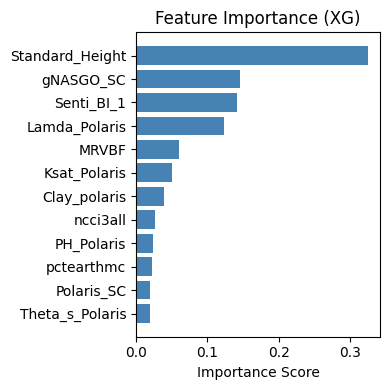

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# === Step 1: Load & Filter Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Relative_Elev', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]
feature_names = X.columns.tolist()

# === Step 2: Scale All Features ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Fit Base Model & Get Permutation Importances ===
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=0)
xgb_base.fit(X_scaled, y)
perm = permutation_importance(xgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# Sort importances
sorted_indices = np.argsort(perm.importances_mean)[::-1]
importances = perm.importances_mean
feature_names = np.array(feature_names)

# === Step 4: Select Top 40% Features ===
top_k = int(len(feature_names) * 0.4)
top_k_indices = sorted_indices[:top_k]
top_k_features = feature_names[top_k_indices]

# === Step 5: Cross-Validation Metrics Using Top 40% Features ===
X_k = X[top_k_features]
X_k_scaled = StandardScaler().fit_transform(X_k)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_r2, fold_mae, fold_rmse, fold_mbe = [], [], [], []

print("\n🔍 Fold-wise Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_k_scaled), start=1):
    X_train, X_val = X_k_scaled[train_idx], X_k_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    r2 = r2_score(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mbe = np.mean(preds - y_val)

    fold_r2.append(r2)
    fold_mae.append(mae)
    fold_rmse.append(rmse)
    fold_mbe.append(mbe)

    print(f"Fold {i:2d}: R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}, MBE={mbe:.3f}")

# === Step 6: Print Final Metrics ===
print("\n📌 Metrics Using Top 40% Features:")
print(f"R²:   {np.mean(fold_r2):.3f}")
print(f"MAE:  {np.mean(fold_mae):.3f}")
print(f"RMSE: {np.mean(fold_rmse):.3f}")
print(f"MBE:  {np.mean(fold_mbe):.3f}")
print(f"Selected Features ({len(top_k_features)}):")
for feat in top_k_features:
    print(f" - {feat}")

# === Step 7: Retrain Final Model & Save Artifacts ===
X_best = X[top_k_features]
scaler_best = StandardScaler()
X_best_scaled = scaler_best.fit_transform(X_best)

best_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
best_xgb.fit(X_best_scaled, y)

joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler_best, "scaler_xgb.pkl")
joblib.dump(top_k_features.tolist(), "selected_features_xgb.pkl")

print("\n✅ Model, scaler, and feature list saved successfully.")

# === Step 10: Plot Feature Importance (Horizontal) ===
importance_df = pd.DataFrame({
    'Feature': feature_names[top_k_indices],
    'Importance': importances[top_k_indices]
})
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Normalized', ascending=False)

plt.figure(figsize=(4, 4), facecolor='white')
plt.barh(importance_df['Feature'], importance_df['Normalized'], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Feature Importance (XG)")
plt.gca().invert_yaxis()  # Most important feature on top
plt.tight_layout()
plt.show()



🔍 Fold-wise Metrics:
Fold  1: R²=0.674, MAE=1.081, RMSE=1.485, MBE=-0.385, RPIQ=1.82
Fold  2: R²=0.463, MAE=1.306, RMSE=1.674, MBE=-0.098, RPIQ=1.61
Fold  3: R²=0.781, MAE=0.679, RMSE=0.869, MBE=0.351, RPIQ=3.11
Fold  4: R²=0.575, MAE=1.070, RMSE=1.457, MBE=0.109, RPIQ=1.85
Fold  5: R²=0.620, MAE=1.102, RMSE=1.561, MBE=-0.213, RPIQ=1.73
Fold  6: R²=0.749, MAE=0.844, RMSE=1.127, MBE=0.055, RPIQ=2.40
Fold  7: R²=0.569, MAE=1.059, RMSE=1.421, MBE=0.108, RPIQ=1.90
Fold  8: R²=0.727, MAE=0.893, RMSE=1.301, MBE=0.015, RPIQ=2.07
Fold  9: R²=0.716, MAE=0.917, RMSE=1.248, MBE=-0.084, RPIQ=2.16
Fold 10: R²=0.629, MAE=1.114, RMSE=1.624, MBE=-0.175, RPIQ=1.66

📌 Metrics Using Top 40% Features:
R²:   0.650
MAE:  1.006
RMSE: 1.377
MBE:  -0.032
RPIQ: 2.03
Selected Features (11):
 - Standard_Height
 - n_Polaris
 - Senti_BI_1
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - Ksat_Polaris
 - PH_Polaris
 - pctearthmc
 - ncci3all
 - Polaris_SC

✅ Model, scaler, and feature list saved successfully.


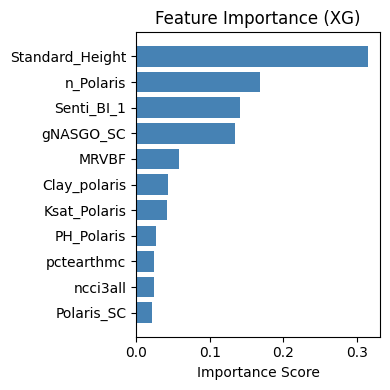

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# === Step 1: Load & Filter Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Relative_Elev', 'Planet_BI_1','Lamda_Polaris','SAND_Polaris'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]
feature_names = X.columns.tolist()

# === Step 2: Scale All Features ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Fit Base Model & Get Permutation Importances ===
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=0)
xgb_base.fit(X_scaled, y)
perm = permutation_importance(xgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# Sort importances
sorted_indices = np.argsort(perm.importances_mean)[::-1]
importances = perm.importances_mean
feature_names = np.array(feature_names)

# === Step 4: Select Top 40% Features ===
top_k = int(len(feature_names) * 0.4)
top_k_indices = sorted_indices[:top_k]
top_k_features = feature_names[top_k_indices]

# === Step 5: Cross-Validation Metrics Using Top 40% Features ===
X_k = X[top_k_features]
X_k_scaled = StandardScaler().fit_transform(X_k)

# Calculate IQR for RPIQ
q75, q25 = np.percentile(y, [75, 25])
iqr_y = q75 - q25

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_r2, fold_mae, fold_rmse, fold_mbe, fold_rpiq = [], [], [], [], []

print("\n🔍 Fold-wise Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_k_scaled), start=1):
    X_train, X_val = X_k_scaled[train_idx], X_k_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    r2 = r2_score(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mbe = np.mean(preds - y_val)
    rpiq = iqr_y / rmse  # Compute RPIQ

    fold_r2.append(r2)
    fold_mae.append(mae)
    fold_rmse.append(rmse)
    fold_mbe.append(mbe)
    fold_rpiq.append(rpiq)

    print(f"Fold {i:2d}: R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}, MBE={mbe:.3f}, RPIQ={rpiq:.2f}")

# === Step 6: Print Final Metrics ===
print("\n📌 Metrics Using Top 40% Features:")
print(f"R²:   {np.mean(fold_r2):.3f}")
print(f"MAE:  {np.mean(fold_mae):.3f}")
print(f"RMSE: {np.mean(fold_rmse):.3f}")
print(f"MBE:  {np.mean(fold_mbe):.3f}")
print(f"RPIQ: {np.mean(fold_rpiq):.2f}")  # Average RPIQ
print(f"Selected Features ({len(top_k_features)}):")
for feat in top_k_features:
    print(f" - {feat}")

# === Step 7: Retrain Final Model & Save Artifacts ===
X_best = X[top_k_features]
scaler_best = StandardScaler()
X_best_scaled = scaler_best.fit_transform(X_best)

best_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
best_xgb.fit(X_best_scaled, y)

joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler_best, "scaler_xgb.pkl")
joblib.dump(top_k_features.tolist(), "selected_features_xgb.pkl")

print("\n✅ Model, scaler, and feature list saved successfully.")

# === Step 8: Plot Feature Importance (Horizontal) ===
importance_df = pd.DataFrame({
    'Feature': feature_names[top_k_indices],
    'Importance': importances[top_k_indices]
})
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Normalized', ascending=False)

plt.figure(figsize=(4, 4), facecolor='white')
plt.barh(importance_df['Feature'], importance_df['Normalized'], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Feature Importance (XG)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


more hyperparameter

TEST_XGBOOST

🔍 Features used for prediction:
 - Standard_Height
 - gNASGO_SC
 - Senti_BI_1
 - Lamda_Polaris
 - MRVBF
 - Ksat_Polaris
 - Clay_polaris
 - ncci3all
 - PH_Polaris
 - pctearthmc
 - Polaris_SC
 - Theta_s_Polaris

📊 Test Set Metrics (XGBoost):
MAE:  1.011
RMSE: 1.293
R²:   0.261
MBE:  0.216


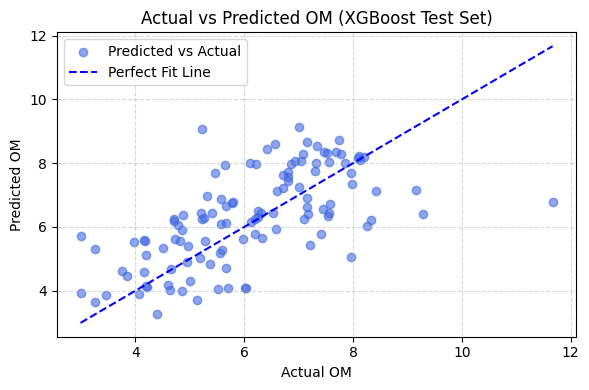

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for XGBoost ===
model = joblib.load("best_xgb_model.pkl")       # ✅ XGBoost model
scaler = joblib.load("scaler_xgb.pkl")          # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati' ,'Relative_Elev','long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)  # ⬅️ MBE

print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")
print(f"MBE:  {mbe:.3f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - Standard_Height
 - n_Polaris
 - Senti_BI_1
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - Ksat_Polaris
 - PH_Polaris
 - pctearthmc
 - ncci3all
 - Polaris_SC

📊 Test Set Metrics (XGBoost):
MAE:  0.975
RMSE: 1.305
R²:   0.247
MBE:  0.075
RPIQ: 1.704


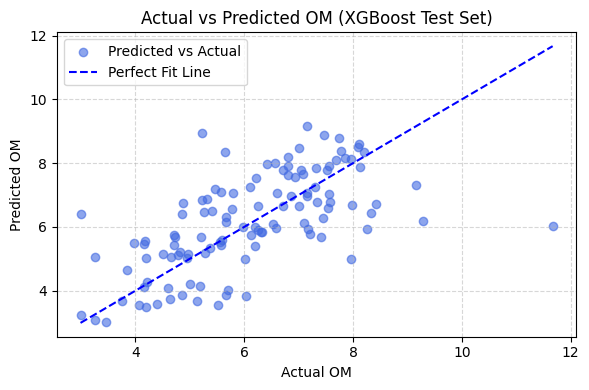

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for XGBoost ===
model = joblib.load("best_xgb_model.pkl")       # XGBoost model
scaler = joblib.load("scaler_xgb.pkl")          # Scaler for selected features
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")
print(f"MBE:  {mbe:.3f}")
print(f"RPIQ: {rpiq:.3f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'b--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Ada

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev','long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base AdaBoost ===
base_est = DecisionTreeRegressor(max_depth=3)
ada_base = AdaBoostRegressor(estimator=base_est, n_estimators=100, learning_rate=0.1, random_state=42)
ada_base.fit(X_scaled, y)
perm_importance = permutation_importance(ada_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.30 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 5, 10]
}
grid_search = GridSearchCV(
    AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_ada = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_ada.fit(X_t, y_t)
    y_pred = best_ada.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_ada, "best_ada_model.pkl")
joblib.dump(scaler, "scaler_ada.pkl")
joblib.dump(selected_features, "selected_features_ada.pkl")


📌 Selected Features (9 of 31):
 - Standard_Height
 - Theta_r_Polaris
 - Senti_BI_1
 - gNASGO_SC
 - Ksat_Polaris
 - MRVBF
 - PH_Polaris
 - ncci3all
 - SAND_Polaris

✅ Best Hyperparameters:
{'estimator__max_depth': 10, 'learning_rate': 0.05, 'n_estimators': 50}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.4006, MAE: 1.0539, RMSE: 1.5791, R²: 0.6310
Fold 2 → MBE: -0.2586, MAE: 1.2141, RMSE: 1.6461, R²: 0.4811
Fold 3 → MBE: 0.2794, MAE: 0.6288, RMSE: 0.8252, R²: 0.8030
Fold 4 → MBE: -0.0901, MAE: 1.0947, RMSE: 1.5158, R²: 0.5398
Fold 5 → MBE: -0.1584, MAE: 1.0887, RMSE: 1.6554, R²: 0.5723
Fold 6 → MBE: 0.1119, MAE: 0.8979, RMSE: 1.3065, R²: 0.6629
Fold 7 → MBE: -0.0953, MAE: 0.9787, RMSE: 1.3470, R²: 0.6125
Fold 8 → MBE: -0.1616, MAE: 0.9954, RMSE: 1.5285, R²: 0.6241
Fold 9 → MBE: -0.2280, MAE: 0.9065, RMSE: 1.3731, R²: 0.6560
Fold 10 → MBE: -0.3181, MAE: 1.0356, RMSE: 1.5910, R²: 0.6438

📌 Average 10-Fold Metrics:
MBE:  -0.1319
MAE:  0.9894
RMSE: 1.4368
R²:   0.6226


['selected_features_ada.pkl']

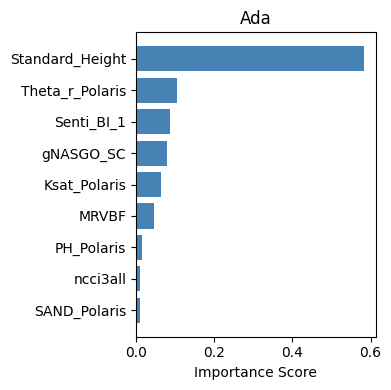

In [ ]:
# === Step 10: Plot Feature Importance (Horizontal) ===
importance_df = importance_df[importance_df['Feature'].isin(selected_features)]
importance_df['Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Normalized', ascending=False)

plt.figure(figsize=(4, 4), facecolor='white')
plt.barh(importance_df['Feature'], importance_df['Normalized'], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Ada")
plt.gca().invert_yaxis()  # Most important feature on top
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev','long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base AdaBoost ===
base_est = DecisionTreeRegressor(max_depth=3)
ada_base = AdaBoostRegressor(estimator=base_est, n_estimators=100, learning_rate=0.1, random_state=42)
ada_base.fit(X_scaled, y)
perm_importance = permutation_importance(ada_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 30% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.30 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 5, 10]
}
grid_search = GridSearchCV(
    AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_ada = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics + RPIQ ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': [], 'rpiq': []}

# IQR of observed y for RPIQ
q75, q25 = np.percentile(y, [75, 25])
iqr_y = q75 - q25

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_ada.fit(X_t, y_t)
    y_pred = best_ada.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)
    rpiq = iqr_y / rmse

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}, RPIQ: {rpiq:.2f}")

# === Step 8: Final Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.2f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_ada, "best_ada_model.pkl")
joblib.dump(scaler, "scaler_ada.pkl")
joblib.dump(selected_features, "selected_features_ada.pkl")
print("\n✅ Model, scaler, and feature list saved successfully.")


📌 Selected Features (8 of 29):
 - Standard_Height
 - Theta_r_Polaris
 - Ksat_Polaris
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Clay_polaris
 - PH_Polaris

✅ Best Hyperparameters:
{'estimator__max_depth': 5, 'learning_rate': 0.2, 'n_estimators': 50}

📊 Per Fold Metrics:
Fold 1 → MBE: -0.1482, MAE: 1.0389, RMSE: 1.4445, R²: 0.6912, RPIQ: 1.87
Fold 2 → MBE: 0.0075, MAE: 1.3109, RMSE: 1.6301, R²: 0.4911, RPIQ: 1.66
Fold 3 → MBE: 0.5978, MAE: 0.9025, RMSE: 1.1653, R²: 0.6071, RPIQ: 2.32
Fold 4 → MBE: 0.2287, MAE: 1.2089, RMSE: 1.5903, R²: 0.4934, RPIQ: 1.70
Fold 5 → MBE: -0.0192, MAE: 1.1948, RMSE: 1.5780, R²: 0.6114, RPIQ: 1.71
Fold 6 → MBE: 0.3228, MAE: 1.0427, RMSE: 1.3355, R²: 0.6478, RPIQ: 2.02
Fold 7 → MBE: 0.0883, MAE: 1.1414, RMSE: 1.3966, R²: 0.5834, RPIQ: 1.93
Fold 8 → MBE: 0.1528, MAE: 0.9771, RMSE: 1.3213, R²: 0.7191, RPIQ: 2.04
Fold 9 → MBE: 0.0422, MAE: 0.9848, RMSE: 1.4606, R²: 0.6107, RPIQ: 1.85
Fold 10 → MBE: 0.0050, MAE: 1.1439, RMSE: 1.6077, R²: 0.6363, RPIQ: 1.68

📌 Average

ADA_TEST

🔍 Features used for prediction:
 - Standard_Height
 - Theta_r_Polaris
 - Senti_BI_1
 - gNASGO_SC
 - Ksat_Polaris
 - MRVBF
 - PH_Polaris
 - ncci3all
 - SAND_Polaris

📊 Test Set Metrics (AdaBoost):
MBE:  -0.1381
MAE:  0.7961
RMSE: 1.1381
R²:   0.4278


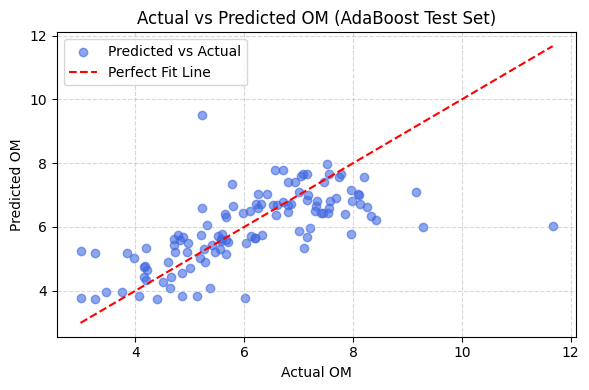

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for AdaBoost ===
model = joblib.load("best_ada_model.pkl")        # ✅ AdaBoost model
scaler = joblib.load("scaler_ada.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_ada.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print metrics
print("\n📊 Test Set Metrics (AdaBoost):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (AdaBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - Standard_Height
 - Theta_r_Polaris
 - Ksat_Polaris
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Clay_polaris
 - PH_Polaris

📊 Test Set Metrics (AdaBoost):
MBE:  0.4281
MAE:  0.9266
RMSE: 1.1912
R²:   0.3730
RPIQ: 1.8678


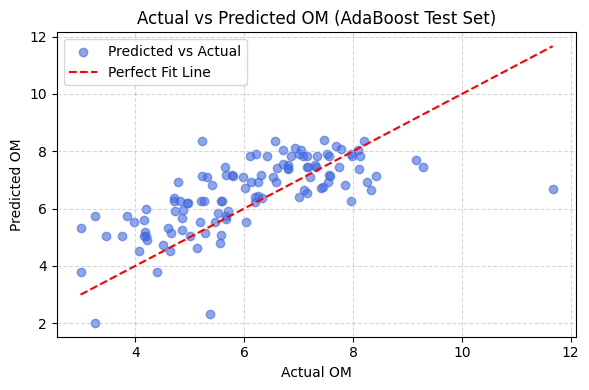

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for AdaBoost ===
model = joblib.load("best_ada_model.pkl")        # AdaBoost model
scaler = joblib.load("scaler_ada.pkl")           # Scaler for selected features
selected_features = joblib.load("selected_features_ada.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (AdaBoost):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"RPIQ: {rpiq:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (AdaBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


CAT_regression_train

In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.7 MB/s eta 0:00:00



✅ Best Hyperparameters from GridSearchCV:
{'depth': 6, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}

📊 Per Fold Metrics:
Fold 1: MBE=-0.1667, MAE=1.0991, RMSE=1.5102, R²=0.6625
Fold 2: MBE=-0.1151, MAE=1.1769, RMSE=1.5493, R²=0.5403
Fold 3: MBE=0.4865, MAE=0.8100, RMSE=1.0453, R²=0.6839
Fold 4: MBE=0.0818, MAE=1.1124, RMSE=1.5050, R²=0.5463
Fold 5: MBE=-0.1697, MAE=1.1823, RMSE=1.6206, R²=0.5901
Fold 6: MBE=0.1926, MAE=0.8790, RMSE=1.1614, R²=0.7337
Fold 7: MBE=0.0251, MAE=1.0472, RMSE=1.3337, R²=0.6201
Fold 8: MBE=-0.0035, MAE=0.9053, RMSE=1.2970, R²=0.7293
Fold 9: MBE=-0.0696, MAE=0.9145, RMSE=1.2873, R²=0.6976
Fold 10: MBE=-0.2086, MAE=1.0969, RMSE=1.6581, R²=0.6131

📌 Average 10-Fold Metrics:
MBE:  0.0053
MAE:  1.0224
RMSE: 1.3968
R²:   0.6417


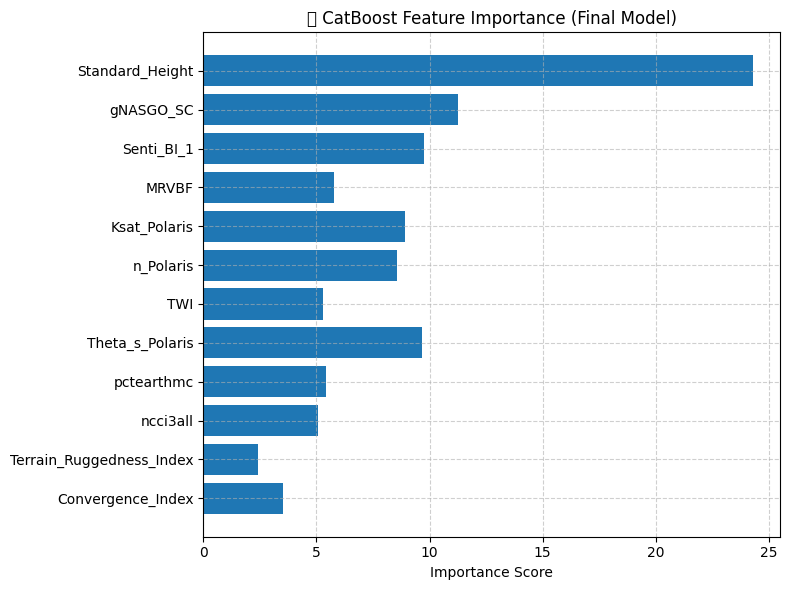

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
cat_base = CatBoostRegressor(verbose=0, random_state=42)
cat_base.fit(X_scaled, y)
perm_importance = permutation_importance(cat_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scaling Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.01,0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}
grid_search = GridSearchCV(
    CatBoostRegressor(verbose=0, random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_cat = grid_search.best_estimator_

print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_cat.fit(X_t, y_t)
    y_pred = best_cat.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_cat, "best_cat_model.pkl")
joblib.dump(scaler, "scaler_cat.pkl")
joblib.dump(selected_features, "selected_features_cat.pkl")

# === Step 9: Feature Importance Plot from Final Model ===
final_feat_importance = best_cat.get_feature_importance(Pool(X_selected_scaled, label=y))

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_feat_importance)
plt.title("📌 CatBoost Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


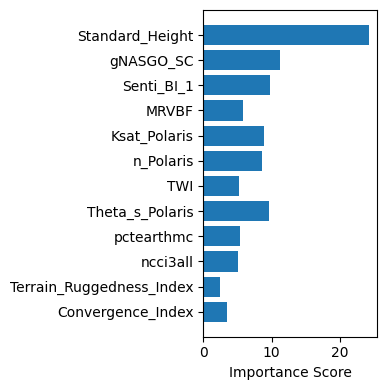

In [ ]:
# === Step 9: Feature Importance Plot from Final Model ===
final_feat_importance = best_cat.get_feature_importance(Pool(X_selected_scaled, label=y))

plt.figure(figsize=(4, 4))
plt.barh(selected_features, final_feat_importance)

plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
#plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

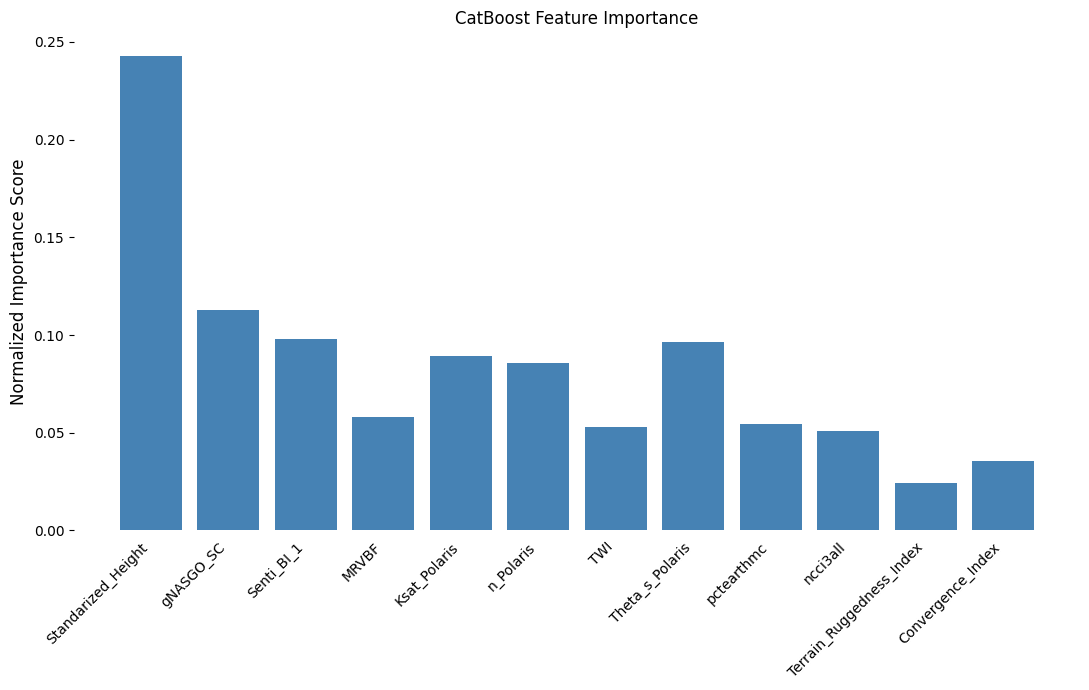

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from catboost import Pool

# Assuming you already have:
# - selected_features (list of feature names)
# - X_selected_scaled (scaled feature matrix)
# - y (target variable)
# - best_cat (fitted CatBoost model)

# === Step 9: Feature Importance Plot from Final Model ===
final_feat_importance = best_cat.get_feature_importance(Pool(X_selected_scaled, label=y))
final_feat_importance_normalized = final_feat_importance / np.sum(final_feat_importance)

plt.figure(figsize=(11, 7))
bars = plt.bar(selected_features, final_feat_importance_normalized, color='steelblue')

# Aesthetic settings for "plain" look
plt.title("CatBoost Feature Importance", fontsize=12,)
plt.ylabel("Normalized Importance Score", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', right=False)

# Remove background grid and frame
plt.grid(False)
plt.gca().set_facecolor('white')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()


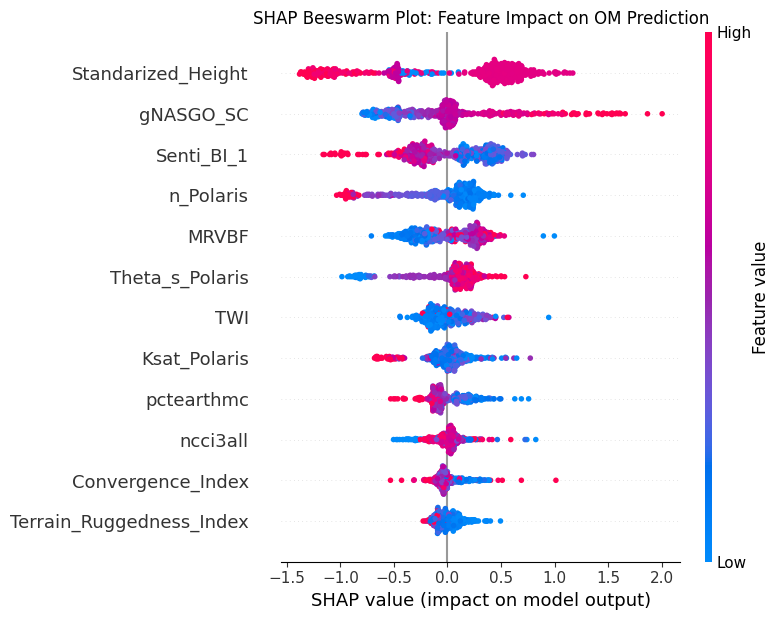

In [ ]:
import shap

# === Step 10: SHAP Beeswarm Plot for Selected Features ===

# Load model and selected features
model = joblib.load("/content/best_cat_model.pkl")
selected_features = joblib.load("/content/selected_features_cat.pkl")

# Prepare original unscaled selected features DataFrame
X_selected_df = X[selected_features]

# Fit the model again on full data (unscaled) to match SHAP expectations
model.fit(X_selected_df, y)

# Create SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_selected_df)

# Plot SHAP summary (beeswarm)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP Beeswarm Plot: Feature Impact on OM Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm_selected_features.png", dpi=300, bbox_inches='tight')
plt.show()


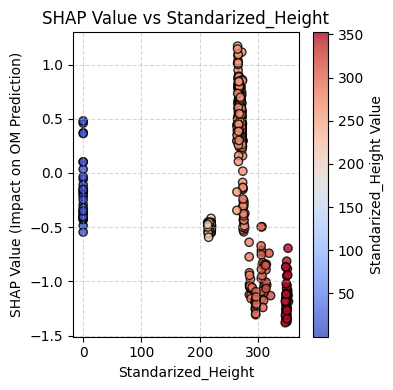

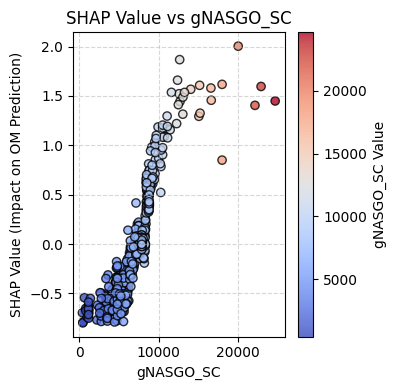

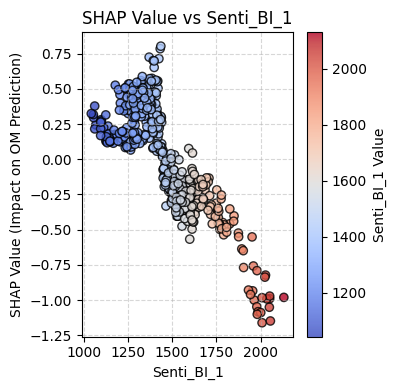

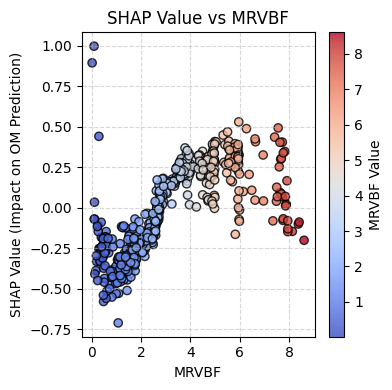

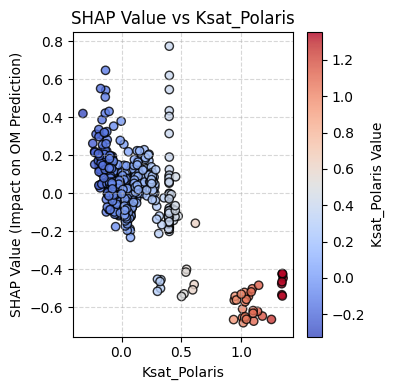

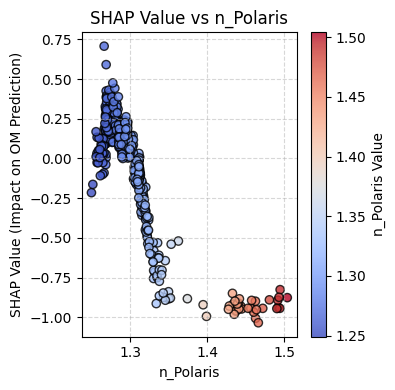

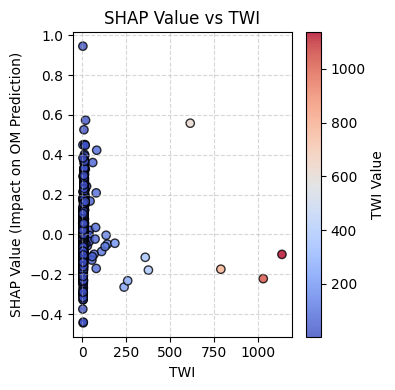

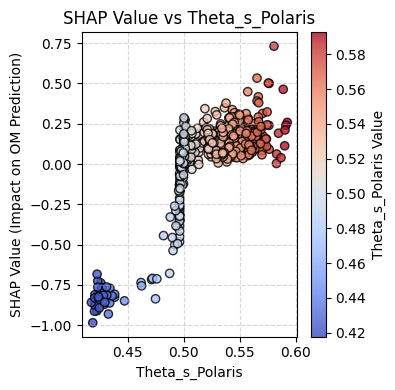

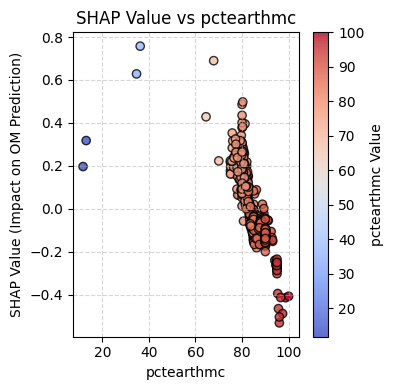

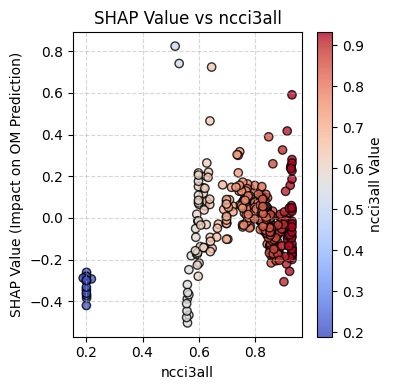

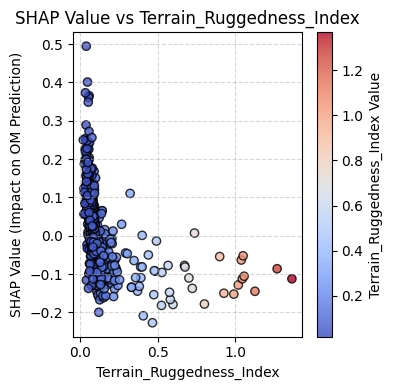

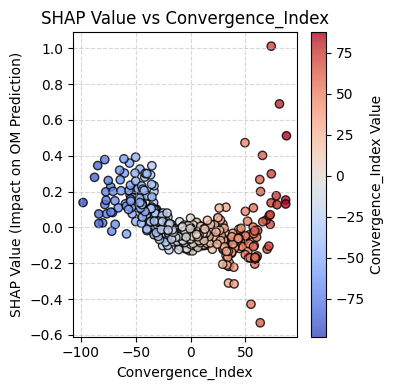

In [ ]:
import shap
import matplotlib.pyplot as plt
import joblib

# === Load artifacts ===
model = joblib.load("/content/best_cat_model.pkl")
selected_features = joblib.load("/content/selected_features_cat.pkl")

# Prepare input
X_selected_df = X[selected_features]  # original feature values (not scaled)
model.fit(X_selected_df, y)

# SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_selected_df)

# === Loop through features ===
for feature in selected_features:
    feature_index = selected_features.index(feature)
    feature_values = X_selected_df[feature].values
    shap_vals = shap_values[:, feature_index].values

    plt.figure(figsize=(4, 4), dpi=100)
    scatter = plt.scatter(
        feature_values,
        shap_vals,
        c=feature_values,
        cmap='coolwarm',
        edgecolors='k',
        alpha=0.8
    )
    plt.colorbar(scatter, label=f"{feature} Value")
    plt.xlabel(f"{feature}")
    plt.ylabel("SHAP Value (Impact on OM Prediction)")
    plt.title(f"SHAP Value vs {feature}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"shap_dependence_{feature}.png", dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
CAT_  TRAIN WITH RPIQ


✅ Best Hyperparameters from GridSearchCV:
{'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}

📊 Per Fold Metrics:
Fold 1: MBE=-0.0271, MAE=1.1766, RMSE=1.6397, R²=0.6021, RPIQ=1.8876
Fold 2: MBE=-0.1128, MAE=1.1393, RMSE=1.5364, R²=0.5480, RPIQ=1.6842
Fold 3: MBE=0.3545, MAE=0.8439, RMSE=1.0348, R²=0.6902, RPIQ=2.2371
Fold 4: MBE=0.1405, MAE=1.0541, RMSE=1.4361, R²=0.5869, RPIQ=1.8522
Fold 5: MBE=-0.2291, MAE=1.1925, RMSE=1.6843, R²=0.5572, RPIQ=1.6075
Fold 6: MBE=0.1562, MAE=0.9096, RMSE=1.1965, R²=0.7173, RPIQ=1.8387
Fold 7: MBE=-0.0020, MAE=1.0308, RMSE=1.3311, R²=0.6215, RPIQ=2.2237
Fold 8: MBE=-0.0389, MAE=0.8831, RMSE=1.2822, R²=0.7355, RPIQ=2.2617
Fold 9: MBE=0.0052, MAE=0.9571, RMSE=1.2984, R²=0.6924, RPIQ=1.7868
Fold 10: MBE=-0.2740, MAE=1.0553, RMSE=1.6307, R²=0.6258, RPIQ=1.7968

📌 Average 10-Fold CV Metrics:
MBE:  -0.0027
MAE:  1.0242
RMSE: 1.4070
R²:   0.6377
RPIQ: 1.9176


/tmp/ipython-input-4030410778.py:140: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


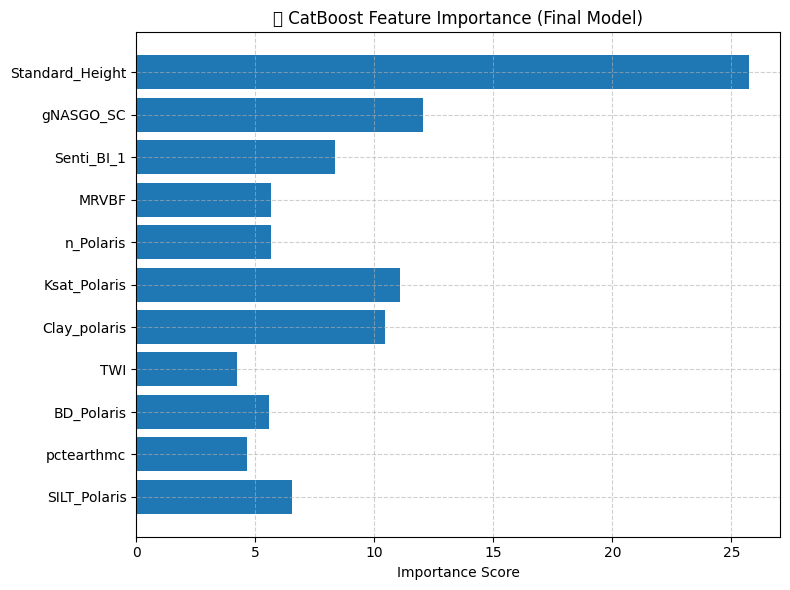

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance (Feature Selection) ===
cat_base = CatBoostRegressor(verbose=0, random_state=42)
cat_base.fit(X_scaled, y)

perm_importance = permutation_importance(
    cat_base, X_scaled, y,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm_importance.importances_mean
    })
    .sort_values(by='Importance', ascending=False)
)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

grid_search = GridSearchCV(
    CatBoostRegressor(verbose=0, random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_cat = grid_search.best_estimator_

print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation with RPIQ ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [], 'mae': [], 'rmse': [], 'r2': [], 'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_cat.fit(X_t, y_t)
    y_pred = best_cat.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    # === RPIQ calculation (validation set only) ===
    q75, q25 = np.percentile(y_v, [75, 25])
    iqr = q75 - q25
    rpiq = iqr / rmse if rmse != 0 else np.nan

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {fold}: "
        f"MBE={mbe:.4f}, "
        f"MAE={mae:.4f}, "
        f"RMSE={rmse:.4f}, "
        f"R²={r2:.4f}, "
        f"RPIQ={rpiq:.4f}"
    )

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold CV Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_cat, "best_cat_model.pkl")
joblib.dump(scaler, "scaler_cat.pkl")
joblib.dump(selected_features, "selected_features_cat.pkl")

# === Step 9: Feature Importance Plot (Final Model) ===
final_feat_importance = best_cat.get_feature_importance(
    Pool(X_selected_scaled, label=y)
)

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_feat_importance)
plt.title("📌 CatBoost Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


CAT_TEST

🔍 Features used for prediction:
 - Standarized_Height
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Ksat_Polaris
 - n_Polaris
 - TWI
 - Theta_s_Polaris
 - pctearthmc
 - ncci3all
 - Terrain_Ruggedness_Index
 - Convergence_Index

📊 Test Set Metrics (CatBoost):
MBE:  0.063
MAE:  0.792
RMSE: 1.047
R²:   0.52


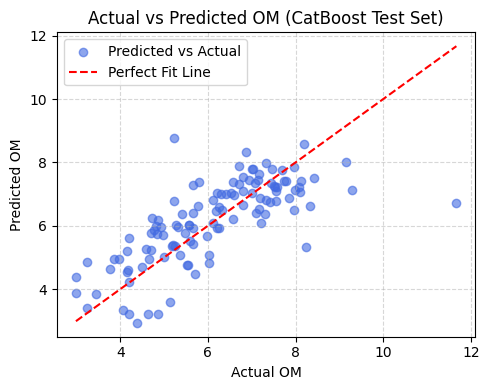

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for CatBoost ===
model = joblib.load("best_cat_model.pkl")        # ✅ CatBoost model
scaler = joblib.load("scaler_cat.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_cat.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (CatBoost):")
print(f"MBE:  {mbe:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.2f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (CatBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


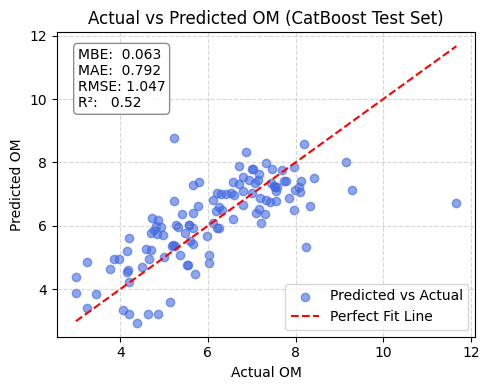

In [ ]:
# === Step 8: Plot Actual vs Predicted with Metrics Box ===
plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")

plt.title("Actual vs Predicted OM (CatBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Add metrics inside a box
metrics_text = (
    f"MBE:  {mbe:.3f}\n"
    f"MAE:  {mae:.3f}\n"
    f"RMSE: {rmse:.3f}\n"
    f"R²:   {r2:.2f}"
)

plt.text(
    0.05, 0.95, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
)

plt.tight_layout()
plt.show()


test_cat_no

🔍 Features used for prediction:
 - Standard_Height
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - n_Polaris
 - Ksat_Polaris
 - Clay_polaris
 - TWI
 - BD_Polaris
 - pctearthmc
 - SILT_Polaris

📊 Test Set Metrics (CatBoost):
MBE:  -0.067
MAE:  0.783
RMSE: 1.057
R²:   0.51
RPIQ: 2.105


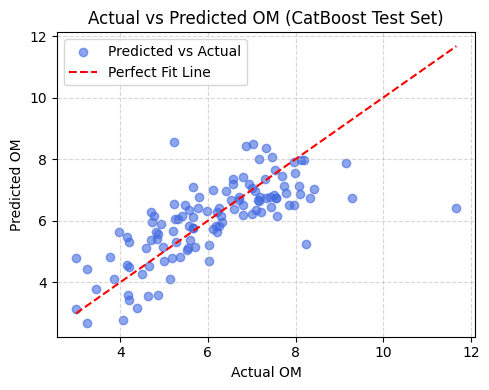

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for CatBoost ===
model = joblib.load("best_cat_model.pkl")        # CatBoost model
scaler = joblib.load("scaler_cat.pkl")           # Scaler for selected features
selected_features = joblib.load("selected_features_cat.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (CatBoost):")
print(f"MBE:  {mbe:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.2f}")
print(f"RPIQ: {rpiq:.3f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (CatBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Train_LightGBM


✅ Best Hyperparameters from GridSearchCV:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0.1}

📊 Per Fold Metrics:
Fold 1: MBE=-0.2052, MAE=0.9750, RMSE=1.4270, R²=0.6986
Fold 2: MBE=-0.0487, MAE=1.1434, RMSE=1.4918, R²=0.5738
Fold 3: MBE=0.4104, MAE=0.7171, RMSE=0.9503, R²=0.7387
Fold 4: MBE=0.1235, MAE=1.2344, RMSE=1.6144, R²=0.4779
Fold 5: MBE=-0.0376, MAE=1.1536, RMSE=1.5814, R²=0.6097
Fold 6: MBE=0.1426, MAE=0.9436, RMSE=1.2936, R²=0.6696
Fold 7: MBE=-0.0234, MAE=1.0998, RMSE=1.3551, R²=0.6078
Fold 8: MBE=-0.0517, MAE=0.8870, RMSE=1.3113, R²=0.7233
Fold 9: MBE=-0.0581, MAE=0.9263, RMSE=1.3210, R²=0.6816
Fold 10: MBE=-0.3063, MAE=1.0655, RMSE=1.5815, R²=0.6480

📌 Average 10-Fold Metrics:
MBE:  -0.0055
MAE:  1.0146
RMSE: 1.3927
R²:   0.6429


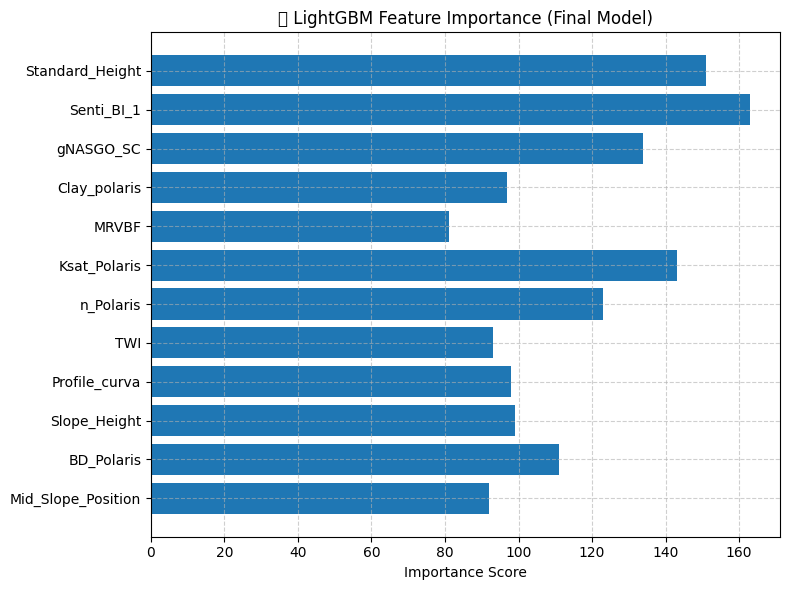

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
lgb_base = LGBMRegressor(random_state=42, verbose=-1)
lgb_base.fit(X_scaled, y)
perm_importance = permutation_importance(lgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [15, 31, 63],
    'reg_alpha': [0, 0.1, 1.0]
}

grid_search = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_selected_scaled, y)
best_lgb = grid_search.best_estimator_

# ✅ Print Best Hyperparameters
print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_lgb.fit(X_t, y_t)
    y_pred = best_lgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_lgb, "best_lgb_model.pkl")
joblib.dump(scaler, "scaler_lgb.pkl")
joblib.dump(selected_features, "selected_features_lgb.pkl")

# === Step 9: Plot Feature Importances ===
feat_importance = best_lgb.feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, feat_importance)
plt.title("📌 LightGBM Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


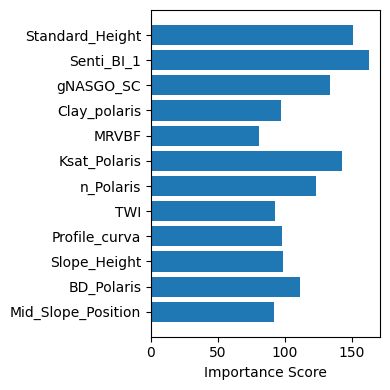

In [ ]:
# === Step 9: Plot Feature Importances ===
feat_importance = best_lgb.feature_importances_

plt.figure(figsize=(4, 4))
plt.barh(selected_features, feat_importance)

plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
#plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# === Step 8: Save Artifacts ===
joblib.dump(best_lgb, "best_lgb_model.pkl")
joblib.dump(scaler, "scaler_lgb.pkl")
joblib.dump(selected_features, "selected_features_lgb.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v


✅ Best Hyperparameters from GridSearchCV:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0}

📊 Per Fold Metrics:
Fold 1: MBE=-0.2126, MAE=1.0048, RMSE=1.4098, R²=0.7059, RPIQ=2.1954


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 2: MBE=-0.0685, MAE=1.2258, RMSE=1.6664, R²=0.4682, RPIQ=1.5527
Fold 3: MBE=0.4237, MAE=0.7841, RMSE=0.9815, R²=0.7213, RPIQ=2.3587


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 6: MBE=0.1548, MAE=1.0123, RMSE=1.2659, R²=0.6836, RPIQ=1.7379
Fold 7: MBE=-0.0092, MAE=0.9794, RMSE=1.2548, R²=0.6637, RPIQ=2.3590


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 8: MBE=-0.0025, MAE=0.8608, RMSE=1.2543, R²=0.7468, RPIQ=2.3120
Fold 9: MBE=0.0002, MAE=1.0215, RMSE=1.4292, R²=0.6273, RPIQ=1.6233
Fold 10: MBE=-0.2653, MAE=1.0768, RMSE=1.6276, R²=0.6272, RPIQ=1.8002

📌 Average 10-Fold CV Metrics:
MBE:  0.0038
MAE:  1.0341
RMSE: 1.3994
R²:   0.6387
RPIQ: 1.9397


/tmp/ipython-input-2593048636.py:141: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


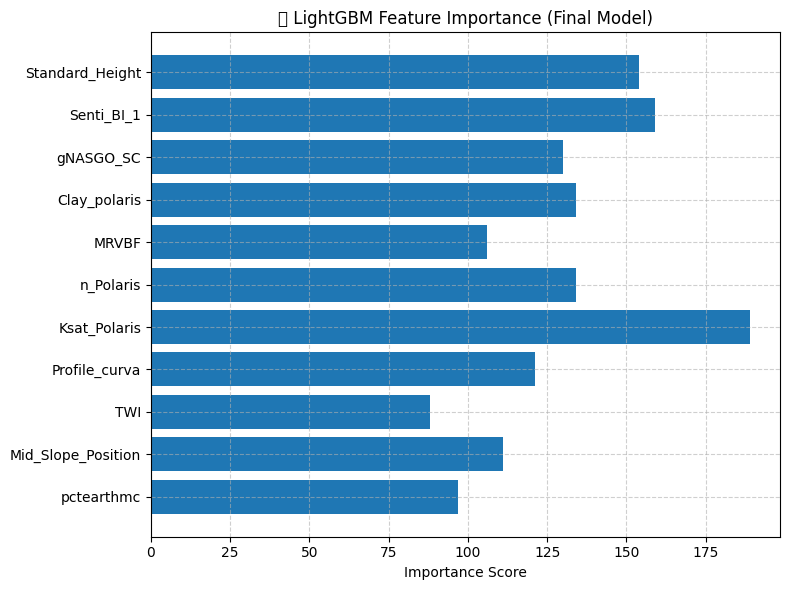

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris' ],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance (Feature Selection) ===
lgb_base = LGBMRegressor(random_state=42, verbose=-1)
lgb_base.fit(X_scaled, y)

perm_importance = permutation_importance(
    lgb_base, X_scaled, y,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm_importance.importances_mean
    })
    .sort_values(by='Importance', ascending=False)
)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [15, 31, 63],
    'reg_alpha': [0, 0.1, 1.0]
}

grid_search = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_selected_scaled, y)
best_lgb = grid_search.best_estimator_

# === Best Hyperparameters ===
print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation with RPIQ ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [], 'mae': [], 'rmse': [], 'r2': [], 'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_lgb.fit(X_t, y_t)
    y_pred = best_lgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    # === RPIQ calculation (validation fold only) ===
    q75, q25 = np.percentile(y_v, [75, 25])
    iqr = q75 - q25
    rpiq = iqr / rmse if rmse != 0 else np.nan

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {fold}: "
        f"MBE={mbe:.4f}, "
        f"MAE={mae:.4f}, "
        f"RMSE={rmse:.4f}, "
        f"R²={r2:.4f}, "
        f"RPIQ={rpiq:.4f}"
    )

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold CV Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_lgb, "best_lgb_model.pkl")
joblib.dump(scaler, "scaler_lgb.pkl")
joblib.dump(selected_features, "selected_features_lgb.pkl")

# === Step 9: Feature Importance Plot ===
feat_importance = best_lgb.feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, feat_importance)
plt.title("📌 LightGBM Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


TEST_LIGHTGBM

🔍 Features used for prediction:
 - Standarized_Height
 - Senti_BI_1
 - gNASGO_SC
 - Clay_polaris
 - MRVBF
 - Ksat_Polaris
 - n_Polaris
 - TWI
 - Profile_curva
 - Slope_Height
 - BD_Polaris
 - Mid_Slope_Position

📊 Test Set Metrics (LightGBM):
MBE:  -0.3606
MAE:  1.0609
RMSE: 1.4064
R²:   0.1261


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


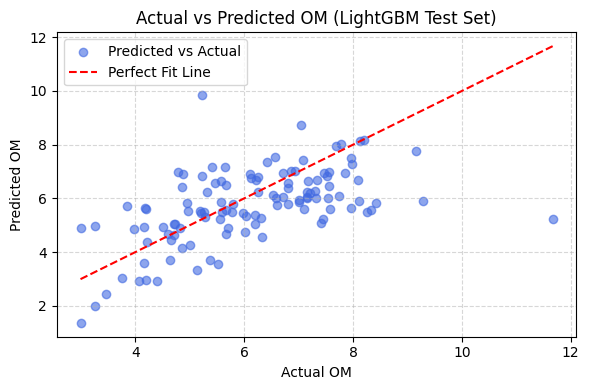

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for LightGBM ===
model = joblib.load("best_lgb_model.pkl")        # ✅ LightGBM model
scaler = joblib.load("scaler_lgb.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_lgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (LightGBM):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (LightGBM Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


test

🔍 Features used for prediction:
 - Standard_Height
 - Senti_BI_1
 - gNASGO_SC
 - Clay_polaris
 - MRVBF
 - n_Polaris
 - Ksat_Polaris
 - Profile_curva
 - TWI
 - Mid_Slope_Position
 - pctearthmc

📊 Test Set Metrics (LightGBM):
MBE:  -0.3458
MAE:  0.9786
RMSE: 1.3534
R²:   0.1907
RPIQ: 1.6440


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


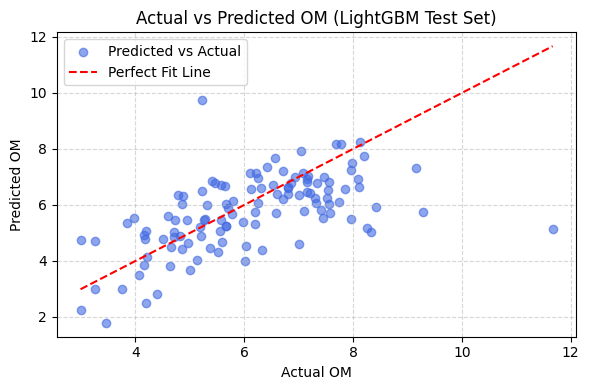

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for LightGBM ===
model = joblib.load("best_lgb_model.pkl")        # LightGBM model
scaler = joblib.load("scaler_lgb.pkl")           # Scaler for selected features
selected_features = joblib.load("selected_features_lgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (LightGBM):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"RPIQ: {rpiq:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (LightGBM Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Train_Bayasian_Ridge


✅ Best Hyperparameters from GridSearchCV:
{'alpha_1': 1e-06, 'alpha_2': 0.0001, 'lambda_1': 0.0001, 'lambda_2': 1e-06}

📊 Per Fold Metrics:
Fold 1: MBE=-0.3018, MAE=1.3233, RMSE=1.8965, R²=0.4677
Fold 2: MBE=-0.3906, MAE=1.4456, RMSE=1.9020, R²=0.3072
Fold 3: MBE=0.6606, MAE=0.9715, RMSE=1.2166, R²=0.5717
Fold 4: MBE=-0.2226, MAE=1.2237, RMSE=1.6852, R²=0.4311
Fold 5: MBE=-0.2141, MAE=1.5664, RMSE=1.9431, R²=0.4107
Fold 6: MBE=0.6671, MAE=1.3668, RMSE=1.7248, R²=0.4125
Fold 7: MBE=0.1189, MAE=1.3161, RMSE=1.6089, R²=0.4471
Fold 8: MBE=-0.0808, MAE=1.3092, RMSE=1.6989, R²=0.5356
Fold 9: MBE=-0.0243, MAE=1.2983, RMSE=1.7469, R²=0.4432
Fold 10: MBE=-0.2033, MAE=1.4607, RMSE=1.9019, R²=0.4909

📌 Average 10-Fold Metrics:
MBE:  0.0009
MAE:  1.3282
RMSE: 1.7325
R²:   0.4518


/tmp/ipython-input-1136843802.py:102: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


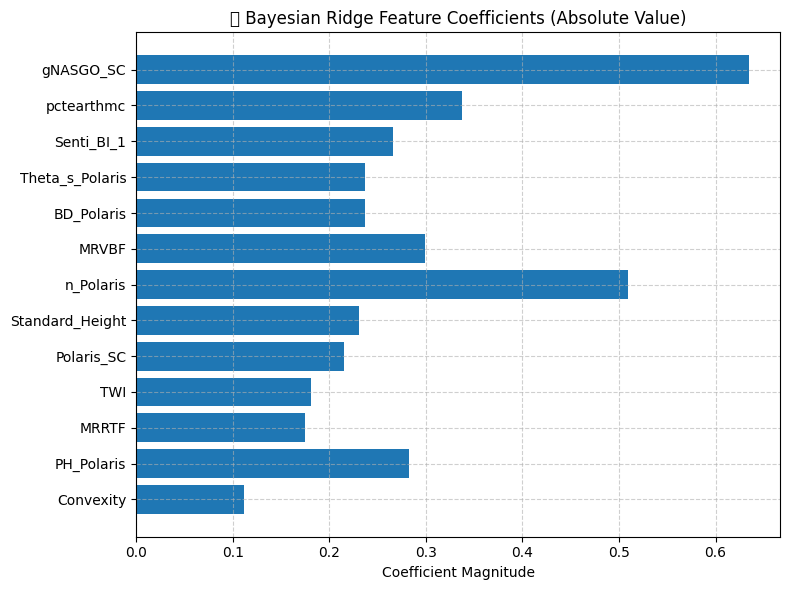

In [21]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
ridge_base = BayesianRidge()
ridge_base.fit(X_scaled, y)
perm_importance = permutation_importance(ridge_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.45 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'alpha_1': [1e-6, 1e-5, 1e-4],
    'alpha_2': [1e-6, 1e-5, 1e-4],
    'lambda_1': [1e-6, 1e-5, 1e-4],
    'lambda_2': [1e-6, 1e-5, 1e-4]
}

grid_search = GridSearchCV(BayesianRidge(), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_ridge = grid_search.best_estimator_

# ✅ Print Best Hyperparameters
print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_ridge.fit(X_t, y_t)
    y_pred = best_ridge.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_ridge, "best_bayes_model.pkl")
joblib.dump(scaler, "scaler_bayes.pkl")
joblib.dump(selected_features, "selected_features_bayes.pkl")

# === Step 9: Plot Coefficients ===
coef_importance = best_ridge.coef_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, np.abs(coef_importance))
plt.title("📌 Bayesian Ridge Feature Coefficients (Absolute Value)")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



✅ Best Hyperparameters:
{'alpha_1': 1e-06, 'alpha_2': 0.0001, 'lambda_1': 0.0001, 'lambda_2': 1e-06}

📊 Per-Fold Metrics:
Fold 1: MBE=-0.3018, MAE=1.3233, RMSE=1.8965, R²=0.4677
Fold 2: MBE=-0.3906, MAE=1.4456, RMSE=1.9020, R²=0.3072
Fold 3: MBE=0.6606, MAE=0.9715, RMSE=1.2166, R²=0.5717
Fold 4: MBE=-0.2226, MAE=1.2237, RMSE=1.6852, R²=0.4311
Fold 5: MBE=-0.2141, MAE=1.5664, RMSE=1.9431, R²=0.4107
Fold 6: MBE=0.6671, MAE=1.3668, RMSE=1.7248, R²=0.4125
Fold 7: MBE=0.1189, MAE=1.3161, RMSE=1.6089, R²=0.4471
Fold 8: MBE=-0.0808, MAE=1.3092, RMSE=1.6989, R²=0.5356
Fold 9: MBE=-0.0243, MAE=1.2983, RMSE=1.7469, R²=0.4432
Fold 10: MBE=-0.2033, MAE=1.4607, RMSE=1.9019, R²=0.4909

📌 Average 10-Fold Metrics:
MBE:  0.0009
MAE:  1.3282
RMSE: 1.7325
R²:   0.4518
RPIQ: 1.5585


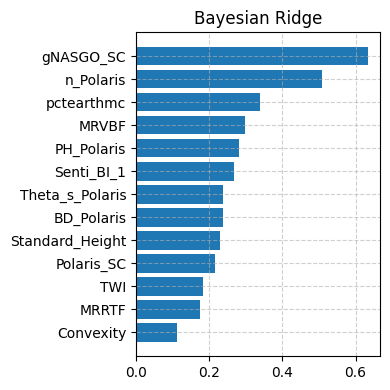

In [26]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================================================
# STEP 1: LOAD & CLEAN DATA
# ======================================================
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=[
        'OM', 'SAMPLEDATE', 'lati', 'Relative_Elev',
        'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'
    ],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# ======================================================
# STEP 2: INITIAL SCALING
# ======================================================
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# ======================================================
# STEP 3: PERMUTATION IMPORTANCE (FEATURE SELECTION)
# ======================================================
ridge_base = BayesianRidge()
ridge_base.fit(X_scaled, y)

perm_importance = permutation_importance(
    ridge_base,
    X_scaled,
    y,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm_importance.importances_mean
    })
    .sort_values(by='Importance', ascending=False)
)

top_k = int(0.45 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# ======================================================
# STEP 4: SCALE SELECTED FEATURES
# ======================================================
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# ======================================================
# STEP 5: HYPERPARAMETER TUNING
# ======================================================
param_grid = {
    'alpha_1': [1e-6, 1e-5, 1e-4],
    'alpha_2': [1e-6, 1e-5, 1e-4],
    'lambda_1': [1e-6, 1e-5, 1e-4],
    'lambda_2': [1e-6, 1e-5, 1e-4]
}

grid_search = GridSearchCV(
    BayesianRidge(),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_ridge = grid_search.best_estimator_

print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# ======================================================
# STEP 6: 10-FOLD CROSS-VALIDATION
# ======================================================
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [],
    'mae': [],
    'rmse': [],
    'r2': []
}

print("\n📊 Per-Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_ridge.fit(X_t, y_t)
    y_pred = best_ridge.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(
        f"Fold {fold}: "
        f"MBE={mbe:.4f}, MAE={mae:.4f}, "
        f"RMSE={rmse:.4f}, R²={r2:.4f}"
    )

# ======================================================
# STEP 7: AVERAGE METRICS
# ======================================================
rmse_avg = np.mean(metrics['rmse'])

print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {rmse_avg:.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# ======================================================
# STEP 7.1: RPIQ CALCULATION
# ======================================================
q75, q25 = np.percentile(y, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse_avg

print(f"RPIQ: {rpiq:.4f}")

# ======================================================
# STEP 8: SAVE ARTIFACTS
# ======================================================
joblib.dump(best_ridge, "best_bayes_model.pkl")
joblib.dump(scaler, "scaler_bayes.pkl")
joblib.dump(selected_features, "selected_features_bayes.pkl")

# ======================================================
# STEP 9: FEATURE COEFFICIENT PLOT
# ======================================================
coef_importance = np.abs(best_ridge.coef_)

# Sort coefficients (high → low)
sorted_idx = np.argsort(coef_importance)[::-1]
features_sorted = np.array(selected_features)[sorted_idx]
coef_sorted = coef_importance[sorted_idx]

plt.figure(figsize=(4, 4))
plt.barh(features_sorted, coef_sorted)
plt.title("Bayesian Ridge")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


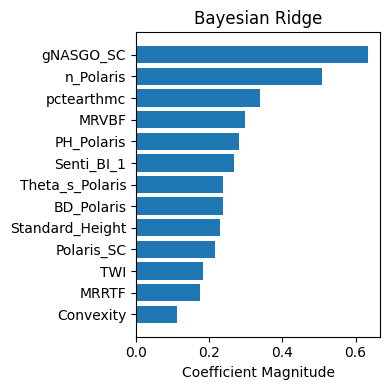

In [30]:
plt.figure(figsize=(4, 4))
plt.barh(features_sorted, coef_sorted)

plt.title("Bayesian Ridge")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()

# ❌ removed grid
# plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


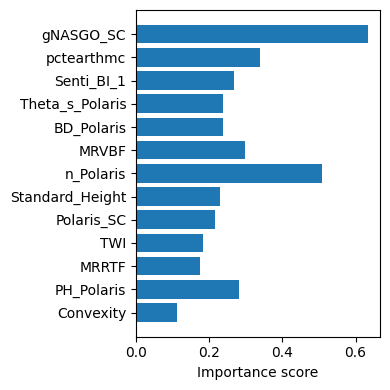

In [27]:
#== Step 9: Plot Coefficients ===
coef_importance = best_ridge.coef_

plt.figure(figsize=(4, 4))
plt.barh(selected_features, np.abs(coef_importance))

plt.xlabel("Importance score")
plt.gca().invert_yaxis()
#plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


✅ Best Hyperparameters from GridSearchCV:
{'alpha_1': 1e-06, 'alpha_2': 0.0001, 'lambda_1': 0.0001, 'lambda_2': 1e-06}

📊 Per Fold Metrics:
Fold 1: MBE=-0.2566, MAE=1.3496, RMSE=1.8913, R²=0.4706, RPIQ=1.6364
Fold 2: MBE=-0.4038, MAE=1.4281, RMSE=1.8840, R²=0.3203, RPIQ=1.3734
Fold 3: MBE=0.6942, MAE=0.9918, RMSE=1.2386, R²=0.5561, RPIQ=1.8691
Fold 4: MBE=-0.2330, MAE=1.2618, RMSE=1.7192, R²=0.4080, RPIQ=1.5473
Fold 5: MBE=-0.2301, MAE=1.5517, RMSE=1.9521, R²=0.4052, RPIQ=1.3870
Fold 6: MBE=0.6507, MAE=1.3747, RMSE=1.7446, R²=0.3990, RPIQ=1.2610
Fold 7: MBE=0.1426, MAE=1.3223, RMSE=1.6241, R²=0.4366, RPIQ=1.8225
Fold 8: MBE=-0.0642, MAE=1.3440, RMSE=1.7130, R²=0.5278, RPIQ=1.6929
Fold 9: MBE=-0.0548, MAE=1.3280, RMSE=1.7808, R²=0.4214, RPIQ=1.3028
Fold 10: MBE=-0.2223, MAE=1.4876, RMSE=1.9347, R²=0.4733, RPIQ=1.5144

📌 Average 10-Fold CV Metrics:
MBE:  0.0023
MAE:  1.3440
RMSE: 1.7482
R²:   0.4418
RPIQ: 1.5407


/tmp/ipython-input-563312360.py:141: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


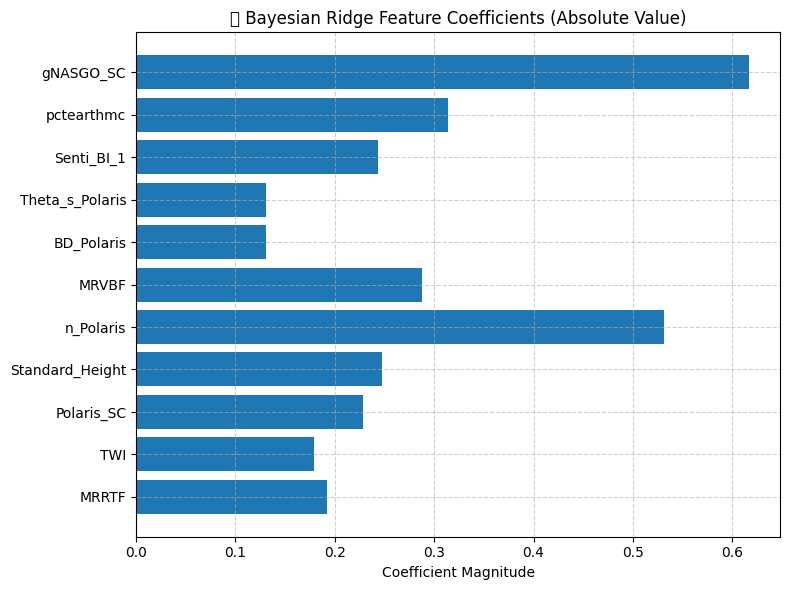

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance (Feature Selection) ===
ridge_base = BayesianRidge()
ridge_base.fit(X_scaled, y)

perm_importance = permutation_importance(
    ridge_base,
    X_scaled,
    y,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm_importance.importances_mean
    })
    .sort_values(by='Importance', ascending=False)
)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'alpha_1': [1e-6, 1e-5, 1e-4],
    'alpha_2': [1e-6, 1e-5, 1e-4],
    'lambda_1': [1e-6, 1e-5, 1e-4],
    'lambda_2': [1e-6, 1e-5, 1e-4]
}

grid_search = GridSearchCV(
    BayesianRidge(),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_ridge = grid_search.best_estimator_

print("\n✅ Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation with RPIQ ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [], 'mae': [], 'rmse': [], 'r2': [], 'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_ridge.fit(X_t, y_t)
    y_pred = best_ridge.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    # === RPIQ calculation (validation fold) ===
    q75, q25 = np.percentile(y_v, [75, 25])
    iqr = q75 - q25
    rpiq = iqr / rmse if rmse != 0 else np.nan

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {fold}: "
        f"MBE={mbe:.4f}, "
        f"MAE={mae:.4f}, "
        f"RMSE={rmse:.4f}, "
        f"R²={r2:.4f}, "
        f"RPIQ={rpiq:.4f}"
    )

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold CV Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_ridge, "best_bayes_model.pkl")
joblib.dump(scaler, "scaler_bayes.pkl")
joblib.dump(selected_features, "selected_features_bayes.pkl")

# === Step 9: Plot Coefficients ===
coef_importance = best_ridge.coef_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, np.abs(coef_importance))
plt.title("📌 Bayesian Ridge Feature Coefficients (Absolute Value)")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


TEST

🔍 Features used for prediction:
 - gNASGO_SC
 - pctearthmc
 - Senti_BI_1
 - Theta_s_Polaris
 - MRVBF
 - BD_Polaris
 - n_Polaris
 - Standarized_Height
 - Polaris_SC
 - TWI
 - MRRTF
 - PH_Polaris

📊 Test Set Metrics (LightGBM):
MBE:  -0.3907
MAE:  0.8810
RMSE: 1.1255
R²:   0.4403


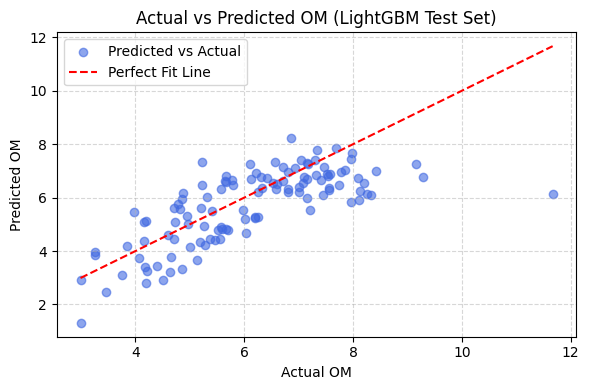

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for LightGBM ===
model = joblib.load("/content/best_bayes_model.pkl")        # ✅ LightGBM model
scaler = joblib.load("/content/scaler_bayes.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("/content/selected_features_bayes.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (LightGBM):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (LightGBM Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - gNASGO_SC
 - pctearthmc
 - Senti_BI_1
 - Theta_s_Polaris
 - BD_Polaris
 - MRVBF
 - n_Polaris
 - Standard_Height
 - Polaris_SC
 - TWI
 - MRRTF

📊 Test Set Metrics (Bayesian Ridge):
MBE:  -0.2797
MAE:  0.7946
RMSE: 1.0415
R²:   0.5207
RPIQ: 2.1363


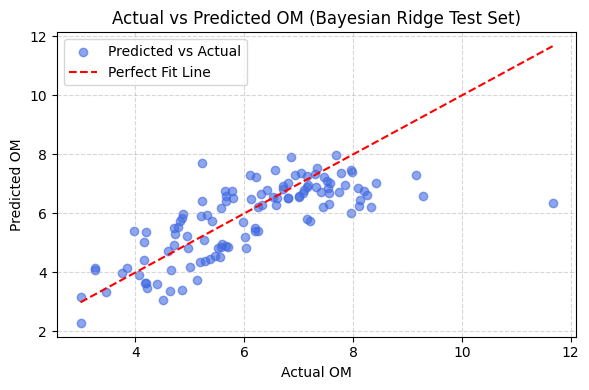

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for Bayesian Ridge ===
model = joblib.load("/content/best_bayes_model.pkl")
scaler = joblib.load("/content/scaler_bayes.pkl")
selected_features = joblib.load("/content/selected_features_bayes.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris'],
    errors='ignore'
)
y_test = df_test['OM']

# === Ensure feature consistency ===
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict ===
y_pred = model.predict(X_test_scaled)

# === Metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# === RPIQ calculation ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

# === Print metrics ===
print("\n📊 Test Set Metrics (Bayesian Ridge):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"RPIQ: {rpiq:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)
plt.title("Actual vs Predicted OM (Bayesian Ridge Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


MLP_Train


📊 Per Fold Metrics:
Fold 1: MBE=-0.0801, MAE=1.2809, RMSE=1.8953, R²=0.4684
Fold 2: MBE=-0.1157, MAE=1.5566, RMSE=2.1584, R²=0.1079
Fold 3: MBE=0.5146, MAE=0.9188, RMSE=1.2126, R²=0.5745
Fold 4: MBE=0.3087, MAE=1.5191, RMSE=1.8820, R²=0.2905


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 5: MBE=0.0769, MAE=1.3300, RMSE=1.8715, R²=0.4533


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 6: MBE=0.2056, MAE=1.2049, RMSE=1.7382, R²=0.4034


...

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 9: MBE=-0.1461, MAE=1.0611, RMSE=1.4139, R²=0.6352


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 10: MBE=-0.2425, MAE=1.4164, RMSE=2.0503, R²=0.4084

📌 Average 10-Fold Metrics:
MBE:  0.1054
MAE:  1.2625
RMSE: 1.7402
R²:   0.4393


/tmp/ipython-input-16-4081087770.py:91: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


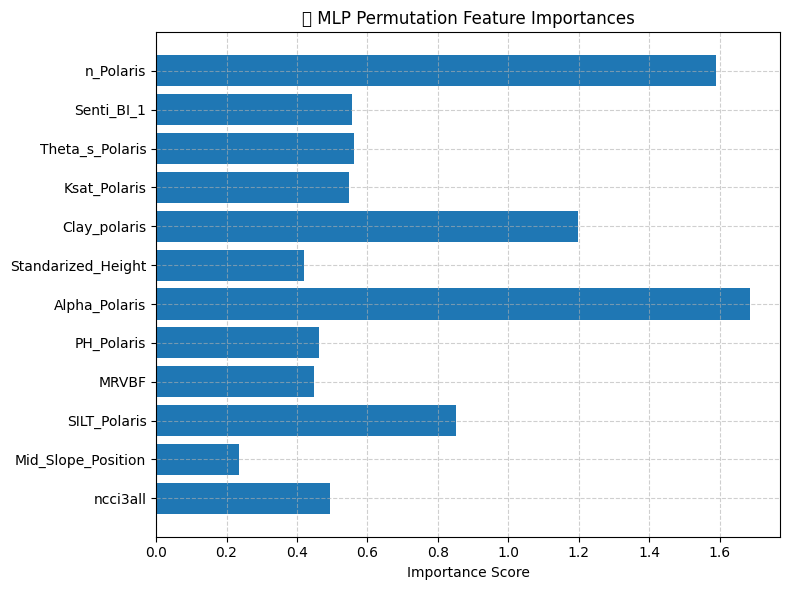

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance using base MLP ===
mlp_base = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_base.fit(X_scaled, y)
perm_importance = permutation_importance(mlp_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Final Scaling of Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Initialize Final MLP Regressor ===
best_mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                        solver='adam', learning_rate_init=0.001,
                        max_iter=1000, random_state=42)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_mlp.fit(X_t, y_t)
    y_pred = best_mlp.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_mlp, "best_mlp_model.pkl")
joblib.dump(scaler, "scaler_mlp.pkl")
joblib.dump(selected_features, "selected_features_mlp.pkl")

# === Step 9: Plot Feature Importance (via Permutation) ===
mlp_final_importance = permutation_importance(best_mlp, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42)
final_importances = mlp_final_importance.importances_mean

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_importances)
plt.title("📌 MLP Permutation Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Modi_Stacking

WITH cat meta learner

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Feature Selection Using CatBoost Importance ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

cb_selector = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_state=42)
cb_selector.fit(X_scaled_full, y)

importances = cb_selector.get_feature_importance()
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 3: Scale Selected Features ===
scaler = StandardScaler()
X_scaled_selected = scaler.fit_transform(X_selected)

# === Step 4: Define Base and Meta Models ===
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42))
]

meta_model = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=4, verbose=0, random_state=42)

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

# === Step 5: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled_selected), 1):
    X_t, X_v = X_scaled_selected[train_idx], X_scaled_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    stack.fit(X_t, y_t)
    y_pred = stack.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 6: Summary ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save Artifacts ===
joblib.dump(stack, "stacked_model_rf_ada_cat.pkl")
joblib.dump(scaler, "scaler_rf_ada_cat.pkl")
joblib.dump(selected_features, "features_rf_ada_cat.pkl")



📊 Per Fold Metrics:
Fold 1: MBE=-0.2179, MAE=1.0925, RMSE=1.5355, R²=0.6511
Fold 2: MBE=-0.1093, MAE=1.1694, RMSE=1.5109, R²=0.5628
Fold 3: MBE=0.5291, MAE=0.8423, RMSE=1.0617, R²=0.6739
Fold 4: MBE=0.1376, MAE=1.0788, RMSE=1.4373, R²=0.5862
Fold 5: MBE=-0.1259, MAE=1.2287, RMSE=1.6179, R²=0.5914
Fold 6: MBE=0.2089, MAE=0.9590, RMSE=1.2820, R²=0.6755
Fold 7: MBE=-0.0390, MAE=1.1114, RMSE=1.3863, R²=0.5896
Fold 8: MBE=-0.0345, MAE=0.9068, RMSE=1.2995, R²=0.7283
Fold 9: MBE=-0.0724, MAE=0.9929, RMSE=1.3739, R²=0.6556
Fold 10: MBE=-0.1805, MAE=1.1177, RMSE=1.6507, R²=0.6165

📌 Average 10-Fold Metrics:
MBE:  0.0096
MAE:  1.0500
RMSE: 1.4156
R²:   0.6331


['features_rf_ada_cat.pkl']

In [ ]:
print("\n📌 Selected Features Used in the Model:")
print(selected_features)



📌 Selected Features Used in the Model:
['Standarized_Height', 'gNASGO_SC', 'Senti_BI_1', 'MRVBF', 'Ksat_Polaris', 'n_Polaris', 'TWI', 'Theta_s_Polaris', 'pctearthmc', 'ncci3all', 'Terrain_Ruggedness_Index', 'Convergence_Index']


Average in Skakingfeature slection ada, rf

In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.6 MB/s eta 0:00:00


AveRAGE ALL , CAT EXCLUDE STACKING

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble = (
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor # Import StackingRegressor
)
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev' ,'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Feature Selection Using Averaged Importance from Base Models (no HGB) ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# Fit all base models
RF = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
Ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
GB = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
ET = ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42)
#xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42)
LGBM = LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
#Bayridge = BayesianRidge()
#KNN = KNeighborsRegressor(n_neighbors=4)

models = [RF,Ada, GB, ET,LGBM]  # ❌ Removed hgb

# Store importances
importances = []

for model in models:
    model.fit(X_scaled_full, y)
    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        importances.append(np.abs(model.coef_) / np.sum(np.abs(model.coef_)))  # Normalized for comparison

# Average importances
avg_importance = np.mean(importances, axis=0)

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Avg_Importance': avg_importance
}).sort_values(by='Avg_Importance', ascending=False)




# Select top 10 features
top_k = 10
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 3: Scale Selected Features ===
scaler = StandardScaler()
X_scaled_selected = scaler.fit_transform(X_selected)

# === Step 4: Define Base and Meta Models ===
base_models = [
    ('RF', RF),
('Ada', Ada),
    ('GB', GB),
    ('ET', ET),
    #('XG', XG),
    ('LGBM', LGBM),
    #('KNN', KNN),
    #('Bayridge', Bayridge)
]

meta_model = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=4, verbose=0, random_state=42)

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

# === Step 5: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

y_all_true = []
y_all_pred = []

print("\n\ud83d\udcca Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled_selected), 1):
    X_t, X_v = X_scaled_selected[train_idx], X_scaled_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    stack.fit(X_t, y_t)
    y_pred = stack.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    y_all_true.extend(y_v.tolist())
    y_all_pred.extend(y_pred.tolist())

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 6: Summary ===
print("\n\ud83d\udccd Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.3f}")
print(f"MAE:  {np.mean(metrics['mae']):.3f}")
print(f"RMSE: {np.mean(metrics['rmse']):.3f}")
print(f"R²:   {np.mean(metrics['r2']):.2f}")




# === Step 7: Save Artifacts ===
joblib.dump(stack, "stacked_model_ensemble_noHGB_catmeta.pkl")
joblib.dump(scaler, "scaler_selected_features.pkl")
joblib.dump(selected_features, "features_selected_from_ensemble.pkl")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5463
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 31
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7ec85894ba00>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 1018-1019: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^

Fold 1: MBE=-0.2317, MAE=1.0329, RMSE=1.5664, R²=0.6369
Fold 2: MBE=-0.1095, MAE=1.2154, RMSE=1.5852, R²=0.5188
Fold 3: MBE=0.6151, MAE=0.8264, RMSE=1.0120, R²=0.7037
Fold 4: MBE=0.0486, MAE=1.1196, RMSE=1.5048, R²=0.5464
Fold 5: MBE=-0.0945, MAE=1.1638, RMSE=1.5594, R²=0.6204
Fold 6: MBE=0.2784, MAE=0.9802, RMSE=1.3267, R²=0.6524
Fold 7: MBE=0.1102, MAE=1.1575, RMSE=1.4684, R²=0.5395
Fold 8: MBE=-0.0044, MAE=0.9375, RMSE=1.3701, R²=0.6979
Fold 9: MBE=-0.0524, MAE=0.9663, RMSE=1.3893, R²=0.6478


ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7ec85894ba00>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 88-89: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

['features_selected_from_ensemble.pkl']

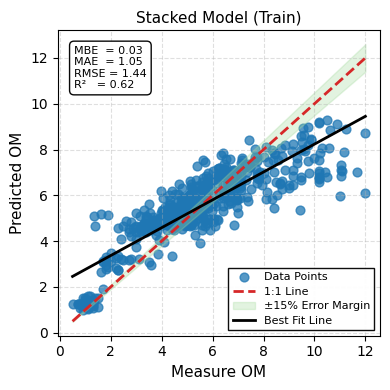

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# === Use exact precomputed average CV metrics ===
mbe_cv = 0.03
mae_cv = 1.05
rmse_cv = 1.44
r2_cv = 0.62

# === Use final stacked model to get predictions ===
y_pred_full = stack.predict(X_scaled_selected)

# === Create DataFrame for plotting ===
plot_df = pd.DataFrame({
    'Actual_OM': y,
    'Predicted_OM': y_pred_full
})

# === Regression fit for best-fit line ===
reg = LinearRegression()
reg.fit(plot_df[['Actual_OM']], plot_df['Predicted_OM'])
y_fit = reg.predict(plot_df[['Actual_OM']])
r2 = r2_score(plot_df['Predicted_OM'], y_fit)

# === Sort values for proper fill_between ===
sorted_df = plot_df.sort_values(by='Actual_OM')
x_sorted = sorted_df['Actual_OM'].values
y_sorted = sorted_df['Predicted_OM'].values
y_fit_sorted = reg.predict(x_sorted.reshape(-1, 1))

# ±15% bounds
# upper = x_sorted * 1.15
# lower = x_sorted * 0.85

# ±5% bounds
lower = x_sorted * 0.95
upper = x_sorted * 1.05
# === Plot ===
plt.figure(figsize=(4, 4), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')  # Ensure plot background is white
ax.grid(True, linestyle='--', alpha=0.4)

# Add thin black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)

# Scatter plot - brighter blue
plt.scatter(x_sorted, y_sorted, color='#1f77b4', alpha=0.75, s=40, label='Data Points')

# 1:1 line - deeper red
plt.plot([x_sorted.min(), x_sorted.max()], [x_sorted.min(), x_sorted.max()],
         color='#d62728', linestyle='--', linewidth=2, label='1:1 Line')

# ±15% Error margin - light green
plt.fill_between(x_sorted, lower, upper, color='#a1d99b', alpha=0.3, label='±15% Error Margin')

# Best-fit regression line - strong black
plt.plot(x_sorted, y_fit_sorted, color='black', linewidth=2, label='Best Fit Line')

# 📦 Metrics box
metrics_text = (
    f"MBE  = {mbe_cv:.2f}\n"
    f"MAE  = {mae_cv:.2f}\n"
    f"RMSE = {rmse_cv:.2f}\n"
    f"R²   = {r2_cv:.2f}"
)
ax.text(
    0.05, 0.95, metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor='black', facecolor='white', alpha=0.97)
)

# Labels and Title
plt.xlabel("Measure OM", fontsize=11)
plt.ylabel("Predicted OM", fontsize=11)
plt.title("Stacked Model (Train)", fontsize=11)

# 🧾 Brighter, compact legend
plt.legend(
    loc='lower right',
    fontsize=8,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor='black',
    facecolor='white',
    labelspacing=0.4
)

plt.tight_layout()
plt.show()


  0%|          | 0/535 [00:00<?, ?it/s]

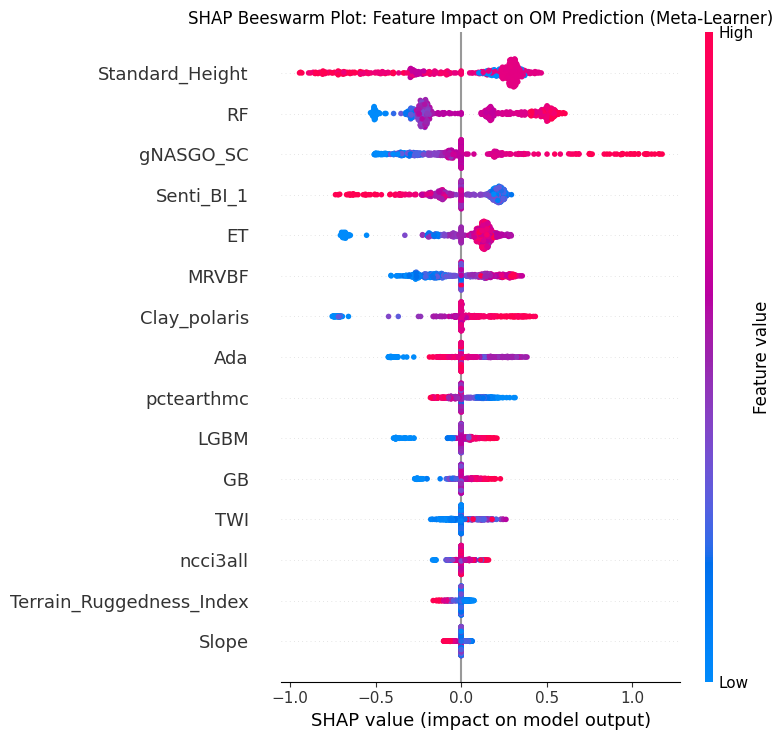

In [ ]:
import shap
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# === Load model and artifacts ===
model = joblib.load("/content/stacked_model_ensemble_noHGB_catmeta.pkl")
selected_features = joblib.load("/content/features_selected_from_ensemble.pkl")
scaler = joblib.load("/content/scaler_selected_features.pkl")

# === Load and prepare data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])
X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Prepare input for meta-learner (stacked predictions + passthrough features) ===
# The StackingRegressor with passthrough=True feeds the meta-learner
# with the predictions of the base models PLUS the original features.
# We need to replicate this input structure for SHAP.

X_selected_df = X[selected_features]
X_scaled_selected = scaler.transform(X_selected_df)

# Get predictions from the fitted base models on the training data
fitted_base_models = model.estimators_
base_model_names = [name for name, _ in model.estimators]
base_model_predictions = [bm.predict(X_scaled_selected) for bm in fitted_base_models]

# Stack base model predictions and the scaled original features
stacked_preds = np.vstack(base_model_predictions).T
meta_input = np.hstack([stacked_preds, X_scaled_selected])

# Create feature names for the meta-learner input
meta_feature_names = base_model_names + selected_features

# === SHAP Explainer on the meta-learner ===
meta_learner = model.final_estimator_

# Use a background dataset for KernelShap (required for some explainers)
# Sampling a smaller dataset makes it faster
background_data = shap.utils.sample(meta_input, 100)

explainer = shap.KernelExplainer(meta_learner.predict, background_data) # Use KernelExplainer with predict method
shap_values = explainer.shap_values(meta_input)


# === Plot SHAP summary (beeswarm) ===
# Need to wrap shap_values in a SHAP Explanation object for plotting with feature names
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=meta_input,
    feature_names=meta_feature_names
)


plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_explanation, max_display=15, show=False) # Increased max_display slightly
plt.title("SHAP Beeswarm Plot: Feature Impact on OM Prediction (Meta-Learner)")
plt.tight_layout()
plt.savefig("shap_beeswarm_meta_learner.png", dpi=300, bbox_inches='tight')
plt.show()

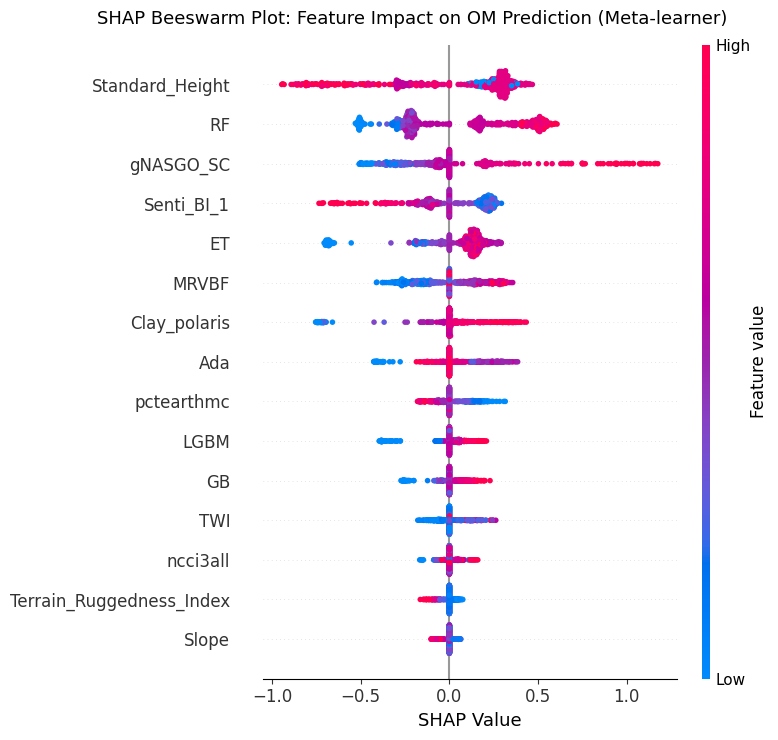

In [ ]:
plt.figure(figsize=(5, 5))
shap.plots.beeswarm(shap_explanation, max_display=19, show=False)

# Title with padding to create vertical space
plt.title("SHAP Beeswarm Plot: Feature Impact on OM Prediction (Meta-learner)",
          loc='left', x=-0.40, fontsize=13, pad=15)

plt.xlabel("SHAP Value")  # Set custom x-axis label
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("shap_beeswarm_all_features_left_aligned.png", dpi=300, bbox_inches='tight')
plt.show()


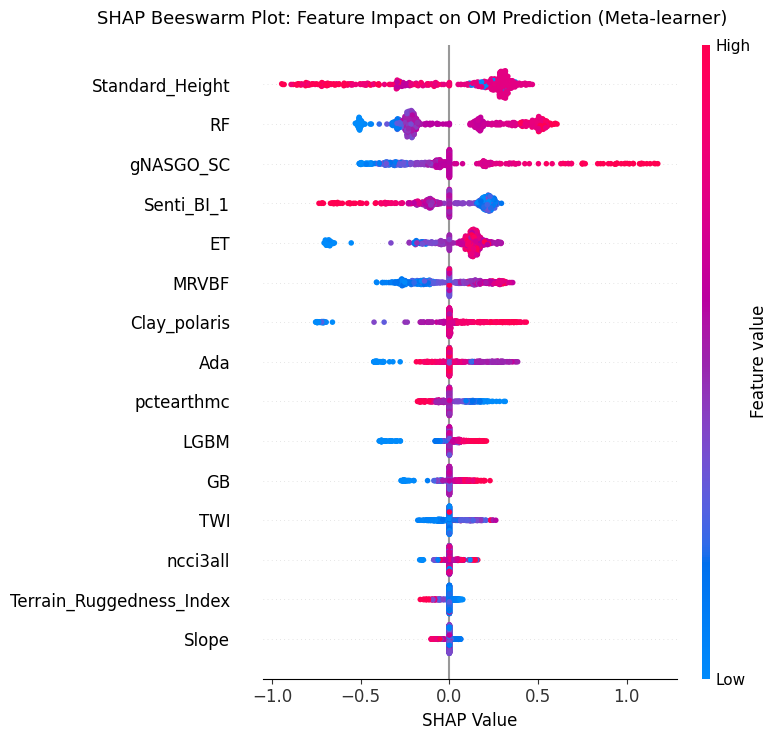

In [ ]:
plt.figure(figsize=(5, 5))
shap.plots.beeswarm(shap_explanation, max_display=19, show=False)

plt.title("SHAP Beeswarm Plot: Feature Impact on OM Prediction (Meta-learner)",
          loc='left', x=-0.40, fontsize=13, pad=15)

plt.xlabel("SHAP Value", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, color='black')  # Make y-axis labels (feature names) brighter

plt.tight_layout()
plt.savefig("shap_beeswarm_all_features_left_aligned.png", dpi=300, bbox_inches='tight')
plt.show()


stack_rpiq

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor
)
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'],
    errors='ignore'
)
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Feature Selection Using Averaged Importance ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

RF = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
Ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
GB = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
ET = ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42)
LGBM = LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)

models = [RF, Ada, GB, ET, LGBM]

importances = []
for model in models:
    model.fit(X_scaled_full, y)
    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)

avg_importance = np.mean(importances, axis=0)

importance_df = (
    pd.DataFrame({'Feature': X.columns, 'Avg_Importance': avg_importance})
    .sort_values(by='Avg_Importance', ascending=False)
)

top_k = 10
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 3: Scale Selected Features ===
scaler = StandardScaler()
X_scaled_selected = scaler.fit_transform(X_selected)

# === Step 4: Define Base and Meta Models ===
base_models = [
    ('RF', RF),
    ('Ada', Ada),
    ('GB', GB),
    ('ET', ET),
    ('LGBM', LGBM)
]

meta_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.05,
    depth=4,
    verbose=0,
    random_state=42
)

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

# === Step 5: 10-Fold Cross-Validation with RPIQ ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {
    'mbe': [], 'mae': [], 'rmse': [], 'r2': [], 'rpiq': []
}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled_selected), 1):
    X_t, X_v = X_scaled_selected[train_idx], X_scaled_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    stack.fit(X_t, y_t)
    y_pred = stack.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    # === RPIQ (validation fold) ===
    q75, q25 = np.percentile(y_v, [75, 25])
    iqr = q75 - q25
    rpiq = iqr / rmse if rmse != 0 else np.nan

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['rpiq'].append(rpiq)

    print(
        f"Fold {fold}: "
        f"MBE={mbe:.4f}, "
        f"MAE={mae:.4f}, "
        f"RMSE={rmse:.4f}, "
        f"R²={r2:.4f}, "
        f"RPIQ={rpiq:.4f}"
    )

# === Step 6: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.3f}")
print(f"MAE:  {np.mean(metrics['mae']):.3f}")
print(f"RMSE: {np.mean(metrics['rmse']):.3f}")
print(f"R²:   {np.mean(metrics['r2']):.2f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.3f}")

# === Step 7: Save Artifacts ===
joblib.dump(stack, "stacked_model_ensemble_noHGB_catmeta.pkl")
joblib.dump(scaler, "scaler_selected_features.pkl")
joblib.dump(selected_features, "features_selected_from_ensemble.pkl")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5463
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 31
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

['features_selected_from_ensemble.pkl']

Improvemeny

In [ ]:
import numpy as np
import pandas as pd
import joblib
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor,
    GradientBoostingRegressor, ExtraTreesRegressor,
    StackingRegressor
)
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

# ======================================================
# STEP 1: Load & clean data
# ======================================================
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df["OM"] <= 12].dropna(subset=["OM"])

X = df.drop(
    columns=[
        "OM", "SAMPLEDATE", "lati", "Relative_Elev",
        "long", "Planet_BI_1", "SAND_Polaris", "Lamda_Polaris"
    ],
    errors="ignore"
)
y = df["OM"]

X = X.dropna()
y = y.loc[X.index]

# ======================================================
# STEP 2: Feature selection (average importance)
# ======================================================
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

RF = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
Ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
GB = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
ET = ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42)
LGBM = LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)

models = [RF, Ada, GB, ET, LGBM]

importances = []
for m in models:
    m.fit(X_scaled_full, y)
    importances.append(m.feature_importances_)

avg_importance = np.mean(importances, axis=0)

importance_df = (
    pd.DataFrame({"Feature": X.columns, "Importance": avg_importance})
    .sort_values(by="Importance", ascending=False)
)

top_k = 10
selected_features = importance_df["Feature"].iloc[:top_k].tolist()
X_selected = X[selected_features]

# ======================================================
# STEP 3: Define stacking model
# ======================================================
base_models = [
    ("RF", RF),
    ("Ada", Ada),
    ("GB", GB),
    ("ET", ET),
    ("LGBM", LGBM),
]

meta_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.05,
    depth=4,
    verbose=0,
    random_state=42
)

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

# ======================================================
# STEP 4: 10-Fold CV (CORRECT – scaler inside fold)
# ======================================================
kf = KFold(n_splits=10, shuffle=True, random_state=42)

metrics = {"mae": [], "rmse": [], "r2": [], "rpiq": []}
y_all_true, y_all_pred = [], []

print("\n📊 Per-fold metrics:")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected), 1):

    X_train, X_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # 🔑 scale inside fold (THIS FIXES THE ISSUE)
    scaler_fold = StandardScaler()
    X_train_s = scaler_fold.fit_transform(X_train)
    X_val_s = scaler_fold.transform(X_val)

    stack.fit(X_train_s, y_train)
    y_pred = stack.predict(X_val_s)

    y_all_true.extend(y_val.values)
    y_all_pred.extend(y_pred)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    q75, q25 = np.percentile(y_val, [75, 25])
    rpiq = (q75 - q25) / rmse

    metrics["mae"].append(mae)
    metrics["rmse"].append(rmse)
    metrics["r2"].append(r2)
    metrics["rpiq"].append(rpiq)

    print(
        f"Fold {fold}: RMSE={rmse:.3f}, R²={r2:.3f}, RPIQ={rpiq:.3f}"
    )

# ======================================================
# STEP 5: Average metrics
# ======================================================
print("\n📌 Average 10-fold metrics:")
print(f"MAE:  {np.mean(metrics['mae']):.3f}")
print(f"RMSE: {np.mean(metrics['rmse']):.3f}")
print(f"R²:   {np.mean(metrics['r2']):.3f}")
print(f"RPIQ: {np.mean(metrics['rpiq']):.3f}")

# ======================================================
# STEP 6: Train FINAL model on full data (correct)
# ======================================================
final_scaler = StandardScaler()
X_final_scaled = final_scaler.fit_transform(X_selected)

stack.fit(X_final_scaled, y)

# ======================================================
# STEP 7: Save artifacts
# ======================================================
joblib.dump(stack, "stacked_model_ensemble_noHGB_catmeta.pkl")
joblib.dump(final_scaler, "scaler_selected_features.pkl")
joblib.dump(selected_features, "features_selected_from_ensemble.pkl")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5105
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 29
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

['features_selected_from_ensemble.pkl']

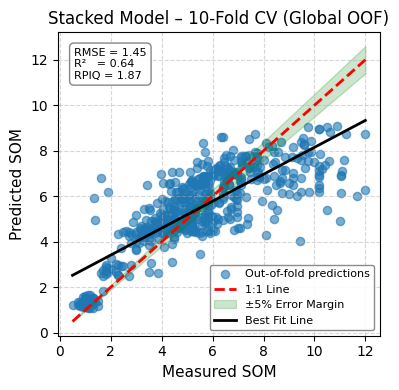

In [ ]:
from sklearn.linear_model import LinearRegression

# Convert to numpy arrays
y_all_true = np.array(y_all_true)
y_all_pred = np.array(y_all_pred)

# Sort for smooth plotting
sort_idx = np.argsort(y_all_true)
x_sorted = y_all_true[sort_idx]
y_sorted = y_all_pred[sort_idx]

# Best-fit line
reg = LinearRegression().fit(x_sorted.reshape(-1, 1), y_sorted)
y_fit = reg.predict(x_sorted.reshape(-1, 1))

# ±5% error band
lower = x_sorted * 0.95
upper = x_sorted * 1.05

# Global CV metrics
rmse_cv = np.sqrt(mean_squared_error(y_all_true, y_all_pred))
r2_cv = r2_score(y_all_true, y_all_pred)

q75, q25 = np.percentile(y_all_true, [75, 25])
rpiq_cv = (q75 - q25) / rmse_cv

# ======================================================
# Plot
# ======================================================
plt.figure(figsize=(4, 4))
ax = plt.gca()
ax.grid(True, linestyle="--", alpha=0.5)

# Border styling
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)

# Scatter points (WHAT THE MODEL DID)
plt.scatter(
    x_sorted,
    y_sorted,
    color="#1f77b4",
    alpha=0.6,
    s=35,
    label="Out-of-fold predictions"
)

# 1:1 reference line (perfect prediction)
plt.plot(
    [x_sorted.min(), x_sorted.max()],
    [x_sorted.min(), x_sorted.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="1:1 Line"
)

# ±5% error band
plt.fill_between(
    x_sorted,
    lower,
    upper,
    color="green",
    alpha=0.2,
    label="±5% Error Margin"
)

# Best-fit regression line
plt.plot(
    x_sorted,
    y_fit,
    color="black",
    linewidth=2,
    label="Best Fit Line"
)

# Metrics box (only key metrics)
metrics_text = (
    f"RMSE = {rmse_cv:.2f}\n"
    f"R²   = {r2_cv:.2f}\n"
    f"RPIQ = {rpiq_cv:.2f}"
)
ax.text(
    0.05, 0.95,
    metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

# Labels and title
plt.xlabel("Measured SOM", fontsize=11)
plt.ylabel("Predicted SOM", fontsize=11)
plt.title("Stacked Model – 10-Fold CV (Global OOF)")
, fontsize=10)

# Legend
plt.legend(
    loc="lower right",
    fontsize=8,
    frameon=True,
    framealpha=0.9,
    edgecolor="gray"
)

plt.tight_layout()
plt.show()


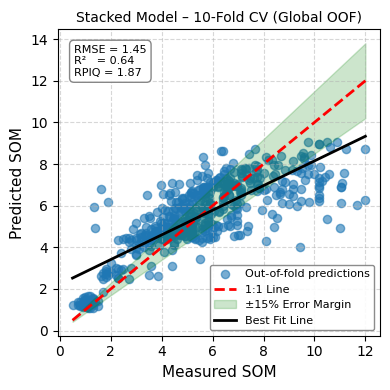

In [ ]:
from sklearn.linear_model import LinearRegression

# Convert to numpy arrays
y_all_true = np.array(y_all_true)
y_all_pred = np.array(y_all_pred)

# Sort for smooth plotting
sort_idx = np.argsort(y_all_true)
x_sorted = y_all_true[sort_idx]
y_sorted = y_all_pred[sort_idx]

# Best-fit line
reg = LinearRegression().fit(x_sorted.reshape(-1, 1), y_sorted)
y_fit = reg.predict(x_sorted.reshape(-1, 1))

# ±15% error band
lower = x_sorted * 0.85
upper = x_sorted * 1.15

# Global OOF metrics
rmse_cv = np.sqrt(mean_squared_error(y_all_true, y_all_pred))
r2_cv = r2_score(y_all_true, y_all_pred)

q75, q25 = np.percentile(y_all_true, [75, 25])
rpiq_cv = (q75 - q25) / rmse_cv

# ======================================================
# Plot
# ======================================================
plt.figure(figsize=(4, 4))
ax = plt.gca()
ax.grid(True, linestyle="--", alpha=0.5)

# Border styling
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)

# Scatter points
plt.scatter(
    x_sorted,
    y_sorted,
    color="#1f77b4",
    alpha=0.6,
    s=35,
    label="Out-of-fold predictions"
)

# 1:1 line
plt.plot(
    [x_sorted.min(), x_sorted.max()],
    [x_sorted.min(), x_sorted.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="1:1 Line"
)

# ±15% error band
plt.fill_between(
    x_sorted,
    lower,
    upper,
    color="green",
    alpha=0.2,
    label="±15% Error Margin"
)

# Best-fit line
plt.plot(
    x_sorted,
    y_fit,
    color="black",
    linewidth=2,
    label="Best Fit Line"
)

# Metrics box
metrics_text = (
    f"RMSE = {rmse_cv:.2f}\n"
    f"R²   = {r2_cv:.2f}\n"
    f"RPIQ = {rpiq_cv:.2f}"
)
ax.text(
    0.05, 0.95,
    metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

# Labels & title
plt.xlabel("Measured SOM", fontsize=11)
plt.ylabel("Predicted SOM", fontsize=11)
plt.title("Stacked Model – 10-Fold CV (Global OOF)", fontsize=10)

# Legend
plt.legend(
    loc="lower right",
    fontsize=8,
    frameon=True,
    framealpha=0.9,
    edgecolor="gray"
)

plt.tight_layout()
plt.show()


TEST


📊 Test Set Metrics (Stacked Model):
RMSE: 0.979
R²:   0.577
RPIQ: 2.274
MAE:  0.694
MBE:  0.066


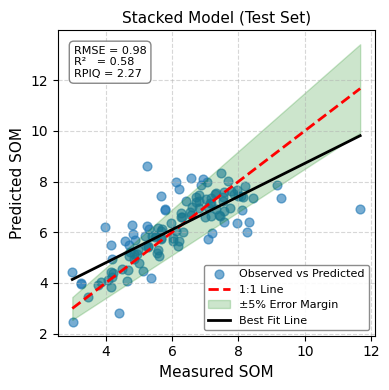

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# ======================================================
# STEP 1: Load test data
# ======================================================
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=["OM"])

# ======================================================
# STEP 2: Load model artifacts
# ======================================================
model = joblib.load("/content/stacked_model_ensemble_noHGB_catmeta.pkl")
scaler = joblib.load("/content/scaler_selected_features.pkl")
selected_features = joblib.load("/content/features_selected_from_ensemble.pkl")

# ======================================================
# STEP 3: Prepare test features
# ======================================================
X_test_raw = df_test.drop(
    columns=["OM", "SAMPLEDATE", "lati", "Relative_Elev", "long", "Planet_BI_1"],
    errors="ignore"
)
y_test = df_test["OM"]

# Add missing features
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# ======================================================
# STEP 4: Scale and predict
# ======================================================
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# ======================================================
# STEP 5: Metrics (numeric + distribution-based)
# ======================================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

# RPIQ calculation
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse

print("\n📊 Test Set Metrics (Stacked Model):")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")
print(f"RPIQ: {rpiq:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"MBE:  {mbe:.3f}")

# ======================================================
# STEP 6: Actual vs Predicted Plot (±5% band)
# ======================================================
x_sorted = np.array(y_test)
y_sorted = np.array(y_pred)
sort_idx = np.argsort(x_sorted)
x_sorted = x_sorted[sort_idx]
y_sorted = y_sorted[sort_idx]

# Best-fit line
reg = LinearRegression().fit(x_sorted.reshape(-1, 1), y_sorted)
y_fit_sorted = reg.predict(x_sorted.reshape(-1, 1))

# ±5% bounds
#lower = x_sorted * 0.95
#upper = x_sorted * 1.05
# ±15% error band
lower = x_sorted * 0.85
upper = x_sorted * 1.15

# ======================================================
# Plot
# ======================================================
plt.figure(figsize=(4, 4))
ax = plt.gca()
ax.grid(True, linestyle="--", alpha=0.5)

# Border styling
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)

# Scatter
plt.scatter(
    x_sorted, y_sorted,
    color="#1f77b4", alpha=0.6, s=40,
    label="Observed vs Predicted"
)

# 1:1 line
plt.plot(
    [x_sorted.min(), x_sorted.max()],
    [x_sorted.min(), x_sorted.max()],
    color="red", linestyle="--", linewidth=2,
    label="1:1 Line"
)

# ±5% error band
plt.fill_between(
    x_sorted, lower, upper,
    color="green", alpha=0.2,
    label="±5% Error Margin"
)

# Best-fit line
plt.plot(
    x_sorted, y_fit_sorted,
    color="black", linewidth=2,
    label="Best Fit Line"
)

# Metrics box (ONLY RMSE, R², RPIQ)
metrics_text = (
    f"RMSE = {rmse:.2f}\n"
    f"R²   = {r2:.2f}\n"
    f"RPIQ = {rpiq:.2f}"
)
ax.text(
    0.05, 0.95, metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        edgecolor="gray",
        facecolor="white",
        alpha=0.95
    )
)

# Labels & title
plt.xlabel("Measured SOM", fontsize=11)
plt.ylabel("Predicted SOM", fontsize=11)
plt.title("Stacked Model (Test Set)", fontsize=11)

# Legend
plt.legend(
    loc="lower right",
    fontsize=8,
    frameon=True,
    framealpha=0.9,
    edgecolor="gray"
)

plt.tight_layout()
plt.show()

# ======================================================
# STEP 7: Save predictions
# ======================================================
df_test["Predicted_OM"] = y_pred
df_test[["OM", "Predicted_OM"]].to_csv(
    "stacked_model_test_predictions.csv",
    index=False
)



📊 Test Set Metrics (Stacked Model):
MAE:  0.715
RMSE: 0.994
R²:   0.56
MBE:  -0.019
RPIQ: 2.238


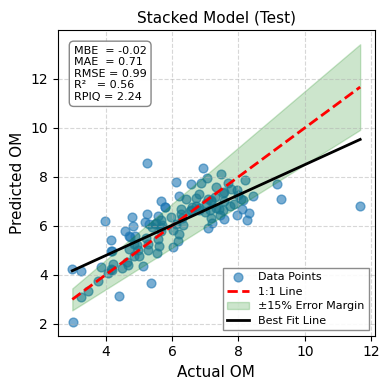

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("/content/stacked_model_ensemble_noHGB_catmeta.pkl")
scaler = joblib.load("/content/scaler_selected_features.pkl")
selected_features = joblib.load("/content/features_selected_from_ensemble.pkl")

# === Step 3: Prepare test features ===
X_test_raw = df_test.drop(
    columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'SAND_Polaris', 'Lamda_Polaris'],
    errors='ignore'
)
y_test = df_test['OM']

# Add missing features (if any)
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features].fillna(0)

# === Step 4: Scale and Predict ===
X_test_scaled = scaler.transform(X_test_final)
y_pred = model.predict(X_test_scaled)

# === Step 5: Compute Metrics ===
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

# === RPIQ calculation (TEST SET) ===
q75, q25 = np.percentile(y_test, [75, 25])
iqr = q75 - q25
rpiq = iqr / rmse if rmse != 0 else np.nan

print("\n📊 Test Set Metrics (Stacked Model):")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.2f}")
print(f"MBE:  {mbe:.3f}")
print(f"RPIQ: {rpiq:.3f}")

# === Step 6: Enhanced Plot: Actual vs Predicted ===
# Sort values for smooth plotting
x_sorted = np.array(y_test)
y_sorted = np.array(y_pred)
sort_idx = np.argsort(x_sorted)
x_sorted = x_sorted[sort_idx]
y_sorted = y_sorted[sort_idx]

# Best-fit line
reg = LinearRegression().fit(x_sorted.reshape(-1, 1), y_sorted)
y_fit_sorted = reg.predict(x_sorted.reshape(-1, 1))

# ±15% bounds
lower = x_sorted * 0.85
upper = x_sorted * 1.15

# === Plot ===
plt.figure(figsize=(4, 4))
ax = plt.gca()
ax.grid(True, linestyle='--', alpha=0.5)

# Border styling
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)

# Scatter
plt.scatter(x_sorted, y_sorted, color='#1f77b4', alpha=0.6, s=40, label='Data Points')

# 1:1 Line
plt.plot(
    [x_sorted.min(), x_sorted.max()],
    [x_sorted.min(), x_sorted.max()],
    color='red', linestyle='--', linewidth=2, label='1:1 Line'
)

# ±15% Error Band
plt.fill_between(x_sorted, lower, upper, color='green', alpha=0.2, label='±15% Error Margin')

# Best-Fit Line
plt.plot(x_sorted, y_fit_sorted, color='black', linewidth=2, label='Best Fit Line')

# Metrics Box (WITH RPIQ)
metrics_text = (
    f"MBE  = {mbe:.2f}\n"
    f"MAE  = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"R²   = {r2:.2f}\n"
    f"RPIQ = {rpiq:.2f}"
)
ax.text(
    0.05, 0.95, metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor='gray', facecolor='white', alpha=0.95)
)

# Labels and Title
plt.xlabel("Actual OM", fontsize=11)
plt.ylabel("Predicted OM", fontsize=11)
plt.title("Stacked Model (Test)", fontsize=11)

# Legend
plt.legend(
    loc='lower right',
    fontsize=8,
    frameon=True,
    fancybox=False,
    framealpha=0.9,
    edgecolor='gray',
    labelspacing=0.4
)

plt.tight_layout()
plt.show()

# === Step 7: Save Predictions ===
df_test['Predicted_OM'] = y_pred
df_test[['OM', 'Predicted_OM']].to_csv(
    "stacked_model_test_predictions.csv",
    index=False
)


Feature?Importance

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5463
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 31
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

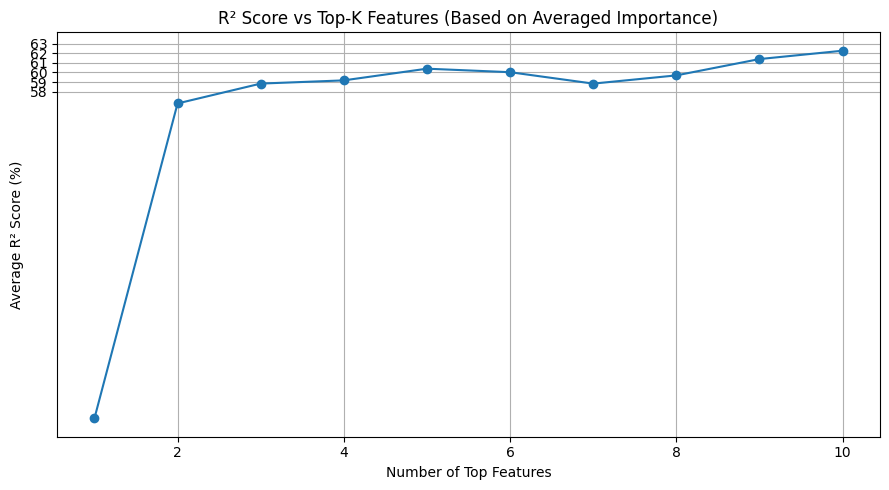

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor
)
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

# === Load and clean data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])
X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Get average feature importance ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# Base models (excluding KNN for importance)
models = [
    RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42),
    XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42),
    LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    BayesianRidge()
]

importances = []
for model in models:
    model.fit(X_scaled_full, y)
    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        coef = np.abs(model.coef_)
        coef /= np.sum(coef)
        importances.append(coef)

avg_importance = np.mean(importances, axis=0)

# === Rank features ===
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': avg_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# === Evaluate R² for top 1 to N features ===
max_k = 10  # Top 1 to 20 features
results = []

for k in range(1, max_k + 1):
    selected_features = importance_df['Feature'].iloc[:k].tolist()
    X_selected = X[selected_features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)

    # Define full model
    base_models = [
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)),
        ('ada', AdaBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42)),
        ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)),
        ('et', ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42)),
        ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)),
        ('knn', KNeighborsRegressor(n_neighbors=5)),
        ('bayridge', BayesianRidge())
    ]

    meta_model = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=4, verbose=0, random_state=42)

    stack = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        passthrough=True,
        n_jobs=-1
    )

    # 10-fold CV
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    r2_folds = []

    for train_idx, val_idx in kf.split(X_scaled):
        X_t, X_v = X_scaled[train_idx], X_scaled[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

        stack.fit(X_t, y_t)
        y_pred = stack.predict(X_v)
        r2_folds.append(r2_score(y_v, y_pred))

    avg_r2 = np.mean(r2_folds)
    results.append(avg_r2 * 100)  # Convert to percentage (e.g., 0.60 -> 60.0)
    print(f"Top {k} Features -> R²: {avg_r2:.4f}")

# === Plot R² vs Top K Features ===
plt.figure(figsize=(9, 5))
plt.plot(range(1, max_k + 1), results, marker='o', linestyle='-')
plt.title("R² Score vs Top-K Features (Based on Averaged Importance)")
plt.xlabel("Number of Top Features")
plt.ylabel("Average R² Score (%)")
plt.yticks(np.arange(58, 64, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


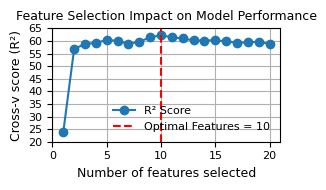

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Actual R² results (as percentages)
results = [
    23.80, 56.76, 58.84, 59.17, 60.40,
    60.03, 58.83, 59.70, 61.40, 62.28,
    61.41, 61.01, 60.19, 60.13, 60.33,
    59.78, 59.30, 59.38, 59.76, 58.68
]

feature_counts = list(range(1, len(results) + 1))
optimal_idx = int(np.argmax(results))
optimal_k = feature_counts[optimal_idx]
optimal_r2 = results[optimal_idx]

# Plot
plt.figure(figsize=(3, 2))
plt.plot(feature_counts, results, marker='o', linestyle='-', label='R² Score')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal Features = {optimal_k}')

plt.title("Feature Selection Impact on Model Performance", fontsize=9)
plt.xlabel("Number of features selected", fontsize=9)
plt.ylabel("Cross-v score (R²)", fontsize=9)
plt.xticks([0, 5, 10, 15, 20], fontsize=8)
plt.yticks(np.arange(20, 70, 5), fontsize=8)
plt.grid(True)

# Smaller, cleaner legend
plt.legend(fontsize=8, loc='lower right', frameon=False)

plt.tight_layout()
plt.show()


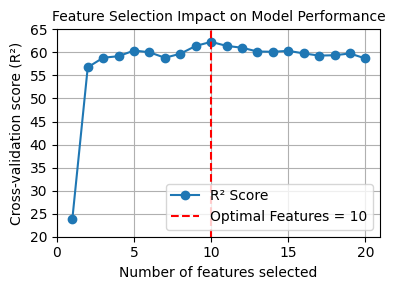

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Actual R² results you shared (as percentages)
results = [
    23.80, 56.76, 58.84, 59.17, 60.40,
    60.03, 58.83, 59.70, 61.40, 62.28,
    61.41, 61.01, 60.19, 60.13, 60.33,
    59.78, 59.30, 59.38, 59.76, 58.68
]

# Number of features
feature_counts = list(range(1, len(results) + 1))

# Find optimal number of features
optimal_idx = int(np.argmax(results))
optimal_k = feature_counts[optimal_idx]
optimal_r2 = results[optimal_idx]

# Plot
plt.figure(figsize=(4, 3))
plt.plot(feature_counts, results, marker='o', linestyle='-', label='R² Score')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal Features = {optimal_k}')
plt.title("Feature Selection Impact on Model Performance", fontsize=10)
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (R²)")
plt.xticks([0, 5, 10, 15, 20])
plt.yticks(np.arange(20, 70, 5))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1710
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 10
[LightGBM] [Info] Start training from score 5.434579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

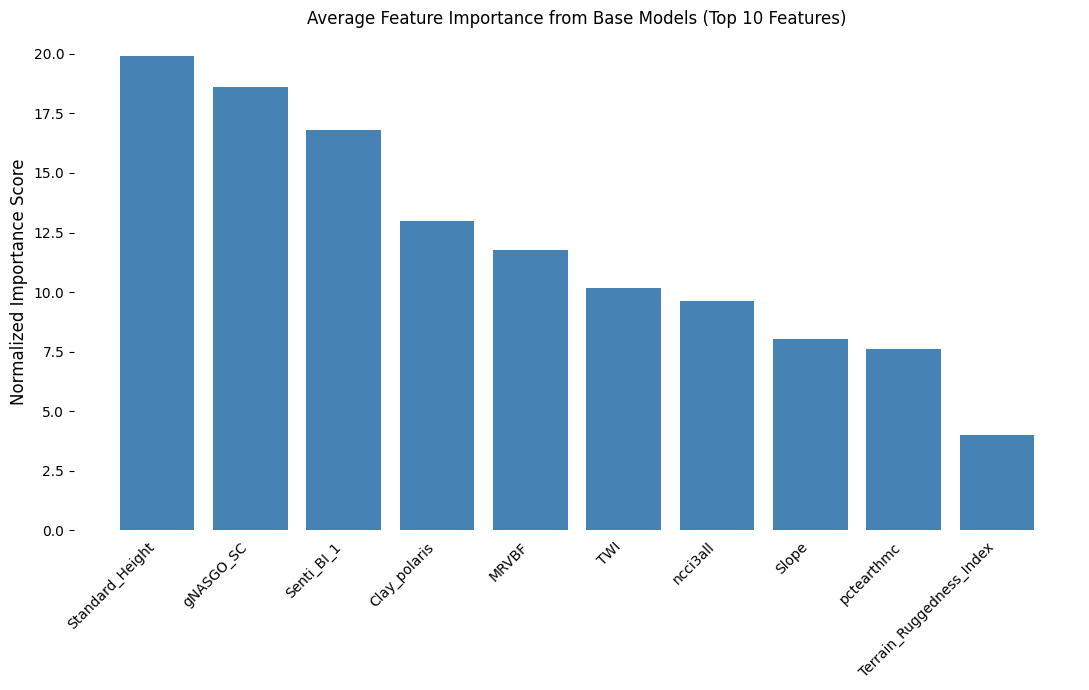

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Use top 10 selected features (already done)
X_top10 = X[selected_features]
scaler_top10 = StandardScaler()
X_top10_scaled = scaler_top10.fit_transform(X_top10)

# Step 2: Reuse already-defined base models
base_models_dict = {
    'rf': rf,
    'ada': ada,
    'gbr': gbr,
    'et': et,
    'xgb': xgb,
    'lgbm': lgbm,
    'bayridge': bayridge,
    # 'knn' excluded since no importances
}

importances = []

# Step 3: Fit each base model on top 10 features and collect importances
for name, model in base_models_dict.items():
    model.fit(X_top10_scaled, y)

    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        coef = np.abs(model.coef_)
        coef /= np.sum(coef)  # Normalize coefficients
        importances.append(coef)

# Step 4: Average importance across models
avg_importance_top10 = np.mean(importances, axis=0)

# Step 5: Create DataFrame
importance_df_avg = pd.DataFrame({
    'Feature': selected_features,
    'Avg_Importance': avg_importance_top10
}).sort_values(by='Avg_Importance', ascending=False)

# Step 6: Plot
plt.figure(figsize=(11, 7))
plt.bar(importance_df_avg['Feature'], importance_df_avg['Avg_Importance'], color='steelblue')

plt.title("Average Feature Importance from Base Models (Top 10 Features)", fontsize=12)
plt.ylabel("Normalized Importance Score", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', right=False)

# Remove frame
plt.grid(False)
plt.gca().set_facecolor('white')
for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


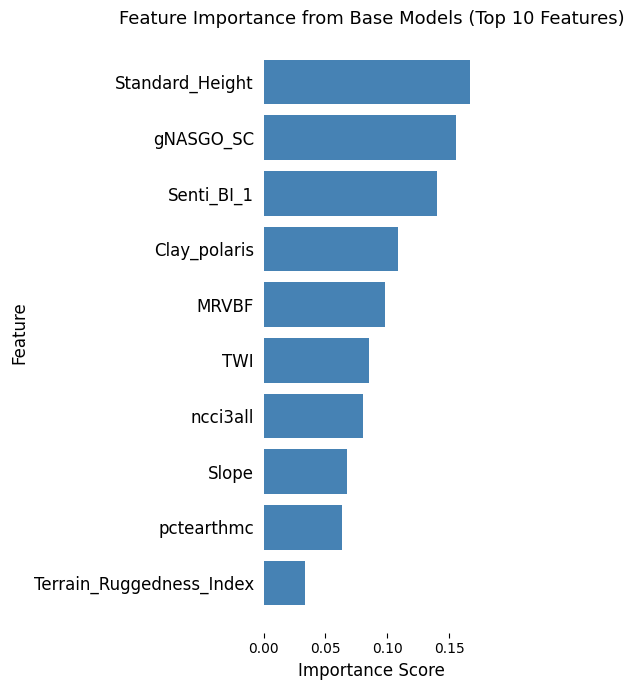

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Replace long feature name
importance_df_avg['Feature'] = importance_df_avg['Feature'].replace({
    'Terrain Ruggedness Index': 'T. Ruggedness Index'
})

# Normalize
importance_df_avg['Normalized_Importance'] = importance_df_avg['Avg_Importance'] / importance_df_avg['Avg_Importance'].sum()

# Plot
plt.figure(figsize=(5, 7))
plt.barh(importance_df_avg['Feature'], importance_df_avg['Normalized_Importance'], color='steelblue')

plt.title("Feature Importance from Base Models (Top 10 Features)", fontsize=13)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12, labelpad=4)
plt.xticks(fontsize=10)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()

# Format x-axis ticks to show 2 decimal places
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Style
plt.tick_params(axis='x', which='both', top=False)
plt.tick_params(axis='y', which='both', left=False)
plt.grid(False)
plt.gca().set_facecolor('white')

for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()



📊 Per Fold Metrics:
Fold 1: MBE=-0.2243, MAE=1.2330, RMSE=1.6647, R²=0.5899
Fold 2: MBE=-0.2815, MAE=1.6607, RMSE=2.1806, R²=0.0894
Fold 3: MBE=0.5226, MAE=0.9616, RMSE=1.2264, R²=0.5648
Fold 4: MBE=0.0079, MAE=1.7217, RMSE=2.2738, R²=-0.0357
Fold 5: MBE=-0.3309, MAE=1.4788, RMSE=1.9295, R²=0.4189
Fold 6: MBE=0.1998, MAE=1.4374, RMSE=1.9174, R²=0.2740
Fold 7: MBE=-0.4562, MAE=1.1972, RMSE=1.6625, R²=0.4096
Fold 8: MBE=-0.1718, MAE=1.4950, RMSE=2.0344, R²=0.3341
Fold 9: MBE=-0.1082, MAE=1.3746, RMSE=1.8292, R²=0.3894
Fold 10: MBE=0.1222, MAE=1.4281, RMSE=1.9267, R²=0.4776

📌 Average 10-Fold Metrics:
MBE:  -0.0720
MAE:  1.3988
RMSE: 1.8645
R²:   0.3512


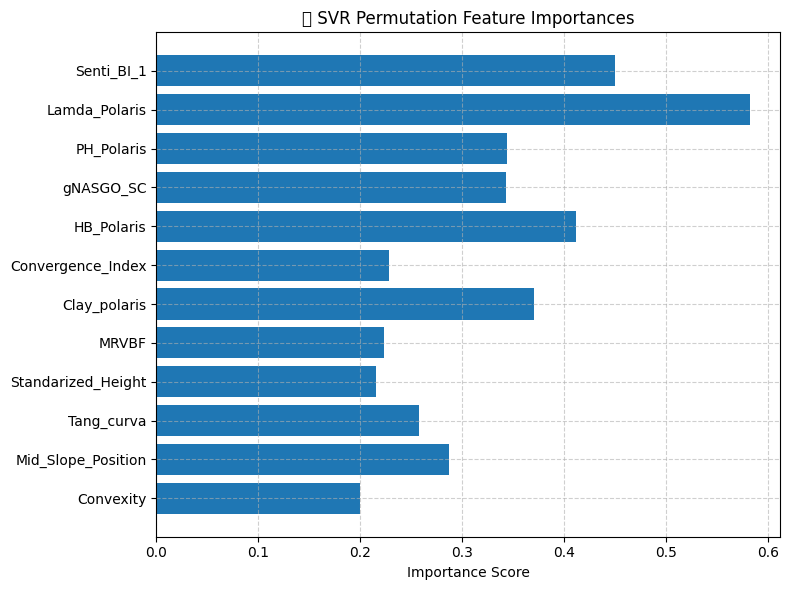

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati','Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance using base SVR ===
svr_base = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_base.fit(X_scaled, y)
perm_importance = permutation_importance(svr_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Final Scaling of Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Initialize Final SVR Model ===
best_svr = SVR(kernel='rbf', C=100, epsilon=0.1)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_svr.fit(X_t, y_t)
    y_pred = best_svr.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_svr, "best_svr_model.pkl")
joblib.dump(scaler, "scaler_svr.pkl")
joblib.dump(selected_features, "selected_features_svr.pkl")

# === Step 9: Plot Feature Importance (via Permutation) ===
svr_final_importance = permutation_importance(best_svr, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42)
final_importances = svr_final_importance.importances_mean

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_importances)
plt.title("📌 SVR Permutation Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


hyper_SVM

Fitting 3 folds for each of 162 candidates, totalling 486 fits

✅ Best Hyperparameters:
{'C': 10, 'degree': 3, 'epsilon': 1, 'gamma': 'auto', 'kernel': 'poly'}

📊 Per Fold Metrics:
Fold 1: MBE=-0.2391, MAE=1.2647, RMSE=1.7472, R²=0.5482
Fold 2: MBE=-0.2054, MAE=1.2627, RMSE=1.6819, R²=0.4583
Fold 3: MBE=0.4140, MAE=0.9930, RMSE=1.1642, R²=0.6078
Fold 4: MBE=-0.0941, MAE=1.2522, RMSE=1.7169, R²=0.4095
Fold 5: MBE=-0.3054, MAE=1.3592, RMSE=1.7793, R²=0.5059
Fold 6: MBE=0.4092, MAE=1.0981, RMSE=1.4740, R²=0.5710
Fold 7: MBE=-0.0713, MAE=1.2574, RMSE=1.5694, R²=0.4739
Fold 8: MBE=-0.1215, MAE=1.1641, RMSE=1.6166, R²=0.5795
Fold 9: MBE=-0.1470, MAE=1.0156, RMSE=1.4957, R²=0.5918
Fold 10: MBE=-0.2416, MAE=1.3087, RMSE=1.8680, R²=0.5090

📌 Average 10-Fold Metrics:
MBE:  -0.0602
MAE:  1.1976
RMSE: 1.6113
R²:   0.5255


/tmp/ipython-input-749298611.py:102: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


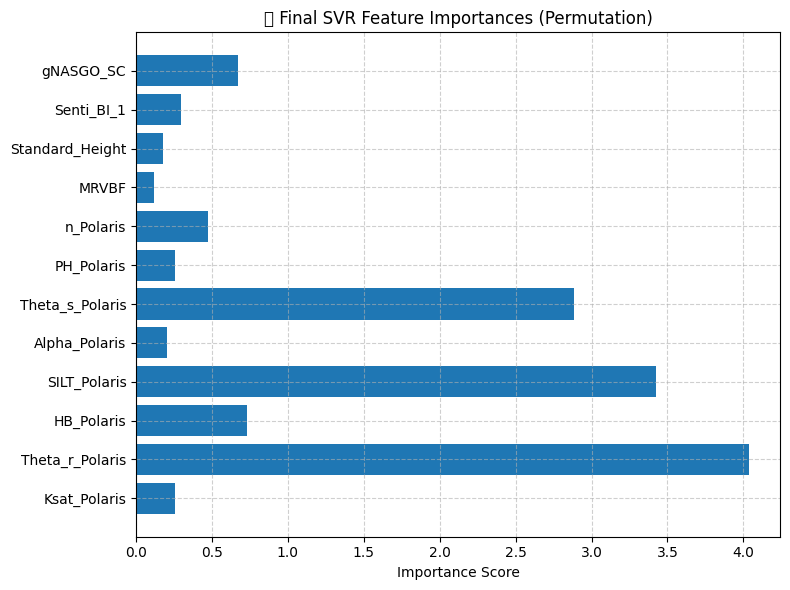

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean data ===
df = pd.read_csv("/content/cleaned_file_removing_11,21field.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1', 'Lamda_Polaris', 'SAND_Polaris', 'BD_Polaris'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with base SVR ===
svr_base = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_base.fit(X_scaled, y)
perm_importance = permutation_importance(svr_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
top_k = int(0.45 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Final Scaling on selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning with GridSearchCV ===
param_grid = {
    'kernel': ['rbf', 'poly', 'linear'],
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # only used for 'poly' kernel
}

grid_search = GridSearchCV(SVR(), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_selected_scaled, y)
best_svr = grid_search.best_estimator_

print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_svr.fit(X_t, y_t)
    y_pred = best_svr.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Model Artifacts ===
joblib.dump(best_svr, "best_svr_model.pkl")
joblib.dump(scaler, "scaler_svr.pkl")
joblib.dump(selected_features, "selected_features_svr.pkl")

# === Step 9: Final Permutation Importance Plot ===
final_importance = permutation_importance(best_svr, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42)
final_scores = final_importance.importances_mean

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_scores)
plt.title("📌 Final SVR Feature Importances (Permutation)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


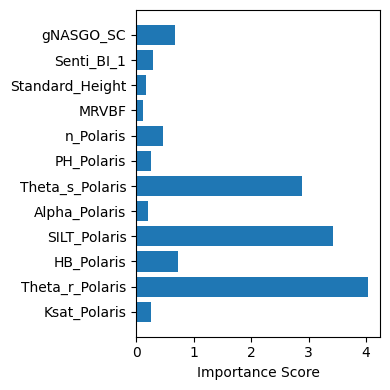

In [2]:
plt.figure(figsize=(4, 4))
plt.barh(selected_features, final_scores)

plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
# plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

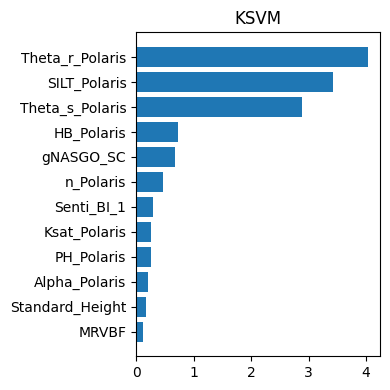

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays
features = np.array(selected_features)
scores = np.array(final_scores)

# Sort from highest → lowest
sorted_idx = np.argsort(scores)[::-1]
features_sorted = features[sorted_idx]
scores_sorted = scores[sorted_idx]

# Plot
plt.figure(figsize=(4, 4))
plt.barh(features_sorted, scores_sorted)


plt.title("KSVM")   # 👈 title added
plt.gca().invert_yaxis()   # highest on top
plt.tight_layout()
plt.show()


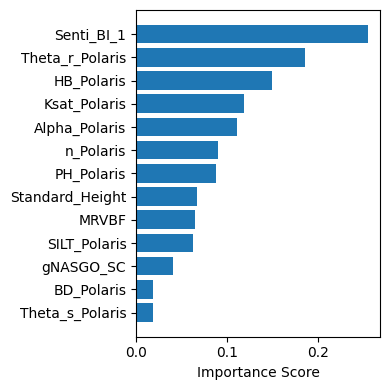

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays
features = np.array(selected_features)
scores = np.array(final_scores)

# Sort from highest → lowest
sorted_idx = np.argsort(scores)[::-1]
features_sorted = features[sorted_idx]
scores_sorted = scores[sorted_idx]

# Plot
plt.figure(figsize=(4, 4))
plt.barh(features_sorted, scores_sorted)

plt.xlabel("Importance Score")
plt.gca().invert_yaxis()   # highest on top
plt.tight_layout()
plt.show()


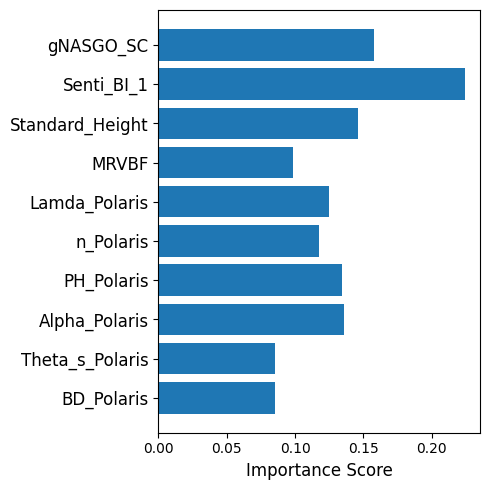

In [ ]:
plt.figure(figsize=(5, 5))
plt.barh(selected_features, final_scores)

plt.xlabel("Importance Score",fontsize=12),
plt.yticks(fontsize=12)  # Set y-axis label font size
plt.gca().invert_yaxis()
# plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


TEST

🔍 Features used for prediction:
 - gNASGO_SC
 - Senti_BI_1
 - Standard_Height
 - MRVBF
 - n_Polaris
 - PH_Polaris
 - Alpha_Polaris
 - Theta_s_Polaris
 - BD_Polaris
 - HB_Polaris
 - SILT_Polaris
 - Theta_r_Polaris
 - Ksat_Polaris

📊 Test Set Metrics (Stacked Model):
MAE:  1.1990
RMSE: 1.6378
R²:   -0.1851
MBE:  -0.7665


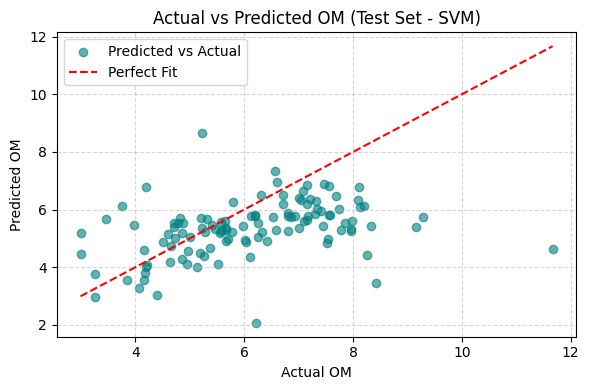

In [17]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("/content/Antho_Test_,11,21_field.csv")  # 📝 update path if needed
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("/content/best_svr_model.pkl")  # 🧠 Stacked model
scaler = joblib.load("/content/scaler_svr.pkl")       # 📏 Scaler for selected features
selected_features = joblib.load("/content/selected_features_svr.pkl")  # ✅ Selected features

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'Relative_Elev', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

print("\n📊 Test Set Metrics (Stacked Model):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit")
plt.title("Actual vs Predicted OM (Test Set - SVM)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Step 8 (Optional): Save Predictions to CSV ===
df_test['Predicted_OM'] = y_pred
df_test[['OM', 'Predicted_OM']].to_csv("stacked_model_test_predictions.csv", index=False)
